## portion 1

In [1]:
!pip install -q datasets transformers accelerate sentencepiece sacremoses ftfy regex scikit-learn tqdm pillow matplotlib pandas pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import math
import hashlib
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image as PILImage

import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Image as HFImage
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")


class CFG:
    # -------------------------
    # Reproducibility
    # -------------------------
    seed = 42

    # -------------------------
    # Dataset
    # -------------------------
    dataset_id = "SyedNazmusSakib/PlantVillageVQA"

    # If debugging, set to small number, e.g. 5000.
    # For full research run, keep None.
    max_rows_debug = None

    # -------------------------
    # Output root
    # -------------------------
    if Path("/kaggle/working").exists():
        root = Path("/kaggle/working/tinyagrivqa_bn")
    else:
        root = Path("./tinyagrivqa_bn")

    data_dir = root / "data_bn"
    report_dir = root / "reports"
    image_export_dir = root / "exported_images"
    plot_dir = root / "plots"
    cache_dir = root / "cache"

    # -------------------------
    # Translation
    # -------------------------
    use_translation = True

    # Recommended: NLLB English -> Bengali.
    # This is large but suitable on GPU.
    translation_model_name = "facebook/nllb-200-distilled-600M"
    source_lang = "eng_Latn"
    target_lang = "ben_Beng"

    translation_batch_size = 16
    translation_max_input_length = 128
    translation_max_new_tokens = 96
    translation_num_beams = 4

    # For quick pipeline test, set small number, e.g. 1000.
    # For full dataset, keep None.
    max_unique_texts_to_translate = None

    translation_cache_path = cache_dir / "translation_cache_en_to_bn.json"

    # -------------------------
    # Split
    # -------------------------
    train_ratio = 0.80
    val_ratio = 0.10
    test_ratio = 0.10

    # -------------------------
    # Audit
    # -------------------------
    audit_sample_size = 1500

    # -------------------------
    # Cleaning
    # -------------------------
    min_question_chars = 2
    min_answer_chars = 1


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic where practical.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)

for p in [
    CFG.root,
    CFG.data_dir,
    CFG.report_dir,
    CFG.image_export_dir,
    CFG.plot_dir,
    CFG.cache_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

print("Root:", CFG.root)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Root: /kaggle/working/tinyagrivqa_bn
CUDA available: True
GPU: Tesla T4


In [3]:
BN_CHAR_RE = re.compile(r"[\u0980-\u09FF]")


def sha1_text(x: str) -> str:
    return hashlib.sha1(str(x).encode("utf-8")).hexdigest()


def sha1_bytes(x: bytes) -> str:
    return hashlib.sha1(x).hexdigest()


def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)


def normalize_space(text: str) -> str:
    text = safe_str(text)
    text = text.replace("\u200c", "")
    text = text.replace("\u200d", "")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_english_label(text: str) -> str:
    text = safe_str(text)
    text = text.replace("___", " | ")
    text = text.replace("__", " ")
    text = text.replace("_", " ")
    text = text.replace(",", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def has_bengali(text: str) -> bool:
    return bool(BN_CHAR_RE.search(safe_str(text)))


def load_json(path: Path, default):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return default


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def infer_column(columns, candidates, contains_any=None):
    """
    Robust column inference.
    """
    columns = list(columns)
    lower_to_original = {c.lower(): c for c in columns}

    for cand in candidates:
        if cand.lower() in lower_to_original:
            return lower_to_original[cand.lower()]

    if contains_any is not None:
        for c in columns:
            lc = c.lower()
            if any(k.lower() in lc for k in contains_any):
                return c

    return None


def clean_cell_value(x):
    """
    Converts scalar values into clean strings.
    Avoids exploding complex image objects into CSV.
    """
    if isinstance(x, (str, int, float, bool)):
        return normalize_space(x)
    return ""


def print_section(title):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

In [4]:
CROP_BN_MAP = {
    "Apple": "আপেল",
    "Blueberry": "ব্লুবেরি",
    "Cherry": "চেরি",
    "Cherry including sour": "চেরি",
    "Corn": "ভুট্টা",
    "Corn maize": "ভুট্টা",
    "Grape": "আঙুর",
    "Orange": "কমলা",
    "Peach": "পীচ",
    "Pepper bell": "বেল মরিচ",
    "Potato": "আলু",
    "Raspberry": "রাস্পবেরি",
    "Soybean": "সয়াবিন",
    "Squash": "স্কোয়াশ",
    "Strawberry": "স্ট্রবেরি",
    "Tomato": "টমেটো",
}


DISEASE_BN_MAP = {
    "healthy": "সুস্থ",
    "Apple scab": "আপেল স্ক্যাব",
    "Black rot": "ব্ল্যাক রট",
    "Cedar apple rust": "সিডার অ্যাপল রাস্ট",
    "Powdery mildew": "পাউডারি মিলডিউ",
    "Cercospora leaf spot Gray leaf spot": "সারকোস্পোরা লিফ স্পট / গ্রে লিফ স্পট",
    "Common rust": "কমন রাস্ট",
    "Northern Leaf Blight": "নর্দার্ন লিফ ব্লাইট",
    "Esca Black Measles": "এসকা / ব্ল্যাক মিজলস",
    "Leaf blight Isariopsis Leaf Spot": "লিফ ব্লাইট / ইসারিওপসিস লিফ স্পট",
    "Haunglongbing Citrus greening": "সাইট্রাস গ্রিনিং",
    "Huanglongbing Citrus greening": "সাইট্রাস গ্রিনিং",
    "Bacterial spot": "ব্যাকটেরিয়াল স্পট",
    "Early blight": "আর্লি ব্লাইট",
    "Late blight": "লেট ব্লাইট",
    "Leaf Mold": "লিফ মোল্ড",
    "Septoria leaf spot": "সেপ্টোরিয়া লিফ স্পট",
    "Spider mites Two spotted spider mite": "টু-স্পটেড স্পাইডার মাইট",
    "Target Spot": "টার্গেট স্পট",
    "Tomato Yellow Leaf Curl Virus": "টমেটো ইয়েলো লিফ কার্ল ভাইরাস",
    "Tomato mosaic virus": "টমেটো মোজাইক ভাইরাস",
    "Leaf scorch": "লিফ স্কর্চ",
}


GENERAL_AGRI_TERM_MAP = {
    "healthy": "সুস্থ",
    "disease": "রোগ",
    "diseased": "রোগাক্রান্ত",
    "leaf": "পাতা",
    "leaves": "পাতা",
    "spot": "দাগ",
    "spots": "দাগ",
    "rust": "রাস্ট",
    "blight": "ব্লাইট",
    "mildew": "মিলডিউ",
    "mold": "মোল্ড",
    "virus": "ভাইরাস",
    "bacterial": "ব্যাকটেরিয়াল",
    "fungal": "ছত্রাকজনিত",
    "yellow": "হলুদ",
    "brown": "বাদামী",
    "black": "কালো",
    "white": "সাদা",
    "symptom": "লক্ষণ",
    "symptoms": "লক্ষণ",
    "plant": "গাছ",
    "crop": "ফসল",
    "tomato": "টমেটো",
    "potato": "আলু",
    "corn": "ভুট্টা",
    "grape": "আঙুর",
    "apple": "আপেল",
}


BN_NORMALIZATION_RULES = {
    "টমেটো হলুদ পাতা কার্ল ভাইরাস": "টমেটো ইয়েলো লিফ কার্ল ভাইরাস",
    "টমেটো মোজাইক ভাইরাস": "টমেটো মোজাইক ভাইরাস",
    "দেরী ব্লাইট": "লেট ব্লাইট",
    "প্রারম্ভিক ব্লাইট": "আর্লি ব্লাইট",
    "সাধারণ মরিচা": "কমন রাস্ট",
    "গুঁড়ো মিলডিউ": "পাউডারি মিলডিউ",
    "পাতার ছাঁচ": "লিফ মোল্ড",
    "পাতার দাগ": "লিফ স্পট",
}


def parse_crop_disease_from_label(label: str):
    """
    PlantVillage labels often look like:
        Tomato___Late_blight
        Corn_(maize)___Common_rust_
    """
    label = safe_str(label)
    if not label:
        return "", ""

    raw = label.replace("__", "_")

    if "___" in label:
        crop, disease = label.split("___", 1)
    elif "|" in label:
        crop, disease = label.split("|", 1)
    else:
        return "", normalize_english_label(label)

    crop = normalize_english_label(crop)
    disease = normalize_english_label(disease)

    crop = crop.replace("(including sour)", "including sour")
    crop = crop.replace("(maize)", "maize")
    disease = disease.replace("  ", " ")

    return crop.strip(), disease.strip()


def crop_to_bn(crop_en: str) -> str:
    crop_clean = normalize_english_label(crop_en)
    crop_clean = crop_clean.replace("(including sour)", "including sour")
    crop_clean = crop_clean.replace("(maize)", "maize")

    for k, v in CROP_BN_MAP.items():
        if k.lower() == crop_clean.lower():
            return v

    # Partial fallback.
    for k, v in CROP_BN_MAP.items():
        if k.lower() in crop_clean.lower():
            return v

    return crop_clean


def disease_to_bn(disease_en: str) -> str:
    disease_clean = normalize_english_label(disease_en)
    disease_clean = disease_clean.replace("-", " ")
    disease_clean = disease_clean.replace("  ", " ").strip()

    for k, v in DISEASE_BN_MAP.items():
        if k.lower() == disease_clean.lower():
            return v

    for k, v in DISEASE_BN_MAP.items():
        if k.lower() in disease_clean.lower():
            return v

    return disease_clean


def normalize_bn_agri_text(text: str) -> str:
    text = normalize_space(text)

    for en, bn in GENERAL_AGRI_TERM_MAP.items():
        text = re.sub(rf"\b{re.escape(en)}\b", bn, text, flags=re.IGNORECASE)

    for src, dst in BN_NORMALIZATION_RULES.items():
        text = text.replace(src, dst)

    text = normalize_space(text)
    return text

In [5]:
print_section("Loading PlantVillageVQA")

ds = load_dataset(CFG.dataset_id)

print(ds)
print("\nSplits:", list(ds.keys()))

for split_name in ds.keys():
    print(f"\nSplit: {split_name}")
    print(ds[split_name])
    print("Columns:", ds[split_name].column_names)
    print("Features:", ds[split_name].features)


Loading PlantVillageVQA


README.md: 0.00B [00:00, ?B/s]

PlantVillageVQA.zip:   0%|          | 0.00/871M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 55450
    })
})

Splits: ['train']

Split: train
Dataset({
    features: ['image'],
    num_rows: 55450
})
Columns: ['image']
Features: {'image': Image(mode=None, decode=True)}


In [6]:
print_section("Finding and extracting PlantVillageVQA ZIP")

import zipfile
from huggingface_hub import snapshot_download

EXTRACT_DIR = CFG.root / "PlantVillageVQA_extracted"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def find_existing_plantvillagevqa_zip():
    """
    Searches likely local cache locations first.
    This avoids unnecessary redownload when load_dataset already downloaded the ZIP.
    """
    search_roots = [
        CFG.cache_dir,
        CFG.root,
        Path.home() / ".cache" / "huggingface",
        Path("/kaggle/working"),
        Path("/kaggle/input"),
    ]

    candidates = []

    for root in search_roots:
        if root.exists():
            candidates.extend(list(root.rglob("PlantVillageVQA.zip")))

    # fallback: any large zip with matching name fragment
    for root in search_roots:
        if root.exists():
            candidates.extend([
                p for p in root.rglob("*.zip")
                if "PlantVillageVQA".lower() in p.name.lower()
            ])

    candidates = sorted(set(candidates), key=lambda p: p.stat().st_size if p.exists() else 0, reverse=True)
    return candidates[0] if candidates else None


zip_path = find_existing_plantvillagevqa_zip()

if zip_path is None:
    print("Local ZIP not found. Downloading repository snapshot from Hugging Face...")
    snapshot_dir = snapshot_download(
        repo_id=CFG.dataset_id,
        repo_type="dataset",
        local_dir=str(CFG.cache_dir / "hf_snapshot"),
        allow_patterns=["PlantVillageVQA.zip", "README.md"],
    )
    snapshot_dir = Path(snapshot_dir)
    zip_candidates = list(snapshot_dir.rglob("PlantVillageVQA.zip"))
    if not zip_candidates:
        raise FileNotFoundError("Could not find PlantVillageVQA.zip after snapshot_download.")
    zip_path = zip_candidates[0]

print("ZIP path:", zip_path)
print("ZIP size GB:", round(zip_path.stat().st_size / (1024 ** 3), 3))

# Inspect ZIP contents first.
with zipfile.ZipFile(zip_path, "r") as zf:
    names = zf.namelist()
    print("Total files in ZIP:", len(names))
    print("First 20 files:")
    for n in names[:20]:
        print("  ", n)

    annotation_files = [
        n for n in names
        if Path(n).name.lower() in {"plantvillagevqa.csv", "plantvillagevqa.json"}
    ]

    print("Annotation files found:", annotation_files)

    if not annotation_files:
        raise FileNotFoundError(
            "ZIP was found, but PlantVillageVQA.csv/json was not found inside it. "
            "Print the first files above and inspect the internal structure."
        )

# Extract full ZIP because we need stable image paths for training.
# This can take some time but only runs once.
csv_after_extract = list(EXTRACT_DIR.rglob("PlantVillageVQA.csv"))
json_after_extract = list(EXTRACT_DIR.rglob("PlantVillageVQA.json"))

if not csv_after_extract and not json_after_extract:
    print("Extracting ZIP to:", EXTRACT_DIR)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("Already extracted:", EXTRACT_DIR)

csv_paths = list(EXTRACT_DIR.rglob("PlantVillageVQA.csv"))
json_paths = list(EXTRACT_DIR.rglob("PlantVillageVQA.json"))

print("Extracted CSV paths:", csv_paths)
print("Extracted JSON paths:", json_paths)

if not csv_paths and not json_paths:
    raise FileNotFoundError("After extraction, no PlantVillageVQA.csv/json found.")

ANNOTATION_PATH = csv_paths[0] if csv_paths else json_paths[0]
print("Using annotation file:", ANNOTATION_PATH)


Finding and extracting PlantVillageVQA ZIP
ZIP path: /root/.cache/huggingface/hub/datasets--SyedNazmusSakib--PlantVillageVQA/snapshots/a025a438308eff9a7289231ebc09e27e8ec6678c/PlantVillageVQA.zip
ZIP size GB: 0.811
Total files in ZIP: 55452
First 20 files:
   PlantVillageVQA/
   PlantVillageVQA/Images/
   PlantVillageVQA/Images/image_000000.JPG
   PlantVillageVQA/Images/image_000001.jpg
   PlantVillageVQA/Images/image_000002.JPG
   PlantVillageVQA/Images/image_000003.jpg
   PlantVillageVQA/Images/image_000004.JPG
   PlantVillageVQA/Images/image_000005.JPG
   PlantVillageVQA/Images/image_000006.JPG
   PlantVillageVQA/Images/image_000007.jpg
   PlantVillageVQA/Images/image_000008.JPG
   PlantVillageVQA/Images/image_000009.JPG
   PlantVillageVQA/Images/image_000010.JPG
   PlantVillageVQA/Images/image_000011.JPG
   PlantVillageVQA/Images/image_000012.JPG
   PlantVillageVQA/Images/image_000013.JPG
   PlantVillageVQA/Images/image_000014.JPG
   PlantVillageVQA/Images/image_000015.JPG
   Plan

In [7]:
print_section("Loading PlantVillageVQA annotation table")

if ANNOTATION_PATH.suffix.lower() == ".csv":
    ann_df = pd.read_csv(ANNOTATION_PATH)
elif ANNOTATION_PATH.suffix.lower() == ".json":
    # Try normal JSON first, then JSONL fallback.
    try:
        ann_df = pd.read_json(ANNOTATION_PATH)
    except ValueError:
        ann_df = pd.read_json(ANNOTATION_PATH, lines=True)
else:
    raise ValueError(f"Unsupported annotation format: {ANNOTATION_PATH}")

print("Annotation shape:", ann_df.shape)
print("Columns:", ann_df.columns.tolist())
display(ann_df.head())

required_cols = ["image_id", "question_type", "question", "answer", "image_path", "split"]
missing_cols = [c for c in required_cols if c not in ann_df.columns]

if missing_cols:
    raise ValueError(
        f"Missing expected columns: {missing_cols}. "
        f"Available columns: {ann_df.columns.tolist()}"
    )

# Normalize annotation columns.
ann_df["image_id"] = ann_df["image_id"].map(normalize_space)
ann_df["question_type"] = ann_df["question_type"].map(normalize_space)
ann_df["question"] = ann_df["question"].map(normalize_space)
ann_df["answer"] = ann_df["answer"].map(normalize_space)
ann_df["image_path"] = ann_df["image_path"].map(normalize_space)
ann_df["split"] = ann_df["split"].map(lambda x: normalize_space(x).lower())

print("\nSplit counts:")
print(ann_df["split"].value_counts(dropna=False))

print("\nQuestion type counts:")
print(ann_df["question_type"].value_counts(dropna=False).head(20))

print("\nRows:", len(ann_df))
print("Unique images:", ann_df["image_id"].nunique())
print("Unique questions:", ann_df["question"].nunique())
print("Unique answers:", ann_df["answer"].nunique())


Loading PlantVillageVQA annotation table
Annotation shape: (193609, 6)
Columns: ['image_id', 'question_type', 'question', 'answer', 'image_path', 'split']


,image_id,question_type,question,answer,image_path,split
0,image_000001.jpg,Existence & Sanity Check,Is there a plant leaf in this image?,No,images/train/image_000001.jpg,train
1,image_000001.jpg,Existence & Sanity Check,Does this picture contain any foliage?,No,images/train/image_000001.jpg,train
2,image_000001.jpg,Existence & Sanity Check,What is the primary subject of this image?,This is a background image without a plant leaf.,images/train/image_000001.jpg,train
3,image_000002.JPG,Specific Disease Identification,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,images/train/image_000002.JPG,train
4,image_000003.jpg,Specific Disease Identification,Which disease or problem specifically affects ...,This is a healthy plant leaf.,images/train/image_000003.jpg,train



Split counts:
split
train    154977
test      38632
Name: count, dtype: int64

Question type counts:
question_type
Plant Species Identification       34151
General Health Assessment          32099
Specific Disease Identification    29926
Comprehensive Description          27809
Causal Reasoning                   26223
Visual Attribute Grounding         16486
Detailed Verification              14089
Counterfactual Reasoning            9981
Existence & Sanity Check            2845
Name: count, dtype: int64

Rows: 193609
Unique images: 50073
Unique questions: 1213
Unique answers: 125


In [8]:
# ============================================================
# Cell 5: Configuration, paths, and source-of-truth annotation
# ============================================================

import os
import re
import json
import math
import shutil
import hashlib
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_DIR = Path("/kaggle/working/tinyagrivqa_bn")
EXTRACT_DIR = PROJECT_DIR / "PlantVillageVQA_extracted"

DATA_DIR = PROJECT_DIR / "data_bn"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_DIR / "reports"
FIG_DIR = REPORT_DIR / "figures"
AUDIT_DIR = REPORT_DIR / "audit"

for d in [DATA_DIR, INTERIM_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Locate annotation CSV
# ------------------------------------------------------------
candidate_csvs = list(EXTRACT_DIR.rglob("PlantVillageVQA.csv"))

if len(candidate_csvs) == 0:
    raise FileNotFoundError(
        f"Could not find PlantVillageVQA.csv under {EXTRACT_DIR}. "
        "Run your Cell 4A extraction cell first."
    )

ANN_PATH = candidate_csvs[0]
print("=" * 90)
print("Using annotation CSV as source of truth")
print("=" * 90)
print("ANN_PATH:", ANN_PATH)

# ------------------------------------------------------------
# Load annotation table
# ------------------------------------------------------------
ann_df = pd.read_csv(ANN_PATH)

required_cols = ["image_id", "question_type", "question", "answer", "image_path", "split"]
missing_cols = [c for c in required_cols if c not in ann_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in annotation CSV: {missing_cols}")

print("\nAnnotation shape:", ann_df.shape)
print("Columns:", ann_df.columns.tolist())
display(ann_df.head())

print("\nSplit counts:")
display(ann_df["split"].value_counts())

print("\nQuestion type counts:")
display(ann_df["question_type"].value_counts())

Using annotation CSV as source of truth
ANN_PATH: /kaggle/working/tinyagrivqa_bn/PlantVillageVQA_extracted/PlantVillageVQA/PlantVillageVQA.csv

Annotation shape: (193609, 6)
Columns: ['image_id', 'question_type', 'question', 'answer', 'image_path', 'split']


,image_id,question_type,question,answer,image_path,split
0,image_000001.jpg,Existence & Sanity Check,Is there a plant leaf in this image?,No,images/train/image_000001.jpg,train
1,image_000001.jpg,Existence & Sanity Check,Does this picture contain any foliage?,No,images/train/image_000001.jpg,train
2,image_000001.jpg,Existence & Sanity Check,What is the primary subject of this image?,This is a background image without a plant leaf.,images/train/image_000001.jpg,train
3,image_000002.JPG,Specific Disease Identification,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,images/train/image_000002.JPG,train
4,image_000003.jpg,Specific Disease Identification,Which disease or problem specifically affects ...,This is a healthy plant leaf.,images/train/image_000003.jpg,train



Split counts:


split
train    154977
test      38632
Name: count, dtype: int64


Question type counts:


question_type
Plant Species Identification       34151
General Health Assessment          32099
Specific Disease Identification    29926
Comprehensive Description          27809
Causal Reasoning                   26223
Visual Attribute Grounding         16486
Detailed Verification              14089
Counterfactual Reasoning            9981
Existence & Sanity Check            2845
Name: count, dtype: int64

In [9]:
# ============================================================
# Cell 6: Resolve real image paths
# ============================================================

from PIL import Image

print("=" * 90)
print("Resolving real image paths")
print("=" * 90)

# Locate image directory candidates
image_dirs = []
for p in EXTRACT_DIR.rglob("*"):
    if p.is_dir() and p.name.lower() in ["images", "image"]:
        image_dirs.append(p)

print("Candidate image directories:")
for p in image_dirs:
    print(" ", p)

if len(image_dirs) == 0:
    raise FileNotFoundError("No Images directory found inside extracted PlantVillageVQA folder.")

# Usually: PlantVillageVQA/Images
IMAGE_ROOT = image_dirs[0]
print("\nUsing IMAGE_ROOT:", IMAGE_ROOT)

# Build basename -> full path map
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".JPEG", ".PNG"}
image_files = [p for p in IMAGE_ROOT.rglob("*") if p.suffix in valid_exts]

print("Total image files found:", len(image_files))

basename_to_path = {}
duplicate_basenames = []

for p in image_files:
    key = p.name
    if key in basename_to_path:
        duplicate_basenames.append(key)
    else:
        basename_to_path[key] = str(p)

print("Unique image basenames:", len(basename_to_path))
print("Duplicate basenames:", len(duplicate_basenames))

# Attach resolved path
ann_df["resolved_image_path"] = ann_df["image_id"].map(basename_to_path)

missing_path_mask = ann_df["resolved_image_path"].isna()
missing_count = int(missing_path_mask.sum())

print("\nRows missing resolved image path:", missing_count)
print("Unique images in annotation:", ann_df["image_id"].nunique())
print("Unique resolved images:", ann_df["resolved_image_path"].nunique())

if missing_count > 0:
    missing_report = ann_df.loc[missing_path_mask, ["image_id", "image_path", "split"]].drop_duplicates()
    missing_report.to_csv(REPORT_DIR / "missing_image_path_report.csv", index=False)
    display(missing_report.head(20))
else:
    print("All annotation rows have resolved image paths.")

# Save interim file
ann_df.to_csv(INTERIM_DIR / "p1_annotations_with_resolved_paths.csv", index=False)

print("\nSaved:", INTERIM_DIR / "p1_annotations_with_resolved_paths.csv")

Resolving real image paths
Candidate image directories:
  /kaggle/working/tinyagrivqa_bn/PlantVillageVQA_extracted/PlantVillageVQA/Images

Using IMAGE_ROOT: /kaggle/working/tinyagrivqa_bn/PlantVillageVQA_extracted/PlantVillageVQA/Images
Total image files found: 55448
Unique image basenames: 55448
Duplicate basenames: 0

Rows missing resolved image path: 0
Unique images in annotation: 50073
Unique resolved images: 50073
All annotation rows have resolved image paths.

Saved: /kaggle/working/tinyagrivqa_bn/data_bn/interim/p1_annotations_with_resolved_paths.csv


In [10]:
# ============================================================
# Cell 6: Resolve real image paths
# ============================================================

from PIL import Image

print("=" * 90)
print("Resolving real image paths")
print("=" * 90)

# Locate image directory candidates
image_dirs = []
for p in EXTRACT_DIR.rglob("*"):
    if p.is_dir() and p.name.lower() in ["images", "image"]:
        image_dirs.append(p)

print("Candidate image directories:")
for p in image_dirs:
    print(" ", p)

if len(image_dirs) == 0:
    raise FileNotFoundError("No Images directory found inside extracted PlantVillageVQA folder.")

# Usually: PlantVillageVQA/Images
IMAGE_ROOT = image_dirs[0]
print("\nUsing IMAGE_ROOT:", IMAGE_ROOT)

# Build basename -> full path map
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPG", ".JPEG", ".PNG"}
image_files = [p for p in IMAGE_ROOT.rglob("*") if p.suffix in valid_exts]

print("Total image files found:", len(image_files))

basename_to_path = {}
duplicate_basenames = []

for p in image_files:
    key = p.name
    if key in basename_to_path:
        duplicate_basenames.append(key)
    else:
        basename_to_path[key] = str(p)

print("Unique image basenames:", len(basename_to_path))
print("Duplicate basenames:", len(duplicate_basenames))

# Attach resolved path
ann_df["resolved_image_path"] = ann_df["image_id"].map(basename_to_path)

missing_path_mask = ann_df["resolved_image_path"].isna()
missing_count = int(missing_path_mask.sum())

print("\nRows missing resolved image path:", missing_count)
print("Unique images in annotation:", ann_df["image_id"].nunique())
print("Unique resolved images:", ann_df["resolved_image_path"].nunique())

if missing_count > 0:
    missing_report = ann_df.loc[missing_path_mask, ["image_id", "image_path", "split"]].drop_duplicates()
    missing_report.to_csv(REPORT_DIR / "missing_image_path_report.csv", index=False)
    display(missing_report.head(20))
else:
    print("All annotation rows have resolved image paths.")

# Save interim file
ann_df.to_csv(INTERIM_DIR / "p1_annotations_with_resolved_paths.csv", index=False)

print("\nSaved:", INTERIM_DIR / "p1_annotations_with_resolved_paths.csv")

Resolving real image paths
Candidate image directories:
  /kaggle/working/tinyagrivqa_bn/PlantVillageVQA_extracted/PlantVillageVQA/Images

Using IMAGE_ROOT: /kaggle/working/tinyagrivqa_bn/PlantVillageVQA_extracted/PlantVillageVQA/Images
Total image files found: 55448
Unique image basenames: 55448
Duplicate basenames: 0

Rows missing resolved image path: 0
Unique images in annotation: 50073
Unique resolved images: 50073
All annotation rows have resolved image paths.

Saved: /kaggle/working/tinyagrivqa_bn/data_bn/interim/p1_annotations_with_resolved_paths.csv


In [11]:
# ============================================================
# Cell 7: Crop and disease dictionaries
# ============================================================

print("=" * 90)
print("Building crop and disease dictionaries")
print("=" * 90)

# ------------------------------------------------------------
# Crop dictionary: canonical English -> Bangla
# ------------------------------------------------------------
CROP_BN = {
    "apple": "আপেল",
    "blueberry": "ব্লুবেরি",
    "cherry": "চেরি",
    "grape": "আঙুর",
    "orange": "কমলা",
    "peach": "পিচ",
    "pepper_bell": "বেল পেপার",
    "potato": "আলু",
    "raspberry": "রাস্পবেরি",
    "soybean": "সয়াবিন",
    "squash": "স্কোয়াশ",
    "strawberry": "স্ট্রবেরি",
    "tomato": "টমেটো",
    "corn_maize": "ভুট্টা",
    "background": "ব্যাকগ্রাউন্ড",
    "unknown": "অজানা",
}

# Pattern order matters: more specific first.
CROP_PATTERNS = [
    ("pepper_bell", [r"\bbell pepper\b", r"\bpepper[, ]*\(bell\)\b", r"\bpepper bell\b", r"\bpepper\b"]),
    ("corn_maize", [r"\bcorn\b", r"\bmaize\b"]),
    ("apple", [r"\bapple\b"]),
    ("blueberry", [r"\bblueberry\b"]),
    ("cherry", [r"\bcherry\b"]),
    ("grape", [r"\bgrape\b"]),
    ("orange", [r"\borange\b", r"\bcitrus\b"]),
    ("peach", [r"\bpeach\b"]),
    ("potato", [r"\bpotato\b"]),
    ("raspberry", [r"\braspberry\b"]),
    ("soybean", [r"\bsoy\b", r"\bsoybean\b"]),
    ("squash", [r"\bsquash\b"]),
    ("strawberry", [r"\bstrawberry\b"]),
    ("tomato", [r"\btomato\b"]),
]

# ------------------------------------------------------------
# Disease dictionary: canonical disease -> Bangla
# ------------------------------------------------------------
DISEASE_BN = {
    "apple_scab": "আপেল স্ক্যাব",
    "apple_black_rot": "আপেলের ব্ল্যাক রট",
    "cedar_apple_rust": "সিডার আপেল রাস্ট",
    "cherry_powdery_mildew": "চেরির পাউডারি মিলডিউ",
    "grape_black_rot": "আঙুরের ব্ল্যাক রট",
    "grape_esca_black_measles": "আঙুরের এস্কা বা ব্ল্যাক মিজলস",
    "grape_leaf_blight_isariopsis_leaf_spot": "আঙুরের লিফ ব্লাইট বা আইসারিওপসিস লিফ স্পট",
    "orange_huanglongbing_citrus_greening": "কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং",
    "peach_bacterial_spot": "পিচের ব্যাকটেরিয়াল স্পট",
    "pepper_bell_bacterial_spot": "বেল পেপারের ব্যাকটেরিয়াল স্পট",
    "potato_early_blight": "আলুর আর্লি ব্লাইট",
    "potato_late_blight": "আলুর লেট ব্লাইট",
    "squash_powdery_mildew": "স্কোয়াশের পাউডারি মিলডিউ",
    "strawberry_leaf_scorch": "স্ট্রবেরির লিফ স্কর্চ",
    "tomato_bacterial_spot": "টমেটোর ব্যাকটেরিয়াল স্পট",
    "tomato_early_blight": "টমেটোর আর্লি ব্লাইট",
    "tomato_late_blight": "টমেটোর লেট ব্লাইট",
    "tomato_leaf_mold": "টমেটোর লিফ মোল্ড",
    "tomato_septoria_leaf_spot": "টমেটোর সেপ্টোরিয়া লিফ স্পট",
    "tomato_spider_mites_two_spotted_spider_mite": "টমেটোর টু-স্পটেড স্পাইডার মাইট",
    "tomato_target_spot": "টমেটোর টার্গেট স্পট",
    "tomato_yellow_leaf_curl_virus": "টমেটোর ইয়েলো লিফ কার্ল ভাইরাস",
    "tomato_mosaic_virus": "টমেটোর মোজাইক ভাইরাস",
    "corn_cercospora_leaf_spot_gray_leaf_spot": "ভুট্টার সারকোস্পোরা লিফ স্পট বা গ্রে লিফ স্পট",
    "corn_common_rust": "ভুট্টার কমন রাস্ট",
    "corn_northern_leaf_blight": "ভুট্টার নর্দার্ন লিফ ব্লাইট",
    "healthy": "সুস্থ",
    "no_leaf": "পাতা নেই",
    "unknown": "অজানা",
}

# Disease pattern order matters: specific first.
DISEASE_PATTERNS = [
    ("corn_cercospora_leaf_spot_gray_leaf_spot", [
        r"cercospora", r"gray leaf spot", r"grey leaf spot"
    ]),
    ("tomato_spider_mites_two_spotted_spider_mite", [
        r"two[- ]spotted spider mite", r"spider mites?", r"spider mite"
    ]),
    ("grape_leaf_blight_isariopsis_leaf_spot", [
        r"isariopsis", r"grape.*leaf blight", r"leaf blight.*grape"
    ]),
    ("grape_esca_black_measles", [
        r"black measles", r"\besca\b"
    ]),
    ("orange_huanglongbing_citrus_greening", [
        r"huanglongbing", r"citrus greening"
    ]),
    ("tomato_yellow_leaf_curl_virus", [
        r"yellow leaf curl", r"leaf curl virus"
    ]),
    ("tomato_septoria_leaf_spot", [
        r"septoria"
    ]),
    ("tomato_mosaic_virus", [
        r"mosaic virus", r"tomato mosaic"
    ]),
    ("cedar_apple_rust", [
        r"cedar apple rust"
    ]),
    ("apple_black_rot", [
        r"apple.*black rot", r"black rot.*apple"
    ]),
    ("grape_black_rot", [
        r"grape.*black rot", r"black rot.*grape"
    ]),
    ("apple_scab", [
        r"apple scab", r"\bscab\b"
    ]),
    ("cherry_powdery_mildew", [
        r"cherry.*powdery mildew", r"powdery mildew.*cherry"
    ]),
    ("squash_powdery_mildew", [
        r"squash.*powdery mildew", r"powdery mildew.*squash"
    ]),
    ("peach_bacterial_spot", [
        r"peach.*bacterial spot", r"bacterial spot.*peach"
    ]),
    ("pepper_bell_bacterial_spot", [
        r"pepper.*bacterial spot", r"bell.*bacterial spot", r"bacterial spot.*pepper"
    ]),
    ("tomato_bacterial_spot", [
        r"tomato.*bacterial spot", r"bacterial spot.*tomato"
    ]),
    ("potato_early_blight", [
        r"potato.*early blight", r"early blight.*potato"
    ]),
    ("tomato_early_blight", [
        r"tomato.*early blight", r"early blight.*tomato"
    ]),
    ("potato_late_blight", [
        r"potato.*late blight", r"late blight.*potato"
    ]),
    ("tomato_late_blight", [
        r"tomato.*late blight", r"late blight.*tomato"
    ]),
    ("tomato_leaf_mold", [
        r"leaf mold", r"leaf mould"
    ]),
    ("tomato_target_spot", [
        r"target spot"
    ]),
    ("strawberry_leaf_scorch", [
        r"leaf scorch"
    ]),
    ("corn_common_rust", [
        r"common rust", r"\brust\b"
    ]),
    ("corn_northern_leaf_blight", [
        r"northern leaf blight"
    ]),
]

# Disease -> crop fallback mapping
DISEASE_TO_CROP = {
    "apple_scab": "apple",
    "apple_black_rot": "apple",
    "cedar_apple_rust": "apple",
    "cherry_powdery_mildew": "cherry",
    "grape_black_rot": "grape",
    "grape_esca_black_measles": "grape",
    "grape_leaf_blight_isariopsis_leaf_spot": "grape",
    "orange_huanglongbing_citrus_greening": "orange",
    "peach_bacterial_spot": "peach",
    "pepper_bell_bacterial_spot": "pepper_bell",
    "potato_early_blight": "potato",
    "potato_late_blight": "potato",
    "squash_powdery_mildew": "squash",
    "strawberry_leaf_scorch": "strawberry",
    "tomato_bacterial_spot": "tomato",
    "tomato_early_blight": "tomato",
    "tomato_late_blight": "tomato",
    "tomato_leaf_mold": "tomato",
    "tomato_septoria_leaf_spot": "tomato",
    "tomato_spider_mites_two_spotted_spider_mite": "tomato",
    "tomato_target_spot": "tomato",
    "tomato_yellow_leaf_curl_virus": "tomato",
    "tomato_mosaic_virus": "tomato",
    "corn_cercospora_leaf_spot_gray_leaf_spot": "corn_maize",
    "corn_common_rust": "corn_maize",
    "corn_northern_leaf_blight": "corn_maize",
}

# Save dictionaries
with open(PROCESSED_DIR / "crop_name_bn_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(CROP_BN, f, ensure_ascii=False, indent=2)

with open(PROCESSED_DIR / "disease_name_bn_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(DISEASE_BN, f, ensure_ascii=False, indent=2)

print("Crop dictionary size:", len(CROP_BN))
print("Disease dictionary size:", len(DISEASE_BN))
print("Saved dictionaries to:", PROCESSED_DIR)

Building crop and disease dictionaries
Crop dictionary size: 16
Disease dictionary size: 29
Saved dictionaries to: /kaggle/working/tinyagrivqa_bn/data_bn/processed


In [12]:
# ============================================================
# Patch Cell 7R: Extend dictionaries for safer label inference
# ============================================================

print("=" * 90)
print("PATCH 7R: Extending crop/disease dictionaries")
print("=" * 90)

# Extra disease labels for ambiguous answers.
# These are safer than forcing wrong crop-specific labels.
DISEASE_BN.update({
    "late_blight_general": "লেট ব্লাইট",
    "early_blight_general": "আর্লি ব্লাইট",
    "bacterial_spot_general": "ব্যাকটেরিয়াল স্পট",
    "powdery_mildew_general": "পাউডারি মিলডিউ",
    "black_rot_general": "ব্ল্যাক রট",
    "leaf_spot_general": "লিফ স্পট",
    "leaf_blight_general": "লিফ ব্লাইট",
    "rust_general": "রাস্ট",
})

# Specific disease -> crop mapping remains only for unambiguous classes.
DISEASE_TO_CROP.update({
    "tomato_yellow_leaf_curl_virus": "tomato",
    "orange_huanglongbing_citrus_greening": "orange",
})

# Save patched dictionaries.
with open(PROCESSED_DIR / "disease_name_bn_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(DISEASE_BN, f, ensure_ascii=False, indent=2)

with open(PROCESSED_DIR / "crop_name_bn_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(CROP_BN, f, ensure_ascii=False, indent=2)

print("Patched disease dictionary size:", len(DISEASE_BN))
print("Saved patched dictionaries.")

PATCH 7R: Extending crop/disease dictionaries
Patched disease dictionary size: 37
Saved patched dictionaries.


In [13]:
# ============================================================
# Patch Cell 8R: Refined crop/disease inference per image
# ============================================================

print("=" * 90)
print("PATCH 8R: Refined crop and disease inference per image")
print("=" * 90)

def normalize_text_v2(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("_", " ")
    x = re.sub(r"[^a-z0-9\s\-\(\),./]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def regex_any(text, patterns):
    return any(re.search(p, text, flags=re.IGNORECASE) for p in patterns)


# Important:
# - orange is treated carefully because "orange" can be a color.
# - crop evidence must usually appear as "tomato leaf", "corn plant", etc.
STRICT_CROP_PATTERNS = {
    "tomato": [
        r"\btomato\s+(leaf|leaves|plant|crop)\b",
        r"\bthis\s+(?:is|appears to be|looks like)\s+(?:a\s+)?tomato\b",
    ],
    "potato": [
        r"\bpotato\s+(leaf|leaves|plant|crop)\b",
        r"\bthis\s+(?:is|appears to be|looks like)\s+(?:a\s+)?potato\b",
    ],
    "corn_maize": [
        r"\b(corn|maize)\s+(leaf|leaves|plant|crop)\b",
        r"\bthis\s+(?:is|appears to be|looks like)\s+(?:a\s+)?(corn|maize)\b",
    ],
    "apple": [
        r"\bapple\s+(leaf|leaves|plant|tree|crop)\b",
        r"\bthis\s+(?:is|appears to be|looks like)\s+(?:an?\s+)?apple\b",
    ],
    "grape": [
        r"\bgrape\s+(leaf|leaves|plant|vine|crop)\b",
        r"\bthis\s+(?:is|appears to be|looks like)\s+(?:a\s+)?grape\b",
    ],
    "orange": [
        r"\b(citrus|orange)\s+(leaf|leaves|plant|tree|crop)\b",
        r"\b(citrus greening|huanglongbing|hlb)\b",
    ],
    "peach": [
        r"\bpeach\s+(leaf|leaves|plant|tree|crop)\b",
    ],
    "pepper_bell": [
        r"\b(bell\s+pepper|pepper)\s+(leaf|leaves|plant|crop)\b",
        r"\bpepper[, ]*\(bell\)\b",
    ],
    "cherry": [
        r"\bcherry\s+(leaf|leaves|plant|tree|crop)\b",
    ],
    "blueberry": [
        r"\bblueberry\s+(leaf|leaves|plant|crop)\b",
    ],
    "raspberry": [
        r"\braspberry\s+(leaf|leaves|plant|crop)\b",
    ],
    "soybean": [
        r"\b(soybean|soy)\s+(leaf|leaves|plant|crop)\b",
    ],
    "squash": [
        r"\bsquash\s+(leaf|leaves|plant|crop)\b",
    ],
    "strawberry": [
        r"\bstrawberry\s+(leaf|leaves|plant|crop)\b",
    ],
}


SPECIFIC_DISEASE_RULES = [
    ("tomato_yellow_leaf_curl_virus", [
        r"\btylcv\b",
        r"yellow\s+leaf\s+curl",
        r"tomato\s+yellow\s+leaf\s+curl",
        r"leaf\s+curl\s+virus",
    ]),
    ("orange_huanglongbing_citrus_greening", [
        r"\bhlb\b",
        r"huanglongbing",
        r"citrus\s+greening",
        r"greening\s+disease",
    ]),
    ("tomato_mosaic_virus", [
        r"tomato\s+mosaic",
        r"\bmosaic\s+virus\b",
    ]),
    ("tomato_septoria_leaf_spot", [
        r"septoria",
    ]),
    ("tomato_spider_mites_two_spotted_spider_mite", [
        r"two[- ]spotted\s+spider\s+mite",
        r"spider\s+mites?",
    ]),
    ("tomato_target_spot", [
        r"target\s+spot",
    ]),
    ("tomato_leaf_mold", [
        r"leaf\s+mold",
        r"leaf\s+mould",
    ]),
    ("corn_cercospora_leaf_spot_gray_leaf_spot", [
        r"cercospora",
        r"gray\s+leaf\s+spot",
        r"grey\s+leaf\s+spot",
    ]),
    ("corn_common_rust", [
        r"common\s+rust",
    ]),
    ("corn_northern_leaf_blight", [
        r"northern\s+leaf\s+blight",
    ]),
    ("grape_esca_black_measles", [
        r"\besca\b",
        r"black\s+measles",
    ]),
    ("grape_leaf_blight_isariopsis_leaf_spot", [
        r"isariopsis",
        r"grape.*leaf\s+blight",
    ]),
    ("strawberry_leaf_scorch", [
        r"leaf\s+scorch",
    ]),
    ("cedar_apple_rust", [
        r"cedar\s+apple\s+rust",
    ]),
]


AMBIGUOUS_DISEASE_RULES = [
    ("late_blight", r"late\s+blight", {
        "tomato": "tomato_late_blight",
        "potato": "potato_late_blight",
        "default": "late_blight_general",
    }),
    ("early_blight", r"early\s+blight", {
        "tomato": "tomato_early_blight",
        "potato": "potato_early_blight",
        "default": "early_blight_general",
    }),
    ("bacterial_spot", r"bacterial\s+spot", {
        "tomato": "tomato_bacterial_spot",
        "pepper_bell": "pepper_bell_bacterial_spot",
        "peach": "peach_bacterial_spot",
        "default": "bacterial_spot_general",
    }),
    ("powdery_mildew", r"powdery\s+mildew", {
        "cherry": "cherry_powdery_mildew",
        "squash": "squash_powdery_mildew",
        "default": "powdery_mildew_general",
    }),
    ("black_rot", r"black\s+rot", {
        "apple": "apple_black_rot",
        "grape": "grape_black_rot",
        "default": "black_rot_general",
    }),
    ("apple_scab", r"\bapple\s+scab\b|\bscab\b", {
        "apple": "apple_scab",
        "default": "apple_scab",
    }),
]


def infer_crop_candidates(text):
    text = normalize_text_v2(text)
    hits = []

    if regex_any(text, [
        r"background\s+image",
        r"without\s+a\s+plant\s+leaf",
        r"no\s+plant\s+leaf",
        r"not\s+contain\s+any\s+foliage",
    ]):
        hits.append(("background", 10))

    for crop, patterns in STRICT_CROP_PATTERNS.items():
        if regex_any(text, patterns):
            hits.append((crop, 5))

    return hits


def infer_specific_disease_candidates(text):
    text = normalize_text_v2(text)
    hits = []

    if regex_any(text, [
        r"background\s+image",
        r"without\s+a\s+plant\s+leaf",
        r"no\s+plant\s+leaf",
        r"not\s+contain\s+any\s+foliage",
    ]):
        hits.append(("no_leaf", 10))

    for label, patterns in SPECIFIC_DISEASE_RULES:
        if regex_any(text, patterns):
            hits.append((label, 9))

    return hits


def infer_ambiguous_disease_candidates(text, crop_hint=None):
    text = normalize_text_v2(text)
    hits = []

    for _, pattern, mapping in AMBIGUOUS_DISEASE_RULES:
        if re.search(pattern, text, flags=re.IGNORECASE):
            if crop_hint in mapping:
                hits.append((mapping[crop_hint], 7))
            else:
                hits.append((mapping["default"], 5))

    return hits


def infer_healthy_candidate(text):
    text = normalize_text_v2(text)

    # Do not mark healthy from counterfactual phrases like:
    # "if the plant were healthy..."
    counterfactual_healthy = regex_any(text, [
        r"if\s+the\s+plant\s+were\s+healthy",
        r"if\s+it\s+were\s+healthy",
        r"if\s+the\s+leaf\s+were\s+healthy",
        r"would\s+be\s+healthy",
    ])

    if counterfactual_healthy:
        return []

    healthy_patterns = [
        r"\bhealthy\b",
        r"free\s+of\s+disease",
        r"disease\s+free",
        r"no\s+disease",
        r"unaffected",
        r"normal\s+leaf",
        r"no\s+pathological",
        r"no\s+visible\s+disease",
    ]

    if regex_any(text, healthy_patterns):
        return [("healthy", 2)]

    return []


def choose_top(counter, exclude=None):
    exclude = set(exclude or [])
    items = [(k, v) for k, v in counter.items() if k not in exclude]
    if not items:
        return None
    items = sorted(items, key=lambda kv: (-kv[1], kv[0]))
    return items[0][0]


image_groups = []

for image_id, g in ann_df.groupby("image_id", sort=False):
    crop_votes = Counter()
    disease_votes_first = Counter()

    # First pass: use answer text only for reliable crop/disease clues.
    for _, row in g.iterrows():
        answer_text = str(row["answer"])

        for crop, score in infer_crop_candidates(answer_text):
            crop_votes[crop] += score

        for disease, score in infer_specific_disease_candidates(answer_text):
            disease_votes_first[disease] += score
            if disease in DISEASE_TO_CROP:
                crop_votes[DISEASE_TO_CROP[disease]] += 8

    # Choose preliminary crop hint.
    crop_hint = choose_top(crop_votes, exclude={"background"})

    # Second pass: resolve ambiguous diseases using crop hint.
    disease_votes = Counter(disease_votes_first)

    for _, row in g.iterrows():
        answer_text = str(row["answer"])

        for disease, score in infer_ambiguous_disease_candidates(answer_text, crop_hint=crop_hint):
            disease_votes[disease] += score
            if disease in DISEASE_TO_CROP:
                crop_votes[DISEASE_TO_CROP[disease]] += 8

        for disease, score in infer_healthy_candidate(answer_text):
            disease_votes[disease] += score

    # Final disease: non-healthy disease beats healthy.
    nonhealthy_candidates = {
        k: v for k, v in disease_votes.items()
        if k not in ["healthy", "no_leaf"]
    }

    if nonhealthy_candidates:
        disease = sorted(nonhealthy_candidates.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    elif disease_votes.get("no_leaf", 0) > 0:
        disease = "no_leaf"
    elif disease_votes.get("healthy", 0) > 0:
        disease = "healthy"
    else:
        disease = "unknown"

    # Final crop.
    if disease == "no_leaf":
        crop = "background"
    elif disease in DISEASE_TO_CROP:
        crop = DISEASE_TO_CROP[disease]
    else:
        crop = choose_top(crop_votes, exclude={"background"}) or "unknown"

    # If only background was found.
    if crop == "unknown" and crop_votes.get("background", 0) > 0 and disease in ["no_leaf", "unknown"]:
        crop = "background"
        disease = "no_leaf"

    # Class label.
    if disease == "no_leaf":
        class_label = "background_no_leaf"
    elif disease == "healthy":
        class_label = f"{crop}_healthy" if crop != "unknown" else "unknown_healthy"
    elif disease != "unknown":
        if disease.endswith("_general"):
            class_label = f"{crop}_{disease}" if crop != "unknown" else disease
        else:
            class_label = disease
    else:
        class_label = f"{crop}_unknown"

    image_groups.append({
        "image_id": image_id,
        "resolved_image_path": g["resolved_image_path"].iloc[0],
        "original_split": g["split"].iloc[0],
        "num_qa": len(g),
        "crop_label": crop,
        "disease_label": disease,
        "class_label": class_label,
        "label_inference_method": "refined_answer_level_v2",
    })

image_label_df = pd.DataFrame(image_groups)

print("Image label table shape:", image_label_df.shape)

print("\nCrop label counts:")
display(image_label_df["crop_label"].value_counts(dropna=False))

print("\nDisease label counts:")
display(image_label_df["disease_label"].value_counts(dropna=False))

print("\nClass label counts:")
display(image_label_df["class_label"].value_counts(dropna=False).head(80))

unknown_report = image_label_df[
    (image_label_df["crop_label"] == "unknown") |
    (image_label_df["disease_label"] == "unknown")
].copy()

print("\nImages with unknown crop or disease:", len(unknown_report))

unknown_report.to_csv(REPORT_DIR / "unknown_image_label_report_refined.csv", index=False)
image_label_df.to_csv(PROCESSED_DIR / "image_label_table.csv", index=False)
image_label_df.to_csv(PROCESSED_DIR / "image_label_table_refined.csv", index=False)

print("\nSaved:")
print(" ", PROCESSED_DIR / "image_label_table.csv")
print(" ", PROCESSED_DIR / "image_label_table_refined.csv")
print(" ", REPORT_DIR / "unknown_image_label_report_refined.csv")

PATCH 8R: Refined crop and disease inference per image
Image label table shape: (50073, 8)

Crop label counts:


crop_label
unknown       29881
tomato        11517
orange         5507
background      937
grape           731
corn_maize      716
strawberry      288
apple           288
squash          146
cherry           62
Name: count, dtype: int64


Disease label counts:


disease_label
unknown                                        17046
orange_huanglongbing_citrus_greening            5507
tomato_yellow_leaf_curl_virus                   5357
healthy                                         3865
bacterial_spot_general                          3184
late_blight_general                             2909
early_blight_general                            2000
tomato_septoria_leaf_spot                       1771
tomato_spider_mites_two_spotted_spider_mite     1676
tomato_target_spot                              1404
tomato_leaf_mold                                 952
no_leaf                                          937
powdery_mildew_general                           536
grape_esca_black_measles                         359
tomato_mosaic_virus                              357
black_rot_general                                341
corn_common_rust                                 322
grape_leaf_blight_isariopsis_leaf_spot           295
strawberry_leaf_scorch          


Class label counts:


class_label
unknown_unknown                                17046
orange_huanglongbing_citrus_greening            5507
tomato_yellow_leaf_curl_virus                   5357
unknown_healthy                                 3865
bacterial_spot_general                          3184
late_blight_general                             2909
early_blight_general                            2000
tomato_septoria_leaf_spot                       1771
tomato_spider_mites_two_spotted_spider_mite     1676
tomato_target_spot                              1404
tomato_leaf_mold                                 952
background_no_leaf                               937
powdery_mildew_general                           536
grape_esca_black_measles                         359
tomato_mosaic_virus                              357
black_rot_general                                341
corn_common_rust                                 322
grape_leaf_blight_isariopsis_leaf_spot           295
strawberry_leaf_scorch            


Images with unknown crop or disease: 29881

Saved:
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/image_label_table.csv
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/image_label_table_refined.csv
  /kaggle/working/tinyagrivqa_bn/reports/unknown_image_label_report_refined.csv


In [14]:
# ============================================================
# Cell 9: Merge image labels into QA table and clean rows
# ============================================================

print("=" * 90)
print("Merging image labels and cleaning QA rows")
print("=" * 90)

df = ann_df.merge(
    image_label_df[
        [
            "image_id",
            "crop_label",
            "disease_label",
            "class_label",
            "num_qa",
        ]
    ],
    on="image_id",
    how="left",
)

# Basic text cleaning
for col in ["question", "answer", "question_type", "split"]:
    df[col] = df[col].fillna("").astype(str).str.strip()

# Remove rows with missing essentials
before = len(df)
df = df[
    (df["resolved_image_path"].notna()) &
    (df["question"].str.len() > 0) &
    (df["answer"].str.len() > 0)
].copy()
after_basic = len(df)

# Remove exact duplicate QA rows
before_dup = len(df)
df = df.drop_duplicates(
    subset=["image_id", "question_type", "question", "answer"],
    keep="first"
).reset_index(drop=True)
after_dup = len(df)

print("Rows before cleaning:", before)
print("Rows after required-field filtering:", after_basic)
print("Rows after duplicate removal:", after_dup)
print("Removed required-field rows:", before - after_basic)
print("Removed duplicate rows:", before_dup - after_dup)

# Add Bangla names for labels
df["crop_label_bn"] = df["crop_label"].map(CROP_BN).fillna("অজানা")
df["disease_label_bn"] = df["disease_label"].map(DISEASE_BN).fillna("অজানা")

# Add stable row id
def stable_row_id(row):
    raw = f"{row['image_id']}||{row['question']}||{row['answer']}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:16]

df["qa_id"] = df.apply(stable_row_id, axis=1)

# Reorder columns
front_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "split",
    "question_type",
    "question",
    "answer",
    "crop_label",
    "crop_label_bn",
    "disease_label",
    "disease_label_bn",
    "class_label",
]

remaining_cols = [c for c in df.columns if c not in front_cols]
df = df[front_cols + remaining_cols]

df.to_csv(INTERIM_DIR / "p1_clean_qa_with_labels_en.csv", index=False)

print("\nClean QA shape:", df.shape)
display(df.head())

print("\nSaved:", INTERIM_DIR / "p1_clean_qa_with_labels_en.csv")

Merging image labels and cleaning QA rows
Rows before cleaning: 193609
Rows after required-field filtering: 193609
Rows after duplicate removal: 193609
Removed required-field rows: 0
Removed duplicate rows: 0

Clean QA shape: (193609, 14)


,qa_id,image_id,resolved_image_path,split,question_type,question,answer,crop_label,crop_label_bn,disease_label,disease_label_bn,class_label,image_path,num_qa
0,c050f9013a9a4713,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,Is there a plant leaf in this image?,No,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,background_no_leaf,images/train/image_000001.jpg,3
1,aac99a128aa8e76c,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,Does this picture contain any foliage?,No,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,background_no_leaf,images/train/image_000001.jpg,3
2,847e750561b6a003,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,What is the primary subject of this image?,This is a background image without a plant leaf.,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,background_no_leaf,images/train/image_000001.jpg,3
3,06acec87c6df6733,image_000002.JPG,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,unknown,অজানা,healthy,সুস্থ,unknown_healthy,images/train/image_000002.JPG,1
4,2f276880aae77f16,image_000003.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,Which disease or problem specifically affects ...,This is a healthy plant leaf.,unknown,অজানা,healthy,সুস্থ,unknown_healthy,images/train/image_000003.jpg,1



Saved: /kaggle/working/tinyagrivqa_bn/data_bn/interim/p1_clean_qa_with_labels_en.csv


In [15]:
# ============================================================
# Patch Cell 10R: Safer Bangla question/answer generation
# ============================================================

print("=" * 90)
print("PATCH 10R: Safer Bangla VQA field generation")
print("=" * 90)

QUESTION_TYPE_BN = {
    "Plant Species Identification": "উদ্ভিদের প্রজাতি শনাক্তকরণ",
    "General Health Assessment": "সাধারণ স্বাস্থ্য মূল্যায়ন",
    "Specific Disease Identification": "নির্দিষ্ট রোগ শনাক্তকরণ",
    "Comprehensive Description": "বিস্তারিত বর্ণনা",
    "Causal Reasoning": "কারণভিত্তিক বিশ্লেষণ",
    "Visual Attribute Grounding": "দৃশ্যমান লক্ষণ নির্ভর বিশ্লেষণ",
    "Detailed Verification": "বিস্তারিত যাচাই",
    "Counterfactual Reasoning": "বিকল্প পরিস্থিতিভিত্তিক বিশ্লেষণ",
    "Existence & Sanity Check": "পাতা আছে কি না যাচাই",
}

YES_WORDS = {"yes", "yeah", "yep"}
NO_WORDS = {"no", "nope"}


def deterministic_choice(options, key):
    h = int(hashlib.md5(str(key).encode("utf-8")).hexdigest(), 16)
    return options[h % len(options)]


def valid_crop_bn(crop_bn):
    return crop_bn not in ["অজানা", "ব্যাকগ্রাউন্ড", "", None]


def valid_disease_bn(disease_bn):
    return disease_bn not in ["অজানা", "পাতা নেই", "", None]


def crop_phrase(crop_bn):
    if valid_crop_bn(crop_bn):
        return f"{crop_bn} "
    return ""


def make_bangla_question_v2(row):
    qtype = str(row["question_type"])
    crop_bn = str(row["crop_label_bn"])
    disease_bn = str(row["disease_label_bn"])
    key = row["qa_id"]

    if qtype == "Existence & Sanity Check":
        return deterministic_choice([
            "এই ছবিতে কি গাছের পাতা আছে?",
            "ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?",
            "এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?"
        ], key)

    if qtype == "Plant Species Identification":
        return deterministic_choice([
            "ছবির পাতাটি কোন ফসল বা উদ্ভিদের?",
            "এই পাতাটি কোন গাছের বলে মনে হচ্ছে?",
            "এই ছবিতে কোন উদ্ভিদের পাতা দেখা যাচ্ছে?"
        ], key)

    if qtype == "General Health Assessment":
        return deterministic_choice([
            "ছবির পাতাটি কি সুস্থ নাকি রোগাক্রান্ত?",
            "পাতাটির সামগ্রিক স্বাস্থ্য অবস্থা কী?",
            "এই পাতায় কি রোগের লক্ষণ দেখা যাচ্ছে?"
        ], key)

    if qtype == "Specific Disease Identification":
        return deterministic_choice([
            "পাতাটিতে কোন নির্দিষ্ট রোগ দেখা যাচ্ছে?",
            "এই পাতার সম্ভাব্য রোগ কী?",
            "ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?"
        ], key)

    if qtype == "Comprehensive Description":
        return deterministic_choice([
            "ছবির পাতাটির অবস্থা বিস্তারিতভাবে বর্ণনা করুন।",
            "পাতাটির দৃশ্যমান লক্ষণ ও স্বাস্থ্য অবস্থা ব্যাখ্যা করুন।",
            "এই ছবির পাতার রোগ বা সুস্থতার অবস্থা সংক্ষেপে বর্ণনা করুন।"
        ], key)

    if qtype == "Causal Reasoning":
        return deterministic_choice([
            "পাতার এই লক্ষণগুলো কোন কারণে হতে পারে?",
            "দৃশ্যমান লক্ষণ দেখে সম্ভাব্য কারণ কী বলা যায়?",
            "এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?"
        ], key)

    if qtype == "Visual Attribute Grounding":
        return deterministic_choice([
            "পাতায় কী ধরনের দৃশ্যমান লক্ষণ দেখা যাচ্ছে?",
            "ছবিতে পাতার কোন দৃশ্যমান বৈশিষ্ট্য রোগের ইঙ্গিত দিচ্ছে?",
            "পাতার রং, দাগ বা ক্ষতের ভিত্তিতে কী বোঝা যায়?"
        ], key)

    if qtype == "Detailed Verification":
        if valid_disease_bn(disease_bn) and disease_bn != "সুস্থ":
            return f"এই ছবির পাতায় কি {disease_bn} রোগের লক্ষণ আছে?"
        if valid_crop_bn(crop_bn):
            return f"এই ছবির পাতাটি কি {crop_bn} গাছের?"
        return "এই ছবিতে দেওয়া দাবিটি কি সঠিক?"

    if qtype == "Counterfactual Reasoning":
        return deterministic_choice([
            "যদি পাতাটি সুস্থ হত, তাহলে দৃশ্যমানভাবে কী পার্থক্য থাকত?",
            "রোগ না থাকলে পাতাটির চেহারা কীভাবে ভিন্ন হত?",
            "বিকল্পভাবে সুস্থ পাতার ক্ষেত্রে কোন লক্ষণগুলো অনুপস্থিত থাকত?"
        ], key)

    return "ছবির পাতার অবস্থা কী?"


def make_bangla_answer_v2(row):
    ans = normalize_text_v2(row["answer"])
    qtype = str(row["question_type"])

    crop = str(row["crop_label"])
    disease = str(row["disease_label"])
    crop_bn = str(row["crop_label_bn"])
    disease_bn = str(row["disease_label_bn"])

    cp = crop_phrase(crop_bn)

    # Exact yes/no should stay exact because the question may be verification/existence.
    if ans in YES_WORDS:
        return "হ্যাঁ।"
    if ans in NO_WORDS:
        return "না।"

    if disease == "no_leaf" or crop == "background":
        return "এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।"

    if qtype == "Plant Species Identification":
        if valid_crop_bn(crop_bn):
            return f"এটি {crop_bn} গাছের পাতা।"
        return "উদ্ভিদের প্রজাতি নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।"

    if qtype == "General Health Assessment":
        if disease == "healthy":
            return f"{cp}পাতাটি সুস্থ বলে মনে হচ্ছে।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"{cp}পাতাটি রোগাক্রান্ত; সম্ভাব্য রোগ হলো {disease_bn}।"
        return "পাতাটির স্বাস্থ্য অবস্থা নিশ্চিতভাবে বলা যাচ্ছে না।"

    if qtype == "Specific Disease Identification":
        if disease == "healthy":
            return f"{cp}পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছে না।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"সম্ভাব্য নির্দিষ্ট রোগ হলো {disease_bn}।"
        return "নির্দিষ্ট রোগ নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।"

    if qtype == "Comprehensive Description":
        if disease == "healthy":
            return f"ছবিতে {cp}পাতার সুস্থ অবস্থা দেখা যাচ্ছে; উল্লেখযোগ্য রোগের লক্ষণ নেই।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"ছবিতে {cp}পাতায় {disease_bn}-এর লক্ষণ দেখা যাচ্ছে।"
        return "ছবির পাতার অবস্থা স্পষ্টভাবে নির্ধারণ করা যায়নি।"

    if qtype == "Causal Reasoning":
        if disease == "healthy":
            return "দৃশ্যমানভাবে রোগজনিত কারণের শক্ত প্রমাণ নেই।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"দৃশ্যমান লক্ষণগুলো সম্ভবত {disease_bn}-এর কারণে হয়েছে।"
        return "লক্ষণগুলোর কারণ নিশ্চিতভাবে বলা যাচ্ছে না।"

    if qtype == "Visual Attribute Grounding":
        if disease == "healthy":
            return "পাতায় রোগের স্পষ্ট দাগ, ক্ষত বা অস্বাভাবিক বিবর্ণতা দেখা যাচ্ছে না।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"পাতার দৃশ্যমান দাগ, বিবর্ণতা বা ক্ষত {disease_bn}-এর সঙ্গে সামঞ্জস্যপূর্ণ।"
        return "দৃশ্যমান লক্ষণ নির্ভরযোগ্যভাবে ব্যাখ্যা করা যায়নি।"

    if qtype == "Detailed Verification":
        if "yes" in ans:
            return "হ্যাঁ।"
        if "no" in ans:
            return "না।"
        if disease == "healthy":
            return "পাতাটি সুস্থ বলে মনে হচ্ছে।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"হ্যাঁ, ছবির লক্ষণগুলো {disease_bn}-এর সঙ্গে সামঞ্জস্যপূর্ণ।"
        return "নির্ভরযোগ্যভাবে যাচাই করা যায়নি।"

    if qtype == "Counterfactual Reasoning":
        if disease == "healthy":
            return "যেহেতু পাতাটি সুস্থ, রোগজনিত অতিরিক্ত পরিবর্তন প্রত্যাশিত নয়।"
        if disease not in ["unknown", "no_leaf", "healthy"]:
            return f"রোগ না থাকলে {disease_bn}-এর সঙ্গে সম্পর্কিত দাগ, বিবর্ণতা বা ক্ষত অনুপস্থিত থাকত।"
        return "বিকল্প পরিস্থিতি নির্ভরযোগ্যভাবে ব্যাখ্যা করা যায়নি।"

    if disease == "healthy":
        return f"{cp}পাতাটি সুস্থ বলে মনে হচ্ছে।"
    if disease not in ["unknown", "no_leaf", "healthy"]:
        return f"সম্ভাব্য রোগ হলো {disease_bn}।"

    return "উত্তর নির্ভরযোগ্যভাবে নির্ধারণ করা যায়নি।"


df["question_type_bn"] = df["question_type"].map(QUESTION_TYPE_BN).fillna("অজানা প্রশ্ন ধরন")
df["bangla_question"] = df.apply(make_bangla_question_v2, axis=1)
df["bangla_answer"] = df.apply(make_bangla_answer_v2, axis=1)

df["translation_method"] = "rule_based_bn_v2_refined_labels"
df["needs_manual_audit"] = (
    (df["crop_label"].eq("unknown")) |
    (df["disease_label"].eq("unknown")) |
    (df["bangla_answer"].str.contains("নির্ভরযোগ্যভাবে|নিশ্চিতভাবে", regex=True))
)

print("Bangla fields regenerated with safer unknown handling.")
print("\nManual audit flag counts:")
display(df["needs_manual_audit"].value_counts())

display(df[[
    "question_type",
    "question",
    "answer",
    "crop_label",
    "crop_label_bn",
    "disease_label",
    "disease_label_bn",
    "bangla_question",
    "bangla_answer",
    "needs_manual_audit",
]].head(20))

# Save updated translation seeds.
unique_q = (
    df[["question_type", "question", "bangla_question"]]
    .drop_duplicates()
    .sort_values(["question_type", "question"])
)

unique_a = (
    df[["answer", "bangla_answer"]]
    .drop_duplicates()
    .sort_values(["answer"])
)

unique_q.to_csv(AUDIT_DIR / "unique_question_translation_seed.csv", index=False)
unique_a.to_csv(AUDIT_DIR / "unique_answer_translation_seed.csv", index=False)

print("\nSaved updated translation seeds:")
print(" ", AUDIT_DIR / "unique_question_translation_seed.csv")
print(" ", AUDIT_DIR / "unique_answer_translation_seed.csv")

PATCH 10R: Safer Bangla VQA field generation
Bangla fields regenerated with safer unknown handling.

Manual audit flag counts:


needs_manual_audit
False    111344
True      82265
Name: count, dtype: int64

,question_type,question,answer,crop_label,crop_label_bn,disease_label,disease_label_bn,bangla_question,bangla_answer,needs_manual_audit
0,Existence & Sanity Check,Is there a plant leaf in this image?,No,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?,না।,False
1,Existence & Sanity Check,Does this picture contain any foliage?,No,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?,না।,False
2,Existence & Sanity Check,What is the primary subject of this image?,This is a background image without a plant leaf.,background,ব্যাকগ্রাউন্ড,no_leaf,পাতা নেই,এই ছবিতে কি গাছের পাতা আছে?,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।,False
3,Specific Disease Identification,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,unknown,অজানা,healthy,সুস্থ,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,True
4,Specific Disease Identification,Which disease or problem specifically affects ...,This is a healthy plant leaf.,unknown,অজানা,healthy,সুস্থ,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,True
5,Comprehensive Description,Which visible features and identifying attribu...,This is a healthy plant leaf.,unknown,অজানা,healthy,সুস্থ,ছবির পাতাটির অবস্থা বিস্তারিতভাবে বর্ণনা করুন।,ছবিতে পাতার সুস্থ অবস্থা দেখা যাচ্ছে; উল্লেখযো...,True
6,General Health Assessment,Are pathological manifestations visible on thi...,No,unknown,অজানা,healthy,সুস্থ,এই পাতায় কি রোগের লক্ষণ দেখা যাচ্ছে?,না।,True
7,Causal Reasoning,What specific factors have led to this tomato ...,"This tomato leaf shows classic signs of TYLCV,...",tomato,টমেটো,tomato_yellow_leaf_curl_virus,টমেটোর ইয়েলো লিফ কার্ল ভাইরাস,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর ইয়েলো লিফ কার...,False
8,Comprehensive Description,Would you deliver a comprehensive visual analy...,"This tomato leaf shows classic signs of TYLCV,...",tomato,টমেটো,tomato_yellow_leaf_curl_virus,টমেটোর ইয়েলো লিফ কার্ল ভাইরাস,পাতাটির দৃশ্যমান লক্ষণ ও স্বাস্থ্য অবস্থা ব্যা...,ছবিতে টমেটো পাতায় টমেটোর ইয়েলো লিফ কার্ল ভাইর...,False
9,Counterfactual Reasoning,How does this leaf differ from healthy specime...,"If the plant were healthy, the evidence of ora...",tomato,টমেটো,tomato_yellow_leaf_curl_virus,টমেটোর ইয়েলো লিফ কার্ল ভাইরাস,"যদি পাতাটি সুস্থ হত, তাহলে দৃশ্যমানভাবে কী পার...",রোগ না থাকলে টমেটোর ইয়েলো লিফ কার্ল ভাইরাস-এর ...,False



Saved updated translation seeds:
  /kaggle/working/tinyagrivqa_bn/reports/audit/unique_question_translation_seed.csv
  /kaggle/working/tinyagrivqa_bn/reports/audit/unique_answer_translation_seed.csv


In [16]:
# ============================================================
# Cell 11: Optional manual translation override
# ============================================================

print("=" * 90)
print("Applying optional manual translation overrides")
print("=" * 90)

Q_OVERRIDE_PATH = AUDIT_DIR / "unique_question_translation_seed.csv"
A_OVERRIDE_PATH = AUDIT_DIR / "unique_answer_translation_seed.csv"

# Expected columns:
# question, bangla_question
# answer, bangla_answer

if Q_OVERRIDE_PATH.exists():
    q_override = pd.read_csv(Q_OVERRIDE_PATH)
    if {"question", "bangla_question"}.issubset(set(q_override.columns)):
        q_map = (
            q_override
            .dropna(subset=["question", "bangla_question"])
            .drop_duplicates("question")
            .set_index("question")["bangla_question"]
            .to_dict()
        )
        df["bangla_question"] = df["question"].map(q_map).fillna(df["bangla_question"])
        print("Applied question overrides:", len(q_map))
    else:
        print("Question override file exists but required columns are missing.")
else:
    print("No question override file found.")

if A_OVERRIDE_PATH.exists():
    a_override = pd.read_csv(A_OVERRIDE_PATH)
    if {"answer", "bangla_answer"}.issubset(set(a_override.columns)):
        a_map = (
            a_override
            .dropna(subset=["answer", "bangla_answer"])
            .drop_duplicates("answer")
            .set_index("answer")["bangla_answer"]
            .to_dict()
        )
        df["bangla_answer"] = df["answer"].map(a_map).fillna(df["bangla_answer"])
        print("Applied answer overrides:", len(a_map))
    else:
        print("Answer override file exists but required columns are missing.")
else:
    print("No answer override file found.")

display(df[["question", "bangla_question", "answer", "bangla_answer"]].head())

Applying optional manual translation overrides
Applied question overrides: 1213
Applied answer overrides: 125


,question,bangla_question,answer,bangla_answer
0,Is there a plant leaf in this image?,ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?,No,না।
1,Does this picture contain any foliage?,এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?,No,না।
2,What is the primary subject of this image?,এই ছবিতে কি গাছের পাতা আছে?,This is a background image without a plant leaf.,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।
3,Provide the most precise disease identificatio...,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,This plant appears to be healthy and free of d...,দৃশ্যমান লক্ষণগুলো সম্ভবত সিডার আপেল রাস্ট-এর ...
4,Which disease or problem specifically affects ...,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,This is a healthy plant leaf.,দৃশ্যমান লক্ষণগুলো সম্ভবত পাউডারি মিলডিউ-এর কা...


In [17]:
# ============================================================
# Cell 12: Leakage-safe train/val/test split
# ============================================================

print("=" * 90)
print("Creating leakage-safe train/val/test split")
print("=" * 90)

from sklearn.model_selection import train_test_split

# Normalize source split
df["source_split"] = df["split"].str.lower().str.strip()

train_source_images = df.loc[df["source_split"] == "train", ["image_id", "class_label"]].drop_duplicates()
test_source_images = df.loc[df["source_split"] == "test", ["image_id", "class_label"]].drop_duplicates()

print("Source train images:", len(train_source_images))
print("Source test images:", len(test_source_images))

# For stratification, rare classes can break train_test_split.
# We replace rare class labels with "rare_class" only for val split stratification.
label_counts = train_source_images["class_label"].value_counts()
rare_labels = set(label_counts[label_counts < 2].index)

train_source_images["stratify_label"] = train_source_images["class_label"].apply(
    lambda x: "rare_class" if x in rare_labels else x
)

# If even rare_class has too few samples, fallback to no stratification.
stratify_values = train_source_images["stratify_label"]
can_stratify = stratify_values.value_counts().min() >= 2

if can_stratify:
    train_imgs, val_imgs = train_test_split(
        train_source_images["image_id"].values,
        test_size=0.10,
        random_state=SEED,
        stratify=stratify_values.values,
    )
else:
    train_imgs, val_imgs = train_test_split(
        train_source_images["image_id"].values,
        test_size=0.10,
        random_state=SEED,
        stratify=None,
    )

train_imgs = set(train_imgs)
val_imgs = set(val_imgs)
test_imgs = set(test_source_images["image_id"].values)

def assign_final_split(image_id):
    if image_id in test_imgs:
        return "test"
    if image_id in val_imgs:
        return "val"
    if image_id in train_imgs:
        return "train"
    return "unused"

df["final_split"] = df["image_id"].apply(assign_final_split)

print("\nFinal QA row split counts:")
display(df["final_split"].value_counts())

print("\nFinal unique image split counts:")
display(df[["image_id", "final_split"]].drop_duplicates()["final_split"].value_counts())

# Leakage check
split_image_sets = {
    s: set(df.loc[df["final_split"] == s, "image_id"].unique())
    for s in ["train", "val", "test"]
}

assert len(split_image_sets["train"] & split_image_sets["val"]) == 0
assert len(split_image_sets["train"] & split_image_sets["test"]) == 0
assert len(split_image_sets["val"] & split_image_sets["test"]) == 0

print("\nLeakage check passed: no image_id overlap across train/val/test.")

# Save split manifest
split_manifest = (
    df[["image_id", "resolved_image_path", "crop_label", "disease_label", "class_label", "final_split"]]
    .drop_duplicates()
    .sort_values(["final_split", "image_id"])
)

split_manifest.to_csv(PROCESSED_DIR / "split_manifest_by_image.csv", index=False)

print("Saved:", PROCESSED_DIR / "split_manifest_by_image.csv")

Creating leakage-safe train/val/test split
Source train images: 40066
Source test images: 10007

Final QA row split counts:


final_split
train    139381
test      38632
val       15596
Name: count, dtype: int64


Final unique image split counts:


final_split
train    36059
test     10007
val       4007
Name: count, dtype: int64


Leakage check passed: no image_id overlap across train/val/test.
Saved: /kaggle/working/tinyagrivqa_bn/data_bn/processed/split_manifest_by_image.csv


In [18]:
# ============================================================
# Cell 13: Build final model-ready CSV files
# ============================================================

print("=" * 90)
print("Building final model-ready CSV files")
print("=" * 90)

# Stable answer vocabulary from training split only
train_answers = df.loc[df["final_split"] == "train", "bangla_answer"].value_counts()
answer_vocab = train_answers.index.tolist()
answer_to_id = {a: i for i, a in enumerate(answer_vocab)}

df["answer_id"] = df["bangla_answer"].map(answer_to_id)

# Answers not seen in train become unknown_answer for classification mode.
UNKNOWN_ANSWER = "অজানা উত্তর"
if df["answer_id"].isna().any():
    if UNKNOWN_ANSWER not in answer_to_id:
        answer_to_id[UNKNOWN_ANSWER] = len(answer_to_id)

    df["answer_id"] = df["answer_id"].fillna(answer_to_id[UNKNOWN_ANSWER])

df["answer_id"] = df["answer_id"].astype(int)

# Class ids
class_vocab = sorted(df["class_label"].dropna().unique().tolist())
class_to_id = {c: i for i, c in enumerate(class_vocab)}
df["class_id"] = df["class_label"].map(class_to_id).astype(int)

crop_vocab = sorted(df["crop_label"].dropna().unique().tolist())
crop_to_id = {c: i for i, c in enumerate(crop_vocab)}
df["crop_id"] = df["crop_label"].map(crop_to_id).astype(int)

disease_vocab = sorted(df["disease_label"].dropna().unique().tolist())
disease_to_id = {c: i for i, c in enumerate(disease_vocab)}
df["disease_id"] = df["disease_label"].map(disease_to_id).astype(int)

qtype_vocab = sorted(df["question_type"].dropna().unique().tolist())
qtype_to_id = {c: i for i, c in enumerate(qtype_vocab)}
df["question_type_id"] = df["question_type"].map(qtype_to_id).astype(int)

# Final selected columns
final_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "final_split",
    "question_type",
    "question_type_bn",
    "question_type_id",
    "question",
    "answer",
    "bangla_question",
    "bangla_answer",
    "answer_id",
    "crop_label",
    "crop_label_bn",
    "crop_id",
    "disease_label",
    "disease_label_bn",
    "disease_id",
    "class_label",
    "class_id",
    "translation_method",
    "needs_manual_audit",
]

final_df = df[final_cols].copy()

# Save complete dataset
full_path = PROCESSED_DIR / "plantvillagevqa_bn_clean.csv"
train_path = PROCESSED_DIR / "train_bn.csv"
val_path = PROCESSED_DIR / "val_bn.csv"
test_path = PROCESSED_DIR / "test_bn.csv"

final_df.to_csv(full_path, index=False)
final_df[final_df["final_split"] == "train"].to_csv(train_path, index=False)
final_df[final_df["final_split"] == "val"].to_csv(val_path, index=False)
final_df[final_df["final_split"] == "test"].to_csv(test_path, index=False)

# Save vocabularies
vocab_pack = {
    "answer_to_id": answer_to_id,
    "class_to_id": class_to_id,
    "crop_to_id": crop_to_id,
    "disease_to_id": disease_to_id,
    "question_type_to_id": qtype_to_id,
}

with open(PROCESSED_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(vocab_pack, f, ensure_ascii=False, indent=2)

print("Final dataset shape:", final_df.shape)
print("Answer vocab size:", len(answer_to_id))
print("Class vocab size:", len(class_to_id))
print("Crop vocab size:", len(crop_to_id))
print("Disease vocab size:", len(disease_to_id))
print("Question type vocab size:", len(qtype_to_id))

print("\nSaved:")
print(" ", full_path)
print(" ", train_path)
print(" ", val_path)
print(" ", test_path)
print(" ", PROCESSED_DIR / "label_mapping.json")

display(final_df.head())

Building final model-ready CSV files
Final dataset shape: (193609, 22)
Answer vocab size: 76
Class vocab size: 27
Crop vocab size: 10
Disease vocab size: 27
Question type vocab size: 9

Saved:
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/plantvillagevqa_bn_clean.csv
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/train_bn.csv
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/val_bn.csv
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/test_bn.csv
  /kaggle/working/tinyagrivqa_bn/data_bn/processed/label_mapping.json


,qa_id,image_id,resolved_image_path,final_split,question_type,question_type_bn,question_type_id,question,answer,bangla_question,...,crop_label,crop_label_bn,crop_id,disease_label,disease_label_bn,disease_id,class_label,class_id,translation_method,needs_manual_audit
0,c050f9013a9a4713,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,4,Is there a plant leaf in this image?,No,ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?,...,background,ব্যাকগ্রাউন্ড,1,no_leaf,পাতা নেই,15,background_no_leaf,2,rule_based_bn_v2_refined_labels,False
1,aac99a128aa8e76c,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,4,Does this picture contain any foliage?,No,এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?,...,background,ব্যাকগ্রাউন্ড,1,no_leaf,পাতা নেই,15,background_no_leaf,2,rule_based_bn_v2_refined_labels,False
2,847e750561b6a003,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,4,What is the primary subject of this image?,This is a background image without a plant leaf.,এই ছবিতে কি গাছের পাতা আছে?,...,background,ব্যাকগ্রাউন্ড,1,no_leaf,পাতা নেই,15,background_no_leaf,2,rule_based_bn_v2_refined_labels,False
3,06acec87c6df6733,image_000002.JPG,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,নির্দিষ্ট রোগ শনাক্তকরণ,7,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,...,unknown,অজানা,9,healthy,সুস্থ,13,unknown_healthy,25,rule_based_bn_v2_refined_labels,True
4,2f276880aae77f16,image_000003.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,নির্দিষ্ট রোগ শনাক্তকরণ,7,Which disease or problem specifically affects ...,This is a healthy plant leaf.,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,...,unknown,অজানা,9,healthy,সুস্থ,13,unknown_healthy,25,rule_based_bn_v2_refined_labels,True


In [19]:
# ============================================================
# Patch Validation: label sanity checks
# Run after Cell 13 creates final_df
# ============================================================

print("=" * 90)
print("PATCH VALIDATION: Label sanity checks")
print("=" * 90)

# 1. TYLCV must map to tomato yellow leaf curl virus.
tylcv_rows = final_df[
    final_df["answer"].str.contains(r"\bTYLCV\b|yellow leaf curl", case=False, regex=True, na=False)
].copy()

tylcv_bad = tylcv_rows[
    final_df.loc[tylcv_rows.index, "disease_label"] != "tomato_yellow_leaf_curl_virus"
]

print("TYLCV/yellow-leaf-curl rows:", len(tylcv_rows))
print("Bad TYLCV mappings:", len(tylcv_bad))

if len(tylcv_bad) > 0:
    display(tylcv_bad[[
        "image_id", "answer", "crop_label", "disease_label", 
        "crop_label_bn", "disease_label_bn", "bangla_answer"
    ]].head(20))


# 2. Plain color word "orange" should not alone force crop_label=orange.
orange_rows = final_df[
    final_df["answer"].str.contains(r"\borange\b", case=False, regex=True, na=False)
].copy()

orange_suspicious = orange_rows[
    (orange_rows["crop_label"] == "orange") &
    (~orange_rows["answer"].str.contains(
        r"citrus|huanglongbing|greening|orange\s+(leaf|plant|tree|crop)",
        case=False,
        regex=True,
        na=False
    ))
]

print("\nRows containing word 'orange':", len(orange_rows))
print("Suspicious orange-as-crop mappings:", len(orange_suspicious))

if len(orange_suspicious) > 0:
    display(orange_suspicious[[
        "image_id", "answer", "crop_label", "disease_label", 
        "crop_label_bn", "disease_label_bn", "bangla_answer"
    ]].head(20))


# 3. No Bengali answer should contain awkward "অজানা পাতা".
awkward_unknown = final_df[
    final_df["bangla_answer"].str.contains("অজানা পাতা", regex=False, na=False)
]

print("\nRows containing 'অজানা পাতা':", len(awkward_unknown))

if len(awkward_unknown) > 0:
    display(awkward_unknown[[
        "image_id", "answer", "crop_label", "disease_label", "bangla_answer"
    ]].head(20))


# 4. Updated summary.
summary_after_patch = {
    "num_rows": int(len(final_df)),
    "num_images": int(final_df["image_id"].nunique()),
    "split_row_counts": final_df["final_split"].value_counts().to_dict(),
    "split_image_counts": (
        final_df[["image_id", "final_split"]]
        .drop_duplicates()["final_split"]
        .value_counts()
        .to_dict()
    ),
    "num_crop_labels": int(final_df["crop_label"].nunique()),
    "num_disease_labels": int(final_df["disease_label"].nunique()),
    "unknown_crop_rows": int((final_df["crop_label"] == "unknown").sum()),
    "unknown_disease_rows": int((final_df["disease_label"] == "unknown").sum()),
    "unknown_crop_images": int(final_df.loc[final_df["crop_label"] == "unknown", "image_id"].nunique()),
    "unknown_disease_images": int(final_df.loc[final_df["disease_label"] == "unknown", "image_id"].nunique()),
    "manual_audit_rows": int(final_df["needs_manual_audit"].sum()),
}

with open(REPORT_DIR / "p1_summary_after_patch.json", "w", encoding="utf-8") as f:
    json.dump(summary_after_patch, f, ensure_ascii=False, indent=2)

print("\nSummary after patch:")
print(json.dumps(summary_after_patch, ensure_ascii=False, indent=2))

print("\nSaved:", REPORT_DIR / "p1_summary_after_patch.json")

PATCH VALIDATION: Label sanity checks
TYLCV/yellow-leaf-curl rows: 16071
Bad TYLCV mappings: 0

Rows containing word 'orange': 8836
Suspicious orange-as-crop mappings: 4997


,image_id,answer,crop_label,disease_label,crop_label_bn,disease_label_bn,bangla_answer
231,image_000090.JPG,"If the plant were healthy, the evidence of ora...",orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,রোগ না থাকলে টমেটোর লিফ মোল্ড-এর সঙ্গে সম্পর্ক...
237,image_000092.JPG,A healthy version of this plant would not exhi...,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,রোগ না থাকলে আর্লি ব্লাইট-এর সঙ্গে সম্পর্কিত দ...
239,image_000092.JPG,Orange,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,এটি কমলা গাছের পাতা।
282,image_000107.JPG,A healthy leaf would be uniformly green and fr...,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,রোগ না থাকলে ব্যাকটেরিয়াল স্পট-এর সঙ্গে সম্পর্...
292,image_000114.JPG,Orange,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,এটি কমলা গাছের পাতা।
525,image_000187.JPG,Orange,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,এটি কমলা গাছের পাতা।
544,image_000192.JPG,A healthy leaf would be uniformly green and fr...,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,রোগ না থাকলে ব্যাকটেরিয়াল স্পট-এর সঙ্গে সম্পর্...
546,image_000192.JPG,Orange,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,এটি কমলা গাছের পাতা।
559,image_000195.JPG,Orange,orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,এটি কমলা গাছের পাতা।
575,image_000203.JPG,"If the plant were healthy, the evidence of ora...",orange,orange_huanglongbing_citrus_greening,কমলা,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,রোগ না থাকলে টমেটোর লিফ মোল্ড-এর সঙ্গে সম্পর্ক...



Rows containing 'অজানা পাতা': 0

Summary after patch:
{
  "num_rows": 193609,
  "num_images": 50073,
  "split_row_counts": {
    "train": 139381,
    "test": 38632,
    "val": 15596
  },
  "split_image_counts": {
    "train": 36059,
    "test": 10007,
    "val": 4007
  },
  "num_crop_labels": 10,
  "num_disease_labels": 27,
  "unknown_crop_rows": 82265,
  "unknown_disease_rows": 25453,
  "unknown_crop_images": 29881,
  "unknown_disease_images": 17046,
  "manual_audit_rows": 82265
}

Saved: /kaggle/working/tinyagrivqa_bn/reports/p1_summary_after_patch.json


In [20]:
# ============================================================
# Cell 14: Dataset quality reports
# ============================================================

print("=" * 90)
print("Generating dataset quality reports")
print("=" * 90)

reports = {}

reports["num_rows"] = int(len(final_df))
reports["num_images"] = int(final_df["image_id"].nunique())
reports["split_row_counts"] = final_df["final_split"].value_counts().to_dict()
reports["split_image_counts"] = (
    final_df[["image_id", "final_split"]]
    .drop_duplicates()["final_split"]
    .value_counts()
    .to_dict()
)
reports["num_question_types"] = int(final_df["question_type"].nunique())
reports["num_bangla_answers"] = int(final_df["bangla_answer"].nunique())
reports["num_crop_labels"] = int(final_df["crop_label"].nunique())
reports["num_disease_labels"] = int(final_df["disease_label"].nunique())
reports["num_class_labels"] = int(final_df["class_label"].nunique())
reports["manual_audit_rows"] = int(final_df["needs_manual_audit"].sum())

# Unknown stats
reports["unknown_crop_rows"] = int((final_df["crop_label"] == "unknown").sum())
reports["unknown_disease_rows"] = int((final_df["disease_label"] == "unknown").sum())
reports["unknown_crop_images"] = int(
    final_df.loc[final_df["crop_label"] == "unknown", "image_id"].nunique()
)
reports["unknown_disease_images"] = int(
    final_df.loc[final_df["disease_label"] == "unknown", "image_id"].nunique()
)

with open(REPORT_DIR / "p1_summary.json", "w", encoding="utf-8") as f:
    json.dump(reports, f, ensure_ascii=False, indent=2)

# CSV reports
final_df["question_type"].value_counts().rename_axis("question_type").reset_index(name="count").to_csv(
    REPORT_DIR / "question_type_distribution.csv", index=False
)

final_df["crop_label"].value_counts().rename_axis("crop_label").reset_index(name="count").to_csv(
    REPORT_DIR / "crop_distribution.csv", index=False
)

final_df["disease_label"].value_counts().rename_axis("disease_label").reset_index(name="count").to_csv(
    REPORT_DIR / "disease_distribution.csv", index=False
)

final_df["class_label"].value_counts().rename_axis("class_label").reset_index(name="count").to_csv(
    REPORT_DIR / "class_distribution.csv", index=False
)

final_df.groupby(["final_split", "question_type"]).size().reset_index(name="count").to_csv(
    REPORT_DIR / "split_question_type_distribution.csv", index=False
)

final_df.groupby(["final_split", "class_label"]).size().reset_index(name="count").to_csv(
    REPORT_DIR / "split_class_distribution.csv", index=False
)

print("Summary:")
print(json.dumps(reports, ensure_ascii=False, indent=2))

print("\nSaved report files to:", REPORT_DIR)

Generating dataset quality reports
Summary:
{
  "num_rows": 193609,
  "num_images": 50073,
  "split_row_counts": {
    "train": 139381,
    "test": 38632,
    "val": 15596
  },
  "split_image_counts": {
    "train": 36059,
    "test": 10007,
    "val": 4007
  },
  "num_question_types": 9,
  "num_bangla_answers": 76,
  "num_crop_labels": 10,
  "num_disease_labels": 27,
  "num_class_labels": 27,
  "manual_audit_rows": 82265,
  "unknown_crop_rows": 82265,
  "unknown_disease_rows": 25453,
  "unknown_crop_images": 29881,
  "unknown_disease_images": 17046
}

Saved report files to: /kaggle/working/tinyagrivqa_bn/reports


In [21]:
# ============================================================
# Cell 15: Translation audit sample
# ============================================================

print("=" * 90)
print("Creating translation audit sample")
print("=" * 90)

# Stratified-ish sample by question type
audit_parts = []

for qtype, g in final_df.groupby("question_type"):
    n = min(50, len(g))
    audit_parts.append(g.sample(n=n, random_state=SEED))

audit_df = pd.concat(audit_parts, axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

audit_cols = [
    "qa_id",
    "image_id",
    "question_type",
    "question",
    "bangla_question",
    "answer",
    "bangla_answer",
    "crop_label",
    "crop_label_bn",
    "disease_label",
    "disease_label_bn",
    "needs_manual_audit",
]

audit_df = audit_df[audit_cols].copy()
audit_df["human_translation_ok"] = ""
audit_df["human_label_ok"] = ""
audit_df["correction_note"] = ""

audit_path = AUDIT_DIR / "translation_and_label_audit_sample.csv"
audit_df.to_csv(audit_path, index=False)

print("Audit sample shape:", audit_df.shape)
print("Saved:", audit_path)

display(audit_df.head(20))

Creating translation audit sample
Audit sample shape: (450, 15)
Saved: /kaggle/working/tinyagrivqa_bn/reports/audit/translation_and_label_audit_sample.csv


,qa_id,image_id,question_type,question,bangla_question,answer,bangla_answer,crop_label,crop_label_bn,disease_label,disease_label_bn,needs_manual_audit,human_translation_ok,human_label_ok,correction_note
0,6d6adcdf4f4119e6,image_048240.JPG,Visual Attribute Grounding,Are there bright colored spots displaying smal...,"পাতার রং, দাগ বা ক্ষতের ভিত্তিতে কী বোঝা যায়?",No,না।,unknown,অজানা,unknown,অজানা,True,,,
1,99791d6981f5aca0,image_011277.JPG,Visual Attribute Grounding,Does the leaf show evidence of orange or brown...,পাতায় কী ধরনের দৃশ্যমান লক্ষণ দেখা যাচ্ছে?,No,না।,unknown,অজানা,early_blight_general,আর্লি ব্লাইট,True,,,
2,a6c1d6296f7786d1,image_045331.JPG,Counterfactual Reasoning,What visible indicators would be eliminated if...,রোগ না থাকলে পাতাটির চেহারা কীভাবে ভিন্ন হত?,The key visual difference would be the absence...,রোগ না থাকলে টমেটোর টার্গেট স্পট-এর সঙ্গে সম্প...,unknown,অজানা,late_blight_general,লেট ব্লাইট,True,,,
3,be0fc2e3a7375b8c,image_008565.JPG,Causal Reasoning,What pathogenic or environmental agent creates...,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,The symptoms are characteristic of Leaf scorch.,দৃশ্যমান লক্ষণগুলো সম্ভবত স্ট্রবেরির লিফ স্কর্...,strawberry,স্ট্রবেরি,strawberry_leaf_scorch,স্ট্রবেরির লিফ স্কর্চ,False,,,
4,ac92b15105e9a3df,image_010084.JPG,Visual Attribute Grounding,Are there vivid colored lesions containing sma...,ছবিতে পাতার কোন দৃশ্যমান বৈশিষ্ট্য রোগের ইঙ্গি...,No,না।,unknown,অজানা,unknown,অজানা,True,,,
5,885371b5b5e1eb12,image_004029.JPG,Detailed Verification,Can you identify Huanglongbing infection indic...,এই ছবির পাতায় কি কমলার হুয়াংলংবিং বা সাইট্রাস...,Yes,হ্যাঁ।,orange,কমলা,orange_huanglongbing_citrus_greening,কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং,False,,,
6,e9ad58a69e2889a9,image_004807.JPG,Plant Species Identification,What specific plant species does this specimen...,ছবির পাতাটি কোন ফসল বা উদ্ভিদের?,Strawberry,উদ্ভিদের প্রজাতি নির্ভরযোগ্যভাবে শনাক্ত করা যা...,unknown,অজানা,unknown,অজানা,True,,,
7,d3a2a2e2b96c30c2,image_025521.JPG,Visual Attribute Grounding,Does this specimen show irregular yellowing wi...,ছবিতে পাতার কোন দৃশ্যমান বৈশিষ্ট্য রোগের ইঙ্গি...,No,না।,unknown,অজানা,early_blight_general,আর্লি ব্লাইট,True,,,
8,3497bcf105191eff,image_004091.JPG,General Health Assessment,Can this leaf be considered free from any infe...,পাতাটির সামগ্রিক স্বাস্থ্য অবস্থা কী?,No,না।,tomato,টমেটো,tomato_spider_mites_two_spotted_spider_mite,টমেটোর টু-স্পটেড স্পাইডার মাইট,False,,,
9,4a759242ce70dd06,image_018600.JPG,General Health Assessment,Are both stress and disease indicators absent?,ছবির পাতাটি কি সুস্থ নাকি রোগাক্রান্ত?,No,না।,unknown,অজানা,unknown,অজানা,True,,,


Creating dataset distribution plots


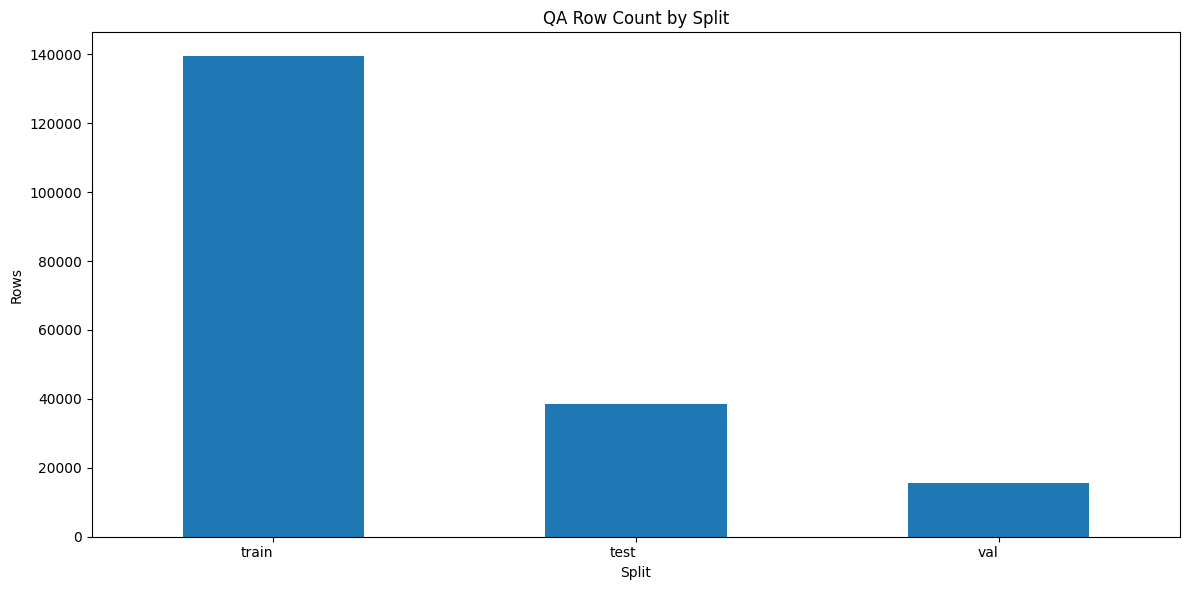

Saved: /kaggle/working/tinyagrivqa_bn/reports/figures/split_row_distribution.png


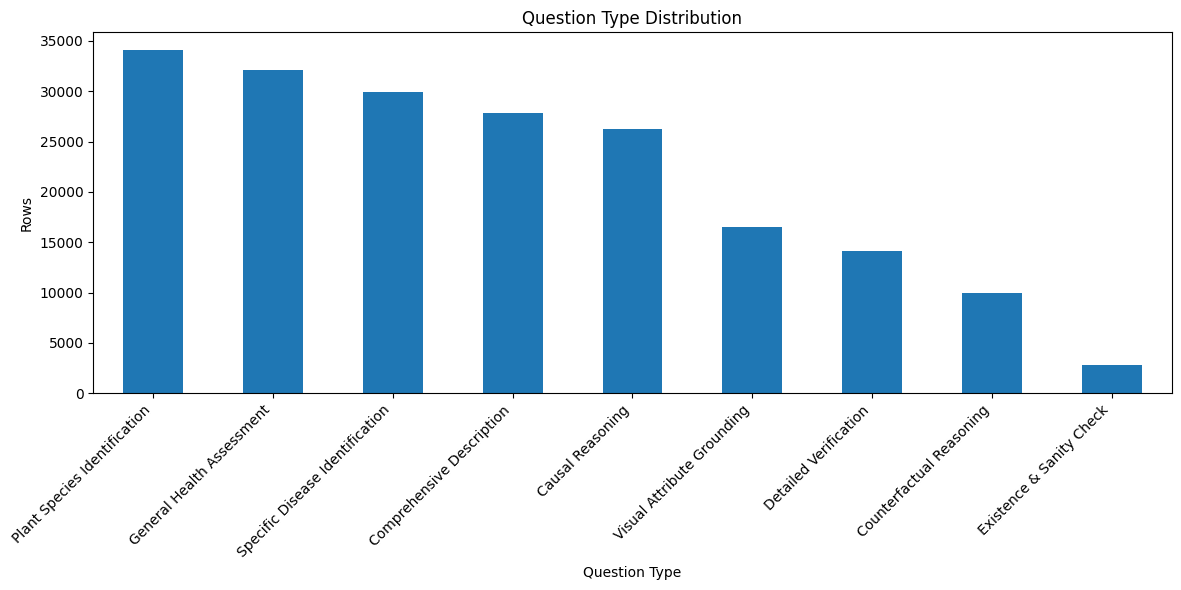

Saved: /kaggle/working/tinyagrivqa_bn/reports/figures/question_type_distribution.png


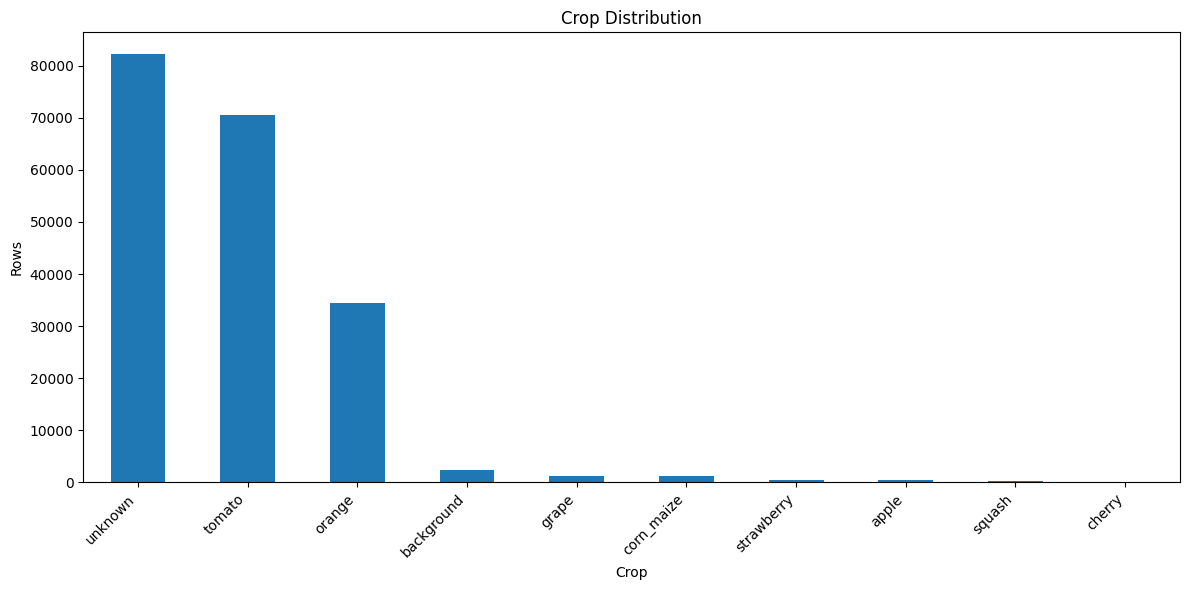

Saved: /kaggle/working/tinyagrivqa_bn/reports/figures/crop_distribution.png


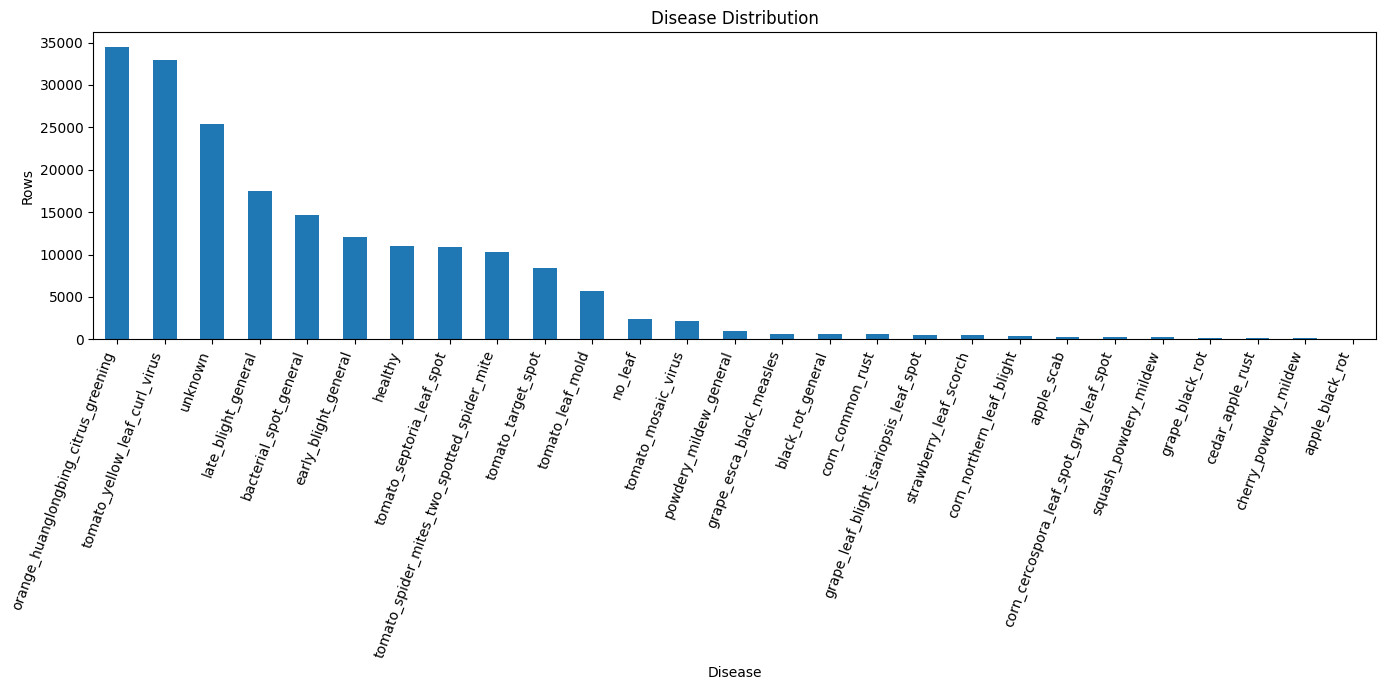

Saved: /kaggle/working/tinyagrivqa_bn/reports/figures/disease_distribution.png


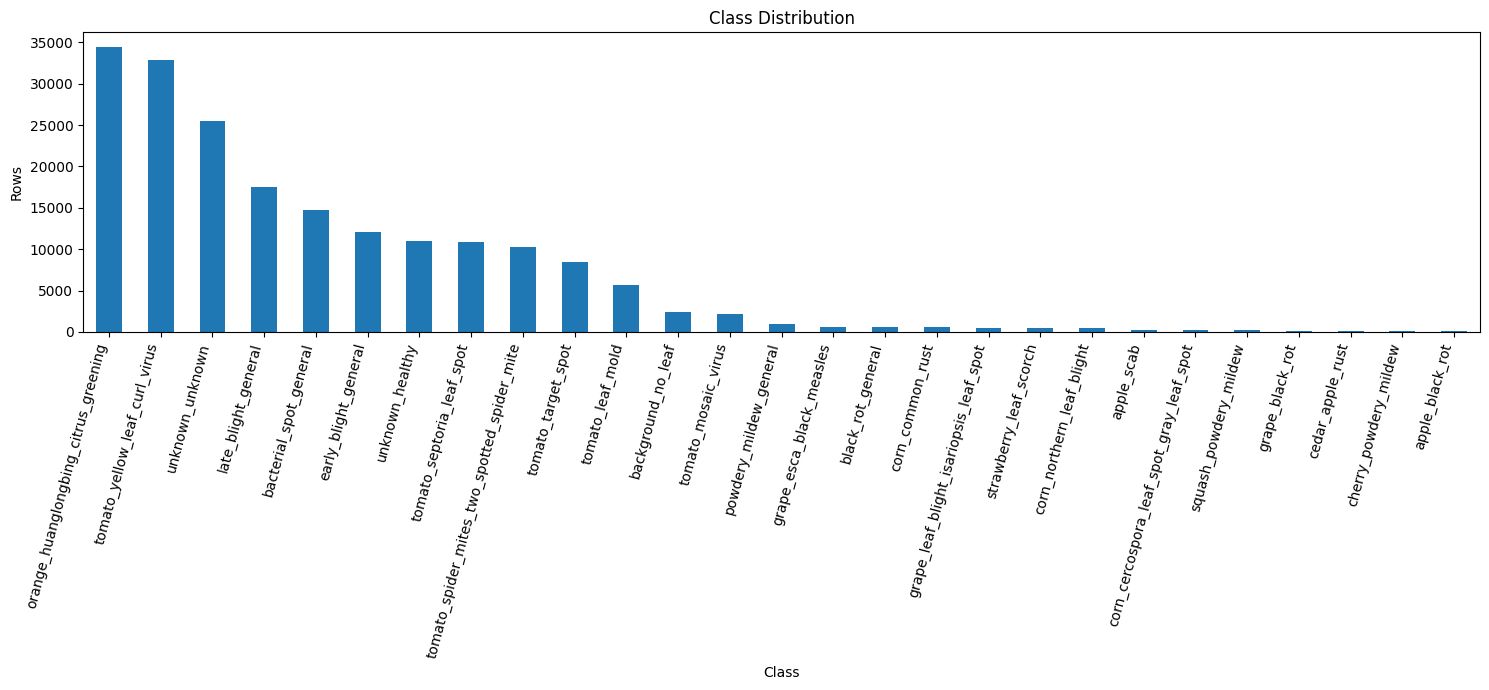

Saved: /kaggle/working/tinyagrivqa_bn/reports/figures/class_distribution.png


In [22]:
# ============================================================
# Cell 16: Basic visual distribution plots
# ============================================================

print("=" * 90)
print("Creating dataset distribution plots")
print("=" * 90)

import matplotlib.pyplot as plt

def save_bar_plot(series, title, xlabel, ylabel, save_path, top_n=None, figsize=(12, 6), rotate=45):
    if top_n is not None:
        series = series.head(top_n)

    plt.figure(figsize=figsize)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

save_bar_plot(
    final_df["final_split"].value_counts(),
    title="QA Row Count by Split",
    xlabel="Split",
    ylabel="Rows",
    save_path=FIG_DIR / "split_row_distribution.png",
    rotate=0,
)

save_bar_plot(
    final_df["question_type"].value_counts(),
    title="Question Type Distribution",
    xlabel="Question Type",
    ylabel="Rows",
    save_path=FIG_DIR / "question_type_distribution.png",
    rotate=45,
)

save_bar_plot(
    final_df["crop_label"].value_counts(),
    title="Crop Distribution",
    xlabel="Crop",
    ylabel="Rows",
    save_path=FIG_DIR / "crop_distribution.png",
    rotate=45,
)

save_bar_plot(
    final_df["disease_label"].value_counts(),
    title="Disease Distribution",
    xlabel="Disease",
    ylabel="Rows",
    save_path=FIG_DIR / "disease_distribution.png",
    top_n=40,
    figsize=(14, 7),
    rotate=70,
)

save_bar_plot(
    final_df["class_label"].value_counts(),
    title="Class Distribution",
    xlabel="Class",
    ylabel="Rows",
    save_path=FIG_DIR / "class_distribution.png",
    top_n=45,
    figsize=(15, 7),
    rotate=75,
)

In [23]:
# ============================================================
# Cell 17: Image integrity check
# ============================================================

print("=" * 90)
print("Checking image integrity")
print("=" * 90)

FULL_IMAGE_VERIFY = False
SAMPLE_VERIFY_N = 1000

unique_images_df = final_df[["image_id", "resolved_image_path", "final_split"]].drop_duplicates().reset_index(drop=True)

if FULL_IMAGE_VERIFY:
    verify_df = unique_images_df.copy()
else:
    n = min(SAMPLE_VERIFY_N, len(unique_images_df))
    verify_df = unique_images_df.sample(n=n, random_state=SEED).copy()

bad_images = []

for i, row in verify_df.iterrows():
    path = row["resolved_image_path"]
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        bad_images.append({
            "image_id": row["image_id"],
            "resolved_image_path": path,
            "error": str(e),
        })

bad_img_df = pd.DataFrame(bad_images)
bad_img_df.to_csv(REPORT_DIR / "bad_image_report.csv", index=False)

print("Images checked:", len(verify_df))
print("Bad images found:", len(bad_img_df))
print("Saved:", REPORT_DIR / "bad_image_report.csv")

if len(bad_img_df) > 0:
    display(bad_img_df.head(20))

Checking image integrity
Images checked: 1000
Bad images found: 0
Saved: /kaggle/working/tinyagrivqa_bn/reports/bad_image_report.csv


In [24]:
# ============================================================
# Cell 18: Save dataset card
# ============================================================

print("=" * 90)
print("Saving dataset card")
print("=" * 90)

dataset_card = f"""
# PlantVillageVQA-BN Dataset Card

## Dataset Name
PlantVillageVQA-BN

## Source
Derived from PlantVillageVQA annotation table and image files.

## Purpose
Bengali visual question answering for crop disease diagnosis under controlled plant-leaf image conditions.

## Number of QA Rows
{reports["num_rows"]}

## Number of Unique Images
{reports["num_images"]}

## Splits
Row counts:
{json.dumps(reports["split_row_counts"], ensure_ascii=False, indent=2)}

Image counts:
{json.dumps(reports["split_image_counts"], ensure_ascii=False, indent=2)}

## Question Types
{final_df["question_type"].nunique()} question types.

## Crop Labels
{final_df["crop_label"].nunique()} crop labels.

## Disease Labels
{final_df["disease_label"].nunique()} disease labels.

## Bengali Field Generation
Initial Bengali question and answer fields are generated using deterministic rule-based templates and disease/crop terminology normalization.

## Important Limitation
The Bengali fields must be manually audited before final paper submission. A stratified audit sample is saved at:

reports/audit/translation_and_label_audit_sample.csv

## Recommended Use
- Train/validation/test Bengali crop-disease VQA models.
- Evaluate compact vision-language models.
- Perform uncertainty-aware answer filtering.
- Generate Grad-CAM visual evidence in later portions.

## Not Recommended Use
This dataset should not be claimed as a real-world farmer diagnosis system without external field validation.
"""

card_path = PROCESSED_DIR / "DATASET_CARD_PlantVillageVQA_BN.md"
with open(card_path, "w", encoding="utf-8") as f:
    f.write(dataset_card.strip())

print("Saved:", card_path)
print(dataset_card[:1200])

Saving dataset card
Saved: /kaggle/working/tinyagrivqa_bn/data_bn/processed/DATASET_CARD_PlantVillageVQA_BN.md

# PlantVillageVQA-BN Dataset Card

## Dataset Name
PlantVillageVQA-BN

## Source
Derived from PlantVillageVQA annotation table and image files.

## Purpose
Bengali visual question answering for crop disease diagnosis under controlled plant-leaf image conditions.

## Number of QA Rows
193609

## Number of Unique Images
50073

## Splits
Row counts:
{
  "train": 139381,
  "test": 38632,
  "val": 15596
}

Image counts:
{
  "train": 36059,
  "test": 10007,
  "val": 4007
}

## Question Types
9 question types.

## Crop Labels
10 crop labels.

## Disease Labels
27 disease labels.

## Bengali Field Generation
Initial Bengali question and answer fields are generated using deterministic rule-based templates and disease/crop terminology normalization.

## Important Limitation
The Bengali fields must be manually audited before final paper submission. A stratified audit sample is saved at:

In [25]:
# ============================================================
# Cell 19: Final Portion 1 verification
# ============================================================

print("=" * 90)
print("PORTION 1 FINAL VERIFICATION")
print("=" * 90)

required_files = [
    PROCESSED_DIR / "plantvillagevqa_bn_clean.csv",
    PROCESSED_DIR / "train_bn.csv",
    PROCESSED_DIR / "val_bn.csv",
    PROCESSED_DIR / "test_bn.csv",
    PROCESSED_DIR / "label_mapping.json",
    PROCESSED_DIR / "image_label_table.csv",
    PROCESSED_DIR / "crop_name_bn_dictionary.json",
    PROCESSED_DIR / "disease_name_bn_dictionary.json",
    REPORT_DIR / "p1_summary.json",
    AUDIT_DIR / "translation_and_label_audit_sample.csv",
    PROCESSED_DIR / "DATASET_CARD_PlantVillageVQA_BN.md",
]

all_ok = True
for p in required_files:
    exists = p.exists()
    print(f"{'OK' if exists else 'MISSING'} | {p}")
    if not exists:
        all_ok = False

print("\nDataset row counts:")
for split_name in ["train", "val", "test"]:
    p = PROCESSED_DIR / f"{split_name}_bn.csv"
    tmp = pd.read_csv(p)
    print(
        split_name,
        "| rows:", len(tmp),
        "| images:", tmp["image_id"].nunique(),
        "| answers:", tmp["bangla_answer"].nunique(),
        "| classes:", tmp["class_label"].nunique()
    )

print("\nLeakage verification:")
train_ids = set(pd.read_csv(PROCESSED_DIR / "train_bn.csv")["image_id"].unique())
val_ids = set(pd.read_csv(PROCESSED_DIR / "val_bn.csv")["image_id"].unique())
test_ids = set(pd.read_csv(PROCESSED_DIR / "test_bn.csv")["image_id"].unique())

print("train ∩ val:", len(train_ids & val_ids))
print("train ∩ test:", len(train_ids & test_ids))
print("val ∩ test:", len(val_ids & test_ids))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

if all_ok:
    print("\nPORTION 1 COMPLETE.")
    print("You now have clean Bengali VQA CSV files ready for Portion 2 model architecture.")
else:
    print("\nPORTION 1 incomplete: some files are missing.")

PORTION 1 FINAL VERIFICATION
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/plantvillagevqa_bn_clean.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/train_bn.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/val_bn.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/test_bn.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/label_mapping.json
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/image_label_table.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/crop_name_bn_dictionary.json
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/disease_name_bn_dictionary.json
OK | /kaggle/working/tinyagrivqa_bn/reports/p1_summary.json
OK | /kaggle/working/tinyagrivqa_bn/reports/audit/translation_and_label_audit_sample.csv
OK | /kaggle/working/tinyagrivqa_bn/data_bn/processed/DATASET_CARD_PlantVillageVQA_BN.md

Dataset row counts:
train | rows: 139381 | images: 36059 | answers: 76 | classes: 27
val | rows: 15596 | images: 4007 | answers: 76 |

## portion 2

In [26]:
# ============================================================
# Portion 2 / Cell P2-00: Setup, device, and paths
# ============================================================

import os
import re
import json
import math
import time
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
P2_SEED = 42

def p2_seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic where practical.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

p2_seed_everything(P2_SEED)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/kaggle/working/tinyagrivqa_bn") if Path("/kaggle/working").exists() else Path("./tinyagrivqa_bn")

DATA_DIR = PROJECT_DIR / "data_bn"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_DIR / "reports"

P2_DIR = PROJECT_DIR / "portion2_architecture"
P2_DATA_DIR = P2_DIR / "data"
P2_MODEL_DIR = P2_DIR / "models"
P2_REPORT_DIR = P2_DIR / "reports"

for d in [P2_DIR, P2_DATA_DIR, P2_MODEL_DIR, P2_REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()

print("=" * 90)
print("PORTION 2 SETUP")
print("=" * 90)
print("Project dir:", PROJECT_DIR)
print("Device:", DEVICE)
print("Number of GPUs:", NUM_GPUS)

if torch.cuda.is_available():
    for i in range(NUM_GPUS):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))
else:
    print("GPU not available. Portion 2 can still run on CPU.")

PORTION 2 SETUP
Project dir: /kaggle/working/tinyagrivqa_bn
Device: cuda
Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [27]:
# ============================================================
# Portion 2 / Cell P2-01: Load Portion 1 outputs
# ============================================================

print("=" * 90)
print("Loading Portion 1 outputs")
print("=" * 90)

P1_FULL_PATH = PROCESSED_DIR / "plantvillagevqa_bn_clean.csv"
P1_TRAIN_PATH = PROCESSED_DIR / "train_bn.csv"
P1_VAL_PATH = PROCESSED_DIR / "val_bn.csv"
P1_TEST_PATH = PROCESSED_DIR / "test_bn.csv"
P1_MAPPING_PATH = PROCESSED_DIR / "label_mapping.json"

required_p1_files = [
    P1_FULL_PATH,
    P1_TRAIN_PATH,
    P1_VAL_PATH,
    P1_TEST_PATH,
    P1_MAPPING_PATH,
]

missing = [str(p) for p in required_p1_files if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing Portion 1 files: {missing}")

p1_df = pd.read_csv(P1_FULL_PATH)
p1_train_df = pd.read_csv(P1_TRAIN_PATH)
p1_val_df = pd.read_csv(P1_VAL_PATH)
p1_test_df = pd.read_csv(P1_TEST_PATH)

with open(P1_MAPPING_PATH, "r", encoding="utf-8") as f:
    p1_mapping = json.load(f)

print("P1 full shape:", p1_df.shape)
print("P1 train shape:", p1_train_df.shape)
print("P1 val shape:", p1_val_df.shape)
print("P1 test shape:", p1_test_df.shape)

print("\nColumns:")
print(p1_df.columns.tolist())

required_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "final_split",
    "question_type",
    "question",
    "answer",
    "bangla_question",
    "bangla_answer",
    "crop_label",
    "disease_label",
    "class_label",
]

missing_cols = [c for c in required_cols if c not in p1_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns from P1 final CSV: {missing_cols}")

print("\nSplit counts:")
display(p1_df["final_split"].value_counts())

print("\nP1 accepted. Now building P2 model-safe table.")

Loading Portion 1 outputs
P1 full shape: (193609, 22)
P1 train shape: (139381, 22)
P1 val shape: (15596, 22)
P1 test shape: (38632, 22)

Columns:
['qa_id', 'image_id', 'resolved_image_path', 'final_split', 'question_type', 'question_type_bn', 'question_type_id', 'question', 'answer', 'bangla_question', 'bangla_answer', 'answer_id', 'crop_label', 'crop_label_bn', 'crop_id', 'disease_label', 'disease_label_bn', 'disease_id', 'class_label', 'class_id', 'translation_method', 'needs_manual_audit']

Split counts:


final_split
train    139381
test      38632
val       15596
Name: count, dtype: int64


P1 accepted. Now building P2 model-safe table.


In [28]:
# ============================================================
# Portion 2 / Cell P2-02: P1 problem-fix layer for model-safe labels
# ============================================================

print("=" * 90)
print("Building P2 model-safe labels and answers")
print("=" * 90)

# ------------------------------------------------------------
# Bengali label dictionaries
# ------------------------------------------------------------
P2_CROP_BN = {
    "apple": "আপেল",
    "blueberry": "ব্লুবেরি",
    "cherry": "চেরি",
    "grape": "আঙুর",
    "orange": "কমলা",
    "peach": "পিচ",
    "pepper_bell": "বেল পেপার",
    "potato": "আলু",
    "raspberry": "রাস্পবেরি",
    "soybean": "সয়াবিন",
    "squash": "স্কোয়াশ",
    "strawberry": "স্ট্রবেরি",
    "tomato": "টমেটো",
    "corn_maize": "ভুট্টা",
    "background": "ব্যাকগ্রাউন্ড",
    "unknown": "অজানা",
}

P2_DISEASE_BN = {
    "apple_scab": "আপেল স্ক্যাব",
    "apple_black_rot": "আপেলের ব্ল্যাক রট",
    "cedar_apple_rust": "সিডার আপেল রাস্ট",
    "cherry_powdery_mildew": "চেরির পাউডারি মিলডিউ",
    "grape_black_rot": "আঙুরের ব্ল্যাক রট",
    "grape_esca_black_measles": "আঙুরের এস্কা বা ব্ল্যাক মিজলস",
    "grape_leaf_blight_isariopsis_leaf_spot": "আঙুরের লিফ ব্লাইট বা আইসারিওপসিস লিফ স্পট",
    "orange_huanglongbing_citrus_greening": "কমলার হুয়াংলংবিং বা সাইট্রাস গ্রিনিং",
    "peach_bacterial_spot": "পিচের ব্যাকটেরিয়াল স্পট",
    "pepper_bell_bacterial_spot": "বেল পেপারের ব্যাকটেরিয়াল স্পট",
    "potato_early_blight": "আলুর আর্লি ব্লাইট",
    "potato_late_blight": "আলুর লেট ব্লাইট",
    "squash_powdery_mildew": "স্কোয়াশের পাউডারি মিলডিউ",
    "strawberry_leaf_scorch": "স্ট্রবেরির লিফ স্কর্চ",
    "tomato_bacterial_spot": "টমেটোর ব্যাকটেরিয়াল স্পট",
    "tomato_early_blight": "টমেটোর আর্লি ব্লাইট",
    "tomato_late_blight": "টমেটোর লেট ব্লাইট",
    "tomato_leaf_mold": "টমেটোর লিফ মোল্ড",
    "tomato_septoria_leaf_spot": "টমেটোর সেপ্টোরিয়া লিফ স্পট",
    "tomato_spider_mites_two_spotted_spider_mite": "টমেটোর টু-স্পটেড স্পাইডার মাইট",
    "tomato_target_spot": "টমেটোর টার্গেট স্পট",
    "tomato_yellow_leaf_curl_virus": "টমেটোর ইয়েলো লিফ কার্ল ভাইরাস",
    "tomato_mosaic_virus": "টমেটোর মোজাইক ভাইরাস",
    "corn_cercospora_leaf_spot_gray_leaf_spot": "ভুট্টার সারকোস্পোরা লিফ স্পট বা গ্রে লিফ স্পট",
    "corn_common_rust": "ভুট্টার কমন রাস্ট",
    "corn_northern_leaf_blight": "ভুট্টার নর্দার্ন লিফ ব্লাইট",
    "late_blight_general": "লেট ব্লাইট",
    "early_blight_general": "আর্লি ব্লাইট",
    "bacterial_spot_general": "ব্যাকটেরিয়াল স্পট",
    "powdery_mildew_general": "পাউডারি মিলডিউ",
    "black_rot_general": "ব্ল্যাক রট",
    "leaf_spot_general": "লিফ স্পট",
    "leaf_blight_general": "লিফ ব্লাইট",
    "rust_general": "রাস্ট",
    "healthy": "সুস্থ",
    "no_leaf": "পাতা নেই",
    "unknown": "অজানা",
}

DISEASE_TO_CROP_P2 = {
    "apple_scab": "apple",
    "apple_black_rot": "apple",
    "cedar_apple_rust": "apple",
    "cherry_powdery_mildew": "cherry",
    "grape_black_rot": "grape",
    "grape_esca_black_measles": "grape",
    "grape_leaf_blight_isariopsis_leaf_spot": "grape",
    "orange_huanglongbing_citrus_greening": "orange",
    "peach_bacterial_spot": "peach",
    "pepper_bell_bacterial_spot": "pepper_bell",
    "potato_early_blight": "potato",
    "potato_late_blight": "potato",
    "squash_powdery_mildew": "squash",
    "strawberry_leaf_scorch": "strawberry",
    "tomato_bacterial_spot": "tomato",
    "tomato_early_blight": "tomato",
    "tomato_late_blight": "tomato",
    "tomato_leaf_mold": "tomato",
    "tomato_septoria_leaf_spot": "tomato",
    "tomato_spider_mites_two_spotted_spider_mite": "tomato",
    "tomato_target_spot": "tomato",
    "tomato_yellow_leaf_curl_virus": "tomato",
    "tomato_mosaic_virus": "tomato",
    "corn_cercospora_leaf_spot_gray_leaf_spot": "corn_maize",
    "corn_common_rust": "corn_maize",
    "corn_northern_leaf_blight": "corn_maize",
}

EXACT_CROP_ANSWERS = {
    "apple": "apple",
    "blueberry": "blueberry",
    "cherry": "cherry",
    "grape": "grape",
    "orange": "orange",
    "peach": "peach",
    "pepper": "pepper_bell",
    "bell pepper": "pepper_bell",
    "potato": "potato",
    "raspberry": "raspberry",
    "soybean": "soybean",
    "soy": "soybean",
    "squash": "squash",
    "strawberry": "strawberry",
    "tomato": "tomato",
    "corn": "corn_maize",
    "maize": "corn_maize",
}

YES_WORDS = {"yes", "yeah", "yep"}
NO_WORDS = {"no", "nope"}


def p2_norm_en(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("_", " ")
    x = re.sub(r"[^a-z0-9\s\-\(\),./]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def p2_regex_any(text, patterns):
    return any(re.search(p, text, flags=re.IGNORECASE) for p in patterns)


def p2_infer_crop_from_row(answer_text, question_type):
    ans = p2_norm_en(answer_text)
    qtype = str(question_type)

    # Exact crop answer is trusted mainly for species identification.
    if qtype == "Plant Species Identification":
        exact = ans.strip().strip(".")
        if exact in EXACT_CROP_ANSWERS:
            return EXACT_CROP_ANSWERS[exact], True

    # Trusted crop contexts.
    crop_patterns = {
        "tomato": [r"\btomato\s+(leaf|leaves|plant|crop)\b"],
        "potato": [r"\bpotato\s+(leaf|leaves|plant|crop)\b"],
        "corn_maize": [r"\b(corn|maize)\s+(leaf|leaves|plant|crop)\b"],
        "apple": [r"\bapple\s+(leaf|leaves|plant|tree|crop)\b"],
        "grape": [r"\bgrape\s+(leaf|leaves|plant|vine|crop)\b"],
        "orange": [r"\b(citrus|orange)\s+(leaf|leaves|plant|tree|crop)\b", r"\b(citrus greening|huanglongbing|hlb)\b"],
        "peach": [r"\bpeach\s+(leaf|leaves|plant|tree|crop)\b"],
        "pepper_bell": [r"\b(bell\s+pepper|pepper)\s+(leaf|leaves|plant|crop)\b"],
        "cherry": [r"\bcherry\s+(leaf|leaves|plant|tree|crop)\b"],
        "blueberry": [r"\bblueberry\s+(leaf|leaves|plant|crop)\b"],
        "raspberry": [r"\braspberry\s+(leaf|leaves|plant|crop)\b"],
        "soybean": [r"\b(soybean|soy)\s+(leaf|leaves|plant|crop)\b"],
        "squash": [r"\bsquash\s+(leaf|leaves|plant|crop)\b"],
        "strawberry": [r"\bstrawberry\s+(leaf|leaves|plant|crop)\b"],
    }

    for crop, patterns in crop_patterns.items():
        if p2_regex_any(ans, patterns):
            return crop, True

    return "unknown", False


SPECIFIC_DISEASE_RULES_P2 = [
    ("tomato_yellow_leaf_curl_virus", [r"\btylcv\b", r"yellow\s+leaf\s+curl", r"leaf\s+curl\s+virus"]),
    ("orange_huanglongbing_citrus_greening", [r"\bhlb\b", r"huanglongbing", r"citrus\s+greening", r"greening\s+disease"]),
    ("tomato_mosaic_virus", [r"tomato\s+mosaic", r"\bmosaic\s+virus\b"]),
    ("tomato_septoria_leaf_spot", [r"septoria"]),
    ("tomato_spider_mites_two_spotted_spider_mite", [r"two[- ]spotted\s+spider\s+mite", r"spider\s+mites?"]),
    ("tomato_target_spot", [r"target\s+spot"]),
    ("tomato_leaf_mold", [r"leaf\s+mold", r"leaf\s+mould"]),
    ("corn_cercospora_leaf_spot_gray_leaf_spot", [r"cercospora", r"gray\s+leaf\s+spot", r"grey\s+leaf\s+spot"]),
    ("corn_common_rust", [r"common\s+rust"]),
    ("corn_northern_leaf_blight", [r"northern\s+leaf\s+blight"]),
    ("grape_esca_black_measles", [r"\besca\b", r"black\s+measles"]),
    ("grape_leaf_blight_isariopsis_leaf_spot", [r"isariopsis", r"grape.*leaf\s+blight"]),
    ("strawberry_leaf_scorch", [r"leaf\s+scorch"]),
    ("cedar_apple_rust", [r"cedar\s+apple\s+rust"]),
    ("apple_scab", [r"\bapple\s+scab\b"]),
]

AMBIGUOUS_DISEASE_RULES_P2 = [
    ("late_blight_general", r"late\s+blight", {
        "tomato": "tomato_late_blight",
        "potato": "potato_late_blight",
        "default": "late_blight_general",
    }),
    ("early_blight_general", r"early\s+blight", {
        "tomato": "tomato_early_blight",
        "potato": "potato_early_blight",
        "default": "early_blight_general",
    }),
    ("bacterial_spot_general", r"bacterial\s+spot", {
        "tomato": "tomato_bacterial_spot",
        "pepper_bell": "pepper_bell_bacterial_spot",
        "peach": "peach_bacterial_spot",
        "default": "bacterial_spot_general",
    }),
    ("powdery_mildew_general", r"powdery\s+mildew", {
        "cherry": "cherry_powdery_mildew",
        "squash": "squash_powdery_mildew",
        "default": "powdery_mildew_general",
    }),
    ("black_rot_general", r"black\s+rot", {
        "apple": "apple_black_rot",
        "grape": "grape_black_rot",
        "default": "black_rot_general",
    }),
]


def p2_infer_disease_from_row(answer_text, crop_hint="unknown"):
    ans = p2_norm_en(answer_text)

    if p2_regex_any(ans, [
        r"background\s+image",
        r"without\s+a\s+plant\s+leaf",
        r"no\s+plant\s+leaf",
        r"not\s+contain\s+any\s+foliage",
    ]):
        return "no_leaf", True

    for disease, patterns in SPECIFIC_DISEASE_RULES_P2:
        if p2_regex_any(ans, patterns):
            return disease, True

    for general_label, pattern, mapping in AMBIGUOUS_DISEASE_RULES_P2:
        if re.search(pattern, ans, flags=re.IGNORECASE):
            if crop_hint in mapping:
                return mapping[crop_hint], True
            return mapping["default"], True

    # Healthy detection, but avoid counterfactual healthy.
    counterfactual_healthy = p2_regex_any(ans, [
        r"if\s+the\s+plant\s+were\s+healthy",
        r"if\s+it\s+were\s+healthy",
        r"if\s+the\s+leaf\s+were\s+healthy",
        r"would\s+be\s+healthy",
        r"healthy\s+version",
    ])

    if not counterfactual_healthy and p2_regex_any(ans, [
        r"\bhealthy\b",
        r"free\s+of\s+disease",
        r"disease\s+free",
        r"no\s+disease",
        r"unaffected",
        r"normal\s+leaf",
        r"no\s+visible\s+disease",
    ]):
        return "healthy", True

    return "unknown", False


def p2_make_class_label(crop_label, disease_label):
    if disease_label == "no_leaf":
        return "background_no_leaf"
    if disease_label == "healthy":
        if crop_label != "unknown":
            return f"{crop_label}_healthy"
        return "healthy_general"
    if disease_label == "unknown":
        return "unknown_unknown"
    return disease_label


def p2_bn_crop(crop_label):
    return P2_CROP_BN.get(crop_label, "অজানা")


def p2_bn_disease(disease_label):
    return P2_DISEASE_BN.get(disease_label, "অজানা")


def p2_make_answer_text(row, crop_label, disease_label):
    ans = p2_norm_en(row["answer"])
    qtype = str(row["question_type"])

    crop_bn = p2_bn_crop(crop_label)
    disease_bn = p2_bn_disease(disease_label)

    if ans in YES_WORDS:
        return "হ্যাঁ।"
    if ans in NO_WORDS:
        return "না।"

    if disease_label == "no_leaf" or crop_label == "background":
        return "এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।"

    if qtype == "Plant Species Identification":
        if crop_label != "unknown":
            return f"এটি {crop_bn} গাছের পাতা।"
        return "উদ্ভিদের প্রজাতি নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।"

    if qtype == "General Health Assessment":
        if disease_label == "healthy":
            return "পাতাটি সুস্থ বলে মনে হচ্ছে।"
        if disease_label != "unknown":
            return f"পাতাটি রোগাক্রান্ত; সম্ভাব্য রোগ হলো {disease_bn}।"
        return "পাতাটির স্বাস্থ্য অবস্থা নিশ্চিতভাবে বলা যাচ্ছে না।"

    if qtype == "Specific Disease Identification":
        if disease_label == "healthy":
            return "পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছে না।"
        if disease_label != "unknown":
            return f"সম্ভাব্য নির্দিষ্ট রোগ হলো {disease_bn}।"
        return "নির্দিষ্ট রোগ নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।"

    if qtype == "Comprehensive Description":
        if disease_label == "healthy":
            return "ছবিতে পাতার সুস্থ অবস্থা দেখা যাচ্ছে; উল্লেখযোগ্য রোগের লক্ষণ নেই।"
        if disease_label != "unknown":
            return f"ছবিতে পাতায় {disease_bn}-এর লক্ষণ দেখা যাচ্ছে।"
        return "ছবির পাতার অবস্থা স্পষ্টভাবে নির্ধারণ করা যায়নি।"

    if qtype == "Causal Reasoning":
        if disease_label == "healthy":
            return "দৃশ্যমানভাবে রোগজনিত কারণের শক্ত প্রমাণ নেই।"
        if disease_label != "unknown":
            return f"দৃশ্যমান লক্ষণগুলো সম্ভবত {disease_bn}-এর কারণে হয়েছে।"
        return "লক্ষণগুলোর কারণ নিশ্চিতভাবে বলা যাচ্ছে না।"

    if qtype == "Visual Attribute Grounding":
        if disease_label == "healthy":
            return "পাতায় রোগের স্পষ্ট দাগ, ক্ষত বা অস্বাভাবিক বিবর্ণতা দেখা যাচ্ছে না।"
        if disease_label != "unknown":
            return f"পাতার দৃশ্যমান দাগ, বিবর্ণতা বা ক্ষত {disease_bn}-এর সঙ্গে সামঞ্জস্যপূর্ণ।"
        return "দৃশ্যমান লক্ষণ নির্ভরযোগ্যভাবে ব্যাখ্যা করা যায়নি।"

    if qtype == "Detailed Verification":
        if "yes" in ans:
            return "হ্যাঁ।"
        if "no" in ans:
            return "না।"
        if disease_label == "healthy":
            return "পাতাটি সুস্থ বলে মনে হচ্ছে।"
        if disease_label != "unknown":
            return f"হ্যাঁ, ছবির লক্ষণগুলো {disease_bn}-এর সঙ্গে সামঞ্জস্যপূর্ণ।"
        return "নির্ভরযোগ্যভাবে যাচাই করা যায়নি।"

    if qtype == "Counterfactual Reasoning":
        if disease_label == "healthy":
            return "যেহেতু পাতাটি সুস্থ, রোগজনিত অতিরিক্ত পরিবর্তন প্রত্যাশিত নয়।"
        if disease_label != "unknown":
            return f"রোগ না থাকলে {disease_bn}-এর সঙ্গে সম্পর্কিত দাগ, বিবর্ণতা বা ক্ষত অনুপস্থিত থাকত।"
        return "বিকল্প পরিস্থিতি নির্ভরযোগ্যভাবে ব্যাখ্যা করা যায়নি।"

    if disease_label == "healthy":
        return "পাতাটি সুস্থ বলে মনে হচ্ছে।"
    if disease_label != "unknown":
        return f"সম্ভাব্য রোগ হলো {disease_bn}।"

    return "উত্তর নির্ভরযোগ্যভাবে নির্ধারণ করা যায়নি।"


def p2_build_row(row):
    crop_label, crop_trusted = p2_infer_crop_from_row(row["answer"], row["question_type"])
    disease_label, disease_trusted = p2_infer_disease_from_row(row["answer"], crop_hint=crop_label)

    # Disease-specific crop override.
    if disease_label in DISEASE_TO_CROP_P2:
        crop_label = DISEASE_TO_CROP_P2[disease_label]
        crop_trusted = True

    if disease_label == "no_leaf":
        crop_label = "background"
        crop_trusted = True

    # Do not use P1 crop/disease for loss unless row-level answer supports it.
    class_label = p2_make_class_label(crop_label, disease_label)
    answer_text = p2_make_answer_text(row, crop_label, disease_label)

    return pd.Series({
        "p2_crop_label": crop_label,
        "p2_disease_label": disease_label,
        "p2_class_label": class_label,
        "p2_crop_loss_mask": int(crop_label not in ["unknown"]),
        "p2_disease_loss_mask": int(disease_label not in ["unknown"]),
        "p2_class_loss_mask": int(class_label not in ["unknown_unknown"]),
        "p2_answer_text": answer_text,
        "p2_label_source": "row_level_rule_v1",
    })


p2_extra = p1_df.apply(p2_build_row, axis=1)
p2_df = pd.concat([p1_df.copy(), p2_extra], axis=1)

print("P2 table shape:", p2_df.shape)

print("\nP2 crop labels:")
display(p2_df["p2_crop_label"].value_counts().head(30))

print("\nP2 disease labels:")
display(p2_df["p2_disease_label"].value_counts().head(40))

print("\nP2 answer classes:", p2_df["p2_answer_text"].nunique())

print("\nLoss mask coverage:")
print("crop mask rows:", int(p2_df["p2_crop_loss_mask"].sum()), "/", len(p2_df))
print("disease mask rows:", int(p2_df["p2_disease_loss_mask"].sum()), "/", len(p2_df))
print("class mask rows:", int(p2_df["p2_class_loss_mask"].sum()), "/", len(p2_df))

# Sanity checks
bad_unknown_phrase = p2_df[p2_df["p2_answer_text"].str.contains("অজানা পাতা", regex=False, na=False)]
print("\nRows with bad phrase 'অজানা পাতা':", len(bad_unknown_phrase))

tylcv_bad = p2_df[
    p2_df["answer"].str.contains(r"\bTYLCV\b|yellow leaf curl", case=False, regex=True, na=False)
    & (p2_df["p2_disease_label"] != "tomato_yellow_leaf_curl_virus")
]
print("Bad P2 TYLCV mappings:", len(tylcv_bad))

if len(tylcv_bad) > 0:
    display(tylcv_bad[["image_id", "question_type", "answer", "p2_crop_label", "p2_disease_label", "p2_answer_text"]].head(20))

assert len(bad_unknown_phrase) == 0, "P2 answer still contains bad phrase."
assert len(tylcv_bad) == 0, "P2 TYLCV mapping failed."

print("\nP2 problem-fix layer passed.")

Building P2 model-safe labels and answers
P2 table shape: (193609, 30)

P2 crop labels:


p2_crop_label
unknown       122755
tomato         43357
orange         19268
grape           1352
corn_maize      1306
potato          1054
background       937
soybean          846
apple            758
strawberry       553
squash           406
peach            382
cherry           329
blueberry        243
raspberry         63
Name: count, dtype: int64


P2 disease labels:


p2_disease_label
unknown                                        109538
orange_huanglongbing_citrus_greening            16521
tomato_yellow_leaf_curl_virus                   16071
late_blight_general                              8727
bacterial_spot_general                           7554
healthy                                          6790
early_blight_general                             6000
tomato_septoria_leaf_spot                        5313
tomato_spider_mites_two_spotted_spider_mite      5028
tomato_target_spot                               4212
tomato_leaf_mold                                 2856
no_leaf                                           937
tomato_mosaic_virus                               735
powdery_mildew_general                            583
grape_esca_black_measles                          386
black_rot_general                                 370
corn_common_rust                                  340
grape_leaf_blight_isariopsis_leaf_spot            314
strawberry_


P2 answer classes: 87

Loss mask coverage:
crop mask rows: 70854 / 193609
disease mask rows: 84071 / 193609
class mask rows: 84071 / 193609

Rows with bad phrase 'অজানা পাতা': 0
Bad P2 TYLCV mappings: 0

P2 problem-fix layer passed.


In [29]:
# ============================================================
# Portion 2 / Cell P2-03: Build P2 label mappings and model-ready CSVs
# ============================================================

print("=" * 90)
print("Building P2 label mappings")
print("=" * 90)

# Use train split only to create answer vocabulary.
train_answer_counts = p2_df.loc[p2_df["final_split"] == "train", "p2_answer_text"].value_counts()
p2_answer_vocab = train_answer_counts.index.tolist()

UNK_ANSWER = "<unk_answer>"
if UNK_ANSWER not in p2_answer_vocab:
    p2_answer_vocab.append(UNK_ANSWER)

p2_answer_to_id = {a: i for i, a in enumerate(p2_answer_vocab)}

p2_df["p2_answer_id"] = p2_df["p2_answer_text"].map(p2_answer_to_id).fillna(p2_answer_to_id[UNK_ANSWER]).astype(int)

# Auxiliary label mappings include unknown labels.
p2_crop_vocab = sorted(p2_df["p2_crop_label"].dropna().unique().tolist())
p2_disease_vocab = sorted(p2_df["p2_disease_label"].dropna().unique().tolist())
p2_class_vocab = sorted(p2_df["p2_class_label"].dropna().unique().tolist())

p2_crop_to_id = {x: i for i, x in enumerate(p2_crop_vocab)}
p2_disease_to_id = {x: i for i, x in enumerate(p2_disease_vocab)}
p2_class_to_id = {x: i for i, x in enumerate(p2_class_vocab)}

p2_df["p2_crop_id"] = p2_df["p2_crop_label"].map(p2_crop_to_id).astype(int)
p2_df["p2_disease_id"] = p2_df["p2_disease_label"].map(p2_disease_to_id).astype(int)
p2_df["p2_class_id"] = p2_df["p2_class_label"].map(p2_class_to_id).astype(int)

# Final P2 columns
p2_keep_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "final_split",
    "question_type",
    "question_type_bn",
    "question",
    "answer",
    "bangla_question",
    "bangla_answer",
    "p2_answer_text",
    "p2_answer_id",
    "p2_crop_label",
    "p2_crop_id",
    "p2_crop_loss_mask",
    "p2_disease_label",
    "p2_disease_id",
    "p2_disease_loss_mask",
    "p2_class_label",
    "p2_class_id",
    "p2_class_loss_mask",
    "p2_label_source",
]

p2_model_df = p2_df[p2_keep_cols].copy()

p2_train_df = p2_model_df[p2_model_df["final_split"] == "train"].reset_index(drop=True)
p2_val_df = p2_model_df[p2_model_df["final_split"] == "val"].reset_index(drop=True)
p2_test_df = p2_model_df[p2_model_df["final_split"] == "test"].reset_index(drop=True)

# Save
P2_FULL_CSV = P2_DATA_DIR / "p2_model_table.csv"
P2_TRAIN_CSV = P2_DATA_DIR / "p2_train.csv"
P2_VAL_CSV = P2_DATA_DIR / "p2_val.csv"
P2_TEST_CSV = P2_DATA_DIR / "p2_test.csv"
P2_MAPPING_JSON = P2_DATA_DIR / "p2_label_mapping.json"

p2_model_df.to_csv(P2_FULL_CSV, index=False)
p2_train_df.to_csv(P2_TRAIN_CSV, index=False)
p2_val_df.to_csv(P2_VAL_CSV, index=False)
p2_test_df.to_csv(P2_TEST_CSV, index=False)

p2_mapping = {
    "answer_to_id": p2_answer_to_id,
    "crop_to_id": p2_crop_to_id,
    "disease_to_id": p2_disease_to_id,
    "class_to_id": p2_class_to_id,
    "id_to_answer": {str(v): k for k, v in p2_answer_to_id.items()},
    "id_to_crop": {str(v): k for k, v in p2_crop_to_id.items()},
    "id_to_disease": {str(v): k for k, v in p2_disease_to_id.items()},
    "id_to_class": {str(v): k for k, v in p2_class_to_id.items()},
}

with open(P2_MAPPING_JSON, "w", encoding="utf-8") as f:
    json.dump(p2_mapping, f, ensure_ascii=False, indent=2)

print("P2 full:", p2_model_df.shape)
print("P2 train:", p2_train_df.shape)
print("P2 val:", p2_val_df.shape)
print("P2 test:", p2_test_df.shape)

print("\nVocab sizes:")
print("answer:", len(p2_answer_to_id))
print("crop:", len(p2_crop_to_id))
print("disease:", len(p2_disease_to_id))
print("class:", len(p2_class_to_id))

print("\nSaved:")
print(" ", P2_FULL_CSV)
print(" ", P2_TRAIN_CSV)
print(" ", P2_VAL_CSV)
print(" ", P2_TEST_CSV)
print(" ", P2_MAPPING_JSON)

display(p2_model_df.head())

Building P2 label mappings
P2 full: (193609, 22)
P2 train: (139381, 22)
P2 val: (15596, 22)
P2 test: (38632, 22)

Vocab sizes:
answer: 88
crop: 15
disease: 27
class: 27

Saved:
  /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_model_table.csv
  /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_train.csv
  /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_val.csv
  /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_test.csv
  /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_label_mapping.json


,qa_id,image_id,resolved_image_path,final_split,question_type,question_type_bn,question,answer,bangla_question,bangla_answer,...,p2_crop_label,p2_crop_id,p2_crop_loss_mask,p2_disease_label,p2_disease_id,p2_disease_loss_mask,p2_class_label,p2_class_id,p2_class_loss_mask,p2_label_source
0,c050f9013a9a4713,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,Is there a plant leaf in this image?,No,ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?,না।,...,unknown,14,0,unknown,26,0,unknown_unknown,26,0,row_level_rule_v1
1,aac99a128aa8e76c,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,Does this picture contain any foliage?,No,এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?,না।,...,unknown,14,0,unknown,26,0,unknown_unknown,26,0,row_level_rule_v1
2,847e750561b6a003,image_000001.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Existence & Sanity Check,পাতা আছে কি না যাচাই,What is the primary subject of this image?,This is a background image without a plant leaf.,এই ছবিতে কি গাছের পাতা আছে?,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।,...,background,1,1,no_leaf,15,1,background_no_leaf,2,1,row_level_rule_v1
3,06acec87c6df6733,image_000002.JPG,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,নির্দিষ্ট রোগ শনাক্তকরণ,Provide the most precise disease identificatio...,This plant appears to be healthy and free of d...,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,দৃশ্যমান লক্ষণগুলো সম্ভবত সিডার আপেল রাস্ট-এর ...,...,unknown,14,0,healthy,13,1,healthy_general,14,1,row_level_rule_v1
4,2f276880aae77f16,image_000003.jpg,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,train,Specific Disease Identification,নির্দিষ্ট রোগ শনাক্তকরণ,Which disease or problem specifically affects ...,This is a healthy plant leaf.,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,দৃশ্যমান লক্ষণগুলো সম্ভবত পাউডারি মিলডিউ-এর কা...,...,unknown,14,0,healthy,13,1,healthy_general,14,1,row_level_rule_v1


In [30]:
# ============================================================
# Portion 2 / Cell P2-04: Lightweight Bengali tokenizer
# ============================================================

print("=" * 90)
print("Building lightweight Bengali tokenizer")
print("=" * 90)

TOKEN_RE = re.compile(r"[\u0980-\u09FF]+|[A-Za-z0-9]+|[^\s]", flags=re.UNICODE)

class BengaliWordTokenizer:
    def __init__(self, max_vocab_size=12000, min_freq=1, max_len=48):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.max_len = max_len

        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.cls_token = "<cls>"
        self.sep_token = "<sep>"

        self.token_to_id = {
            self.pad_token: 0,
            self.unk_token: 1,
            self.cls_token: 2,
            self.sep_token: 3,
        }
        self.id_to_token = {v: k for k, v in self.token_to_id.items()}

    def tokenize(self, text):
        text = "" if pd.isna(text) else str(text)
        text = text.strip()
        tokens = TOKEN_RE.findall(text)
        return tokens

    def fit(self, texts):
        counter = Counter()

        for text in texts:
            counter.update(self.tokenize(text))

        valid_tokens = [
            (tok, freq)
            for tok, freq in counter.items()
            if freq >= self.min_freq and tok not in self.token_to_id
        ]

        valid_tokens = sorted(valid_tokens, key=lambda x: (-x[1], x[0]))
        valid_tokens = valid_tokens[: max(0, self.max_vocab_size - len(self.token_to_id))]

        for tok, _ in valid_tokens:
            idx = len(self.token_to_id)
            self.token_to_id[tok] = idx
            self.id_to_token[idx] = tok

        return self

    def encode(self, text):
        tokens = [self.cls_token] + self.tokenize(text)[: self.max_len - 2] + [self.sep_token]
        ids = [self.token_to_id.get(tok, self.token_to_id[self.unk_token]) for tok in tokens]

        attention_mask = [1] * len(ids)

        pad_len = self.max_len - len(ids)
        if pad_len > 0:
            ids += [self.token_to_id[self.pad_token]] * pad_len
            attention_mask += [0] * pad_len

        return {
            "input_ids": np.array(ids, dtype=np.int64),
            "attention_mask": np.array(attention_mask, dtype=np.int64),
        }

    def save(self, path):
        obj = {
            "max_vocab_size": self.max_vocab_size,
            "min_freq": self.min_freq,
            "max_len": self.max_len,
            "token_to_id": self.token_to_id,
        }
        with open(path, "w", encoding="utf-8") as f:
            json.dump(obj, f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path):
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        tok = cls(
            max_vocab_size=obj["max_vocab_size"],
            min_freq=obj["min_freq"],
            max_len=obj["max_len"],
        )
        tok.token_to_id = {k: int(v) for k, v in obj["token_to_id"].items()}
        tok.id_to_token = {int(v): k for k, v in tok.token_to_id.items()}
        return tok


P2_MAX_TEXT_LEN = 48
P2_MAX_VOCAB = 12000

tokenizer = BengaliWordTokenizer(
    max_vocab_size=P2_MAX_VOCAB,
    min_freq=1,
    max_len=P2_MAX_TEXT_LEN,
)

tokenizer.fit(p2_train_df["bangla_question"].fillna("").tolist())

TOKENIZER_PATH = P2_DATA_DIR / "p2_bengali_word_tokenizer.json"
tokenizer.save(TOKENIZER_PATH)

print("Tokenizer vocab size:", len(tokenizer.token_to_id))
print("Max text length:", tokenizer.max_len)
print("Saved:", TOKENIZER_PATH)

sample_text = p2_train_df["bangla_question"].iloc[0]
print("\nSample text:", sample_text)
print("Encoded:", tokenizer.encode(sample_text))

Building lightweight Bengali tokenizer
Tokenizer vocab size: 132
Max text length: 48
Saved: /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_bengali_word_tokenizer.json

Sample text: ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?
Encoded: {'input_ids': array([  2, 106,  15, 105,  28,  40,  16,  17,   4,   3,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0]), 'attention_mask': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])}


In [31]:
# ============================================================
# Portion 2 / Cell P2-05: Dataset and transforms
# ============================================================

print("=" * 90)
print("Building Dataset class and transforms")
print("=" * 90)

try:
    import torchvision
    from torchvision import transforms
    TORCHVISION_OK = True
    print("torchvision available:", torchvision.__version__)
except Exception as e:
    TORCHVISION_OK = False
    print("torchvision unavailable. Error:", repr(e))


class SimpleImageTransform:
    """
    Fallback transform if torchvision is unavailable.
    """
    def __init__(self, image_size=224):
        self.image_size = image_size
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __call__(self, img):
        img = img.resize((self.image_size, self.image_size))
        arr = np.array(img).astype(np.float32) / 255.0  # [H, W, 3]
        tensor = torch.from_numpy(arr).permute(2, 0, 1) # [3, H, W]
        tensor = (tensor - self.mean) / self.std
        return tensor


def build_image_transform(image_size=224, train=False):
    if TORCHVISION_OK:
        if train:
            return transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply([
                    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)
                ], p=0.25),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    return SimpleImageTransform(image_size=image_size)


class TinyAgriVQADataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.image_transform = image_transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # Hard fallback to black image. Bad image count was 0 in P1 sample check,
            # but this keeps training robust.
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = self._load_image(row["resolved_image_path"])
        if self.image_transform is not None:
            img = self.image_transform(img)

        encoded = self.tokenizer.encode(row["bangla_question"])

        item = {
            "image": img.float(),                                           # [3, H, W]
            "input_ids": torch.tensor(encoded["input_ids"], dtype=torch.long),          # [L]
            "attention_mask": torch.tensor(encoded["attention_mask"], dtype=torch.long),# [L]

            "answer_id": torch.tensor(row["p2_answer_id"], dtype=torch.long),
            "crop_id": torch.tensor(row["p2_crop_id"], dtype=torch.long),
            "disease_id": torch.tensor(row["p2_disease_id"], dtype=torch.long),
            "class_id": torch.tensor(row["p2_class_id"], dtype=torch.long),

            "crop_loss_mask": torch.tensor(row["p2_crop_loss_mask"], dtype=torch.float32),
            "disease_loss_mask": torch.tensor(row["p2_disease_loss_mask"], dtype=torch.float32),
            "class_loss_mask": torch.tensor(row["p2_class_loss_mask"], dtype=torch.float32),

            "qa_id": row["qa_id"],
            "image_id": row["image_id"],
        }

        return item


P2_IMAGE_SIZE = 224

train_transform = build_image_transform(P2_IMAGE_SIZE, train=True)
eval_transform = build_image_transform(P2_IMAGE_SIZE, train=False)

train_ds = TinyAgriVQADataset(p2_train_df, tokenizer, train_transform)
val_ds = TinyAgriVQADataset(p2_val_df, tokenizer, eval_transform)
test_ds = TinyAgriVQADataset(p2_test_df, tokenizer, eval_transform)

print("Train dataset:", len(train_ds))
print("Val dataset:", len(val_ds))
print("Test dataset:", len(test_ds))

sample = train_ds[0]
print("\nSample tensor shapes:")
print("image:", tuple(sample["image"].shape))
print("input_ids:", tuple(sample["input_ids"].shape))
print("attention_mask:", tuple(sample["attention_mask"].shape))
print("answer_id:", sample["answer_id"])

Building Dataset class and transforms
torchvision available: 0.25.0+cu128
Train dataset: 139381
Val dataset: 15596
Test dataset: 38632

Sample tensor shapes:
image: (3, 224, 224)
input_ids: (48,)
attention_mask: (48,)
answer_id: tensor(0)


In [32]:
# ============================================================
# Portion 2 / Cell P2-06: DataLoader smoke batch
# ============================================================

print("=" * 90)
print("Building DataLoaders for smoke test")
print("=" * 90)

P2_SMOKE_BATCH_SIZE = 4

# For Portion 2 smoke test, keep workers low for Kaggle stability.
P2_NUM_WORKERS = 2 if os.cpu_count() and os.cpu_count() >= 4 else 0

train_loader_smoke = DataLoader(
    train_ds,
    batch_size=P2_SMOKE_BATCH_SIZE,
    shuffle=True,
    num_workers=P2_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

batch = next(iter(train_loader_smoke))

print("Batch keys:", batch.keys())
print("image:", tuple(batch["image"].shape))                 # [B, 3, 224, 224]
print("input_ids:", tuple(batch["input_ids"].shape))         # [B, L]
print("attention_mask:", tuple(batch["attention_mask"].shape)) # [B, L]
print("answer_id:", tuple(batch["answer_id"].shape))         # [B]
print("crop_id:", tuple(batch["crop_id"].shape))             # [B]
print("disease_id:", tuple(batch["disease_id"].shape))       # [B]
print("class_id:", tuple(batch["class_id"].shape))           # [B]

Building DataLoaders for smoke test
Batch keys: dict_keys(['image', 'input_ids', 'attention_mask', 'answer_id', 'crop_id', 'disease_id', 'class_id', 'crop_loss_mask', 'disease_loss_mask', 'class_loss_mask', 'qa_id', 'image_id'])
image: (4, 3, 224, 224)
input_ids: (4, 48)
attention_mask: (4, 48)
answer_id: (4,)
crop_id: (4,)
disease_id: (4,)
class_id: (4,)


In [33]:
# ============================================================
# Portion 2 / Cell P2-07: TinyAgriVQA-BN model architecture
# ============================================================

print("=" * 90)
print("Defining TinyAgriVQA-BN architecture")
print("=" * 90)


class FallbackTinyCNN(nn.Module):
    """
    Used only if torchvision is unavailable.
    """
    def __init__(self, out_dim=512):
        super().__init__()
        self.out_dim = out_dim

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # [B, 32, 112, 112]
            nn.BatchNorm2d(32),
            nn.SiLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # [B, 64, 56, 56]
            nn.BatchNorm2d(64),
            nn.SiLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # [B, 128, 28, 28]
            nn.BatchNorm2d(128),
            nn.SiLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# [B, 256, 14, 14]
            nn.BatchNorm2d(256),
            nn.SiLU(),

            nn.Conv2d(256, out_dim, kernel_size=3, stride=2, padding=1), # [B, D, 7, 7]
            nn.BatchNorm2d(out_dim),
            nn.SiLU(),

            nn.AdaptiveAvgPool2d(1), # [B, D, 1, 1]
        )

    def forward(self, x):
        x = self.net(x)           # [B, D, 1, 1]
        x = x.flatten(1)          # [B, D]
        return x


class ImageEncoder(nn.Module):
    def __init__(self, backbone_name="resnet34", pretrained=False):
        super().__init__()
        self.backbone_name = backbone_name
        self.pretrained = pretrained

        if TORCHVISION_OK and backbone_name == "resnet34":
            from torchvision import models

            weights = None
            if pretrained:
                # Keep None by default to avoid internet-dependent failures.
                # In Portion 3, you can set pretrained=True if Kaggle internet/cache is ready.
                try:
                    weights = models.ResNet34_Weights.DEFAULT
                except Exception:
                    weights = None

            model = models.resnet34(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        elif TORCHVISION_OK and backbone_name == "resnet18":
            from torchvision import models

            weights = None
            if pretrained:
                try:
                    weights = models.ResNet18_Weights.DEFAULT
                except Exception:
                    weights = None

            model = models.resnet18(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        else:
            self.out_dim = 512
            self.encoder = FallbackTinyCNN(out_dim=self.out_dim)

    def forward(self, images):
        # images: [B, 3, H, W]
        feats = self.encoder(images)  # [B, image_dim]
        return feats


class TinyTextTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len=48,
        d_model=256,
        n_heads=4,
        n_layers=3,
        ff_dim=768,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.max_len = max_len
        self.d_model = d_model
        self.pad_id = pad_id

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask):
        # input_ids: [B, L]
        # attention_mask: [B, L]
        B, L = input_ids.shape

        x = self.token_emb(input_ids)                  # [B, L, D]
        x = x + self.pos_emb[:, :L, :]                 # [B, L, D]
        x = self.dropout(x)

        key_padding_mask = attention_mask.eq(0)        # [B, L], True means pad

        h = self.encoder(
            x,
            src_key_padding_mask=key_padding_mask,
        )                                             # [B, L, D]

        h = self.norm(h)                              # [B, L, D]

        mask = attention_mask.unsqueeze(-1).float()    # [B, L, 1]
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0) # [B, D]

        return pooled, h


class GatedMultimodalFusion(nn.Module):
    def __init__(self, image_dim, text_dim, fusion_dim=512, dropout=0.10):
        super().__init__()

        self.image_proj = nn.Sequential(
            nn.Linear(image_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 4, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, fusion_dim),
            nn.Sigmoid(),
        )

        self.out = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
        )

    def forward(self, image_feat, text_feat):
        # image_feat: [B, image_dim]
        # text_feat: [B, text_dim]
        v = self.image_proj(image_feat)   # [B, F]
        t = self.text_proj(text_feat)     # [B, F]

        z = torch.cat([v, t, v * t, torch.abs(v - t)], dim=-1) # [B, 4F]
        g = self.gate(z)                  # [B, F]

        fused = g * v + (1.0 - g) * t     # [B, F]
        fused = self.out(fused)           # [B, F]
        return fused


class TinyAgriVQABN(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_answers,
        num_crops,
        num_diseases,
        num_classes,
        max_len=48,
        image_backbone="resnet34",
        image_pretrained=False,
        text_dim=256,
        text_layers=3,
        text_heads=4,
        text_ff_dim=768,
        fusion_dim=512,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.image_encoder = ImageEncoder(
            backbone_name=image_backbone,
            pretrained=image_pretrained,
        )

        self.text_encoder = TinyTextTransformer(
            vocab_size=vocab_size,
            max_len=max_len,
            d_model=text_dim,
            n_heads=text_heads,
            n_layers=text_layers,
            ff_dim=text_ff_dim,
            dropout=dropout,
            pad_id=pad_id,
        )

        self.fusion = GatedMultimodalFusion(
            image_dim=self.image_encoder.out_dim,
            text_dim=text_dim,
            fusion_dim=fusion_dim,
            dropout=dropout,
        )

        self.answer_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_answers),
        )

        self.crop_head = nn.Linear(fusion_dim, num_crops)
        self.disease_head = nn.Linear(fusion_dim, num_diseases)
        self.class_head = nn.Linear(fusion_dim, num_classes)

        # Confidence head for later uncertainty-aware filtering.
        self.confidence_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 1),
        )

    def forward(self, images, input_ids, attention_mask):
        # images: [B, 3, H, W]
        # input_ids: [B, L]
        # attention_mask: [B, L]

        image_feat = self.image_encoder(images)                         # [B, image_dim]
        text_feat, token_features = self.text_encoder(input_ids, attention_mask) # [B, text_dim], [B, L, text_dim]

        fused = self.fusion(image_feat, text_feat)                      # [B, fusion_dim]

        answer_logits = self.answer_head(fused)                         # [B, num_answers]
        crop_logits = self.crop_head(fused)                             # [B, num_crops]
        disease_logits = self.disease_head(fused)                       # [B, num_diseases]
        class_logits = self.class_head(fused)                           # [B, num_classes]
        confidence_logit = self.confidence_head(fused).squeeze(-1)      # [B]

        return {
            "answer_logits": answer_logits,
            "crop_logits": crop_logits,
            "disease_logits": disease_logits,
            "class_logits": class_logits,
            "confidence_logit": confidence_logit,
            "fused_features": fused,
            "image_features": image_feat,
            "text_features": text_feat,
            "token_features": token_features,
        }


print("Model classes defined.")

Defining TinyAgriVQA-BN architecture
Model classes defined.


In [34]:
# ============================================================
# Portion 2 / Cell P2-08: Masked multitask loss
# ============================================================

print("=" * 90)
print("Defining masked multitask loss")
print("=" * 90)


def masked_ce_loss(logits, targets, mask):
    """
    logits: [B, C]
    targets: [B]
    mask: [B], 1 for reliable label, 0 for ignored label
    """
    per_sample = F.cross_entropy(logits, targets, reduction="none") # [B]
    mask = mask.float()

    denom = mask.sum().clamp_min(1.0)
    loss = (per_sample * mask).sum() / denom

    return loss


def compute_tinyagrivqa_loss(
    outputs,
    batch,
    lambda_answer=1.00,
    lambda_crop=0.15,
    lambda_disease=0.25,
    lambda_class=0.15,
):
    """
    Main objective:
        answer classification

    Auxiliary objectives:
        crop / disease / class classification,
        but only on reliable rows using P2 masks.
    """

    answer_loss = F.cross_entropy(
        outputs["answer_logits"],
        batch["answer_id"],
        reduction="mean",
    )

    crop_loss = masked_ce_loss(
        outputs["crop_logits"],
        batch["crop_id"],
        batch["crop_loss_mask"],
    )

    disease_loss = masked_ce_loss(
        outputs["disease_logits"],
        batch["disease_id"],
        batch["disease_loss_mask"],
    )

    class_loss = masked_ce_loss(
        outputs["class_logits"],
        batch["class_id"],
        batch["class_loss_mask"],
    )

    total = (
        lambda_answer * answer_loss
        + lambda_crop * crop_loss
        + lambda_disease * disease_loss
        + lambda_class * class_loss
    )

    return {
        "loss": total,
        "answer_loss": answer_loss.detach(),
        "crop_loss": crop_loss.detach(),
        "disease_loss": disease_loss.detach(),
        "class_loss": class_loss.detach(),
    }


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "total": total,
        "trainable": trainable,
        "total_m": total / 1e6,
        "trainable_m": trainable / 1e6,
    }


print("Loss function defined.")

Defining masked multitask loss
Loss function defined.


In [35]:
# ============================================================
# Portion 2 / Cell P2-09: Instantiate TinyAgriVQA-BN
# ============================================================

print("=" * 90)
print("Instantiating TinyAgriVQA-BN")
print("=" * 90)

P2_MODEL_CONFIG = {
    "model_name": "TinyAgriVQA-BN",
    "image_backbone": "resnet34",
    "image_pretrained": False,
    "image_size": P2_IMAGE_SIZE,
    "vocab_size": len(tokenizer.token_to_id),
    "max_len": tokenizer.max_len,
    "num_answers": len(p2_answer_to_id),
    "num_crops": len(p2_crop_to_id),
    "num_diseases": len(p2_disease_to_id),
    "num_classes": len(p2_class_to_id),
    "text_dim": 256,
    "text_layers": 3,
    "text_heads": 4,
    "text_ff_dim": 768,
    "fusion_dim": 512,
    "dropout": 0.10,
    "pad_id": tokenizer.token_to_id[tokenizer.pad_token],
}

model = TinyAgriVQABN(
    vocab_size=P2_MODEL_CONFIG["vocab_size"],
    num_answers=P2_MODEL_CONFIG["num_answers"],
    num_crops=P2_MODEL_CONFIG["num_crops"],
    num_diseases=P2_MODEL_CONFIG["num_diseases"],
    num_classes=P2_MODEL_CONFIG["num_classes"],
    max_len=P2_MODEL_CONFIG["max_len"],
    image_backbone=P2_MODEL_CONFIG["image_backbone"],
    image_pretrained=P2_MODEL_CONFIG["image_pretrained"],
    text_dim=P2_MODEL_CONFIG["text_dim"],
    text_layers=P2_MODEL_CONFIG["text_layers"],
    text_heads=P2_MODEL_CONFIG["text_heads"],
    text_ff_dim=P2_MODEL_CONFIG["text_ff_dim"],
    fusion_dim=P2_MODEL_CONFIG["fusion_dim"],
    dropout=P2_MODEL_CONFIG["dropout"],
    pad_id=P2_MODEL_CONFIG["pad_id"],
)

param_info = count_parameters(model)

print("Parameter count:")
print(json.dumps(param_info, indent=2))

print("\nExpected target:")
print("Tiny conference model target: around 20M–30M parameters.")
print("Actual total parameters:", round(param_info["total_m"], 3), "M")

with open(P2_MODEL_DIR / "p2_model_config.json", "w", encoding="utf-8") as f:
    json.dump(P2_MODEL_CONFIG, f, ensure_ascii=False, indent=2)

print("\nSaved model config:", P2_MODEL_DIR / "p2_model_config.json")

Instantiating TinyAgriVQA-BN
Parameter count:
{
  "total": 25490398,
  "trainable": 25490398,
  "total_m": 25.490398,
  "trainable_m": 25.490398
}

Expected target:
Tiny conference model target: around 20M–30M parameters.
Actual total parameters: 25.49 M

Saved model config: /kaggle/working/tinyagrivqa_bn/portion2_architecture/models/p2_model_config.json


In [36]:
# ============================================================
# Portion 2 / Cell P2-10: Sanity forward pass
# ============================================================

print("=" * 90)
print("Running sanity forward pass")
print("=" * 90)

# Move batch to device.
batch_device = {}

for k, v in batch.items():
    if torch.is_tensor(v):
        batch_device[k] = v.to(DEVICE)
    else:
        batch_device[k] = v

model = model.to(DEVICE)

# For smoke test only. Portion 3 should use DDP if doing serious 2-GPU training.
if NUM_GPUS > 1:
    print("Multiple GPUs detected. Wrapping model with nn.DataParallel for smoke test.")
    model_for_forward = nn.DataParallel(model)
else:
    model_for_forward = model

model_for_forward.eval()

with torch.no_grad():
    outputs = model_for_forward(
        images=batch_device["image"],
        input_ids=batch_device["input_ids"],
        attention_mask=batch_device["attention_mask"],
    )

loss_dict = compute_tinyagrivqa_loss(outputs, batch_device)

print("Output shapes:")
for k, v in outputs.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape))

print("\nLoss values:")
for k, v in loss_dict.items():
    if torch.is_tensor(v):
        print(k, float(v.detach().cpu()))

# Shape assertions
B = batch_device["image"].shape[0]

assert outputs["answer_logits"].shape == (B, P2_MODEL_CONFIG["num_answers"])
assert outputs["crop_logits"].shape == (B, P2_MODEL_CONFIG["num_crops"])
assert outputs["disease_logits"].shape == (B, P2_MODEL_CONFIG["num_diseases"])
assert outputs["class_logits"].shape == (B, P2_MODEL_CONFIG["num_classes"])
assert outputs["confidence_logit"].shape == (B,)

print("\nSanity forward pass passed.")

Running sanity forward pass
Multiple GPUs detected. Wrapping model with nn.DataParallel for smoke test.
Output shapes:
answer_logits (4, 88)
crop_logits (4, 15)
disease_logits (4, 27)
class_logits (4, 27)
confidence_logit (4,)
fused_features (4, 512)
image_features (4, 512)
text_features (4, 256)
token_features (4, 48, 256)

Loss values:
loss 6.143577575683594
answer_loss 4.496878623962402
crop_loss 2.3874456882476807
disease_loss 3.0799012184143066
class_loss 3.457376003265381

Sanity forward pass passed.


In [37]:
# ============================================================
# Portion 2 / Cell P2-11: Decode utility for qualitative checking
# ============================================================

print("=" * 90)
print("Building prediction decode utility")
print("=" * 90)

id_to_answer = {int(v): k for k, v in p2_answer_to_id.items()}
id_to_crop = {int(v): k for k, v in p2_crop_to_id.items()}
id_to_disease = {int(v): k for k, v in p2_disease_to_id.items()}
id_to_class = {int(v): k for k, v in p2_class_to_id.items()}


def decode_predictions(outputs, top_k=3):
    answer_probs = F.softmax(outputs["answer_logits"], dim=-1)
    top_probs, top_ids = torch.topk(answer_probs, k=min(top_k, answer_probs.shape[-1]), dim=-1)

    decoded = []

    for i in range(top_ids.shape[0]):
        row = []
        for j in range(top_ids.shape[1]):
            ans_id = int(top_ids[i, j].detach().cpu())
            prob = float(top_probs[i, j].detach().cpu())
            row.append({
                "answer_id": ans_id,
                "answer_text": id_to_answer.get(ans_id, "<missing>"),
                "prob": prob,
            })
        decoded.append(row)

    return decoded


decoded = decode_predictions(outputs, top_k=3)

for i, preds in enumerate(decoded[:2]):
    print(f"\nSample {i}")
    print("qa_id:", batch["qa_id"][i])
    print("image_id:", batch["image_id"][i])
    print("gold answer:", id_to_answer[int(batch['answer_id'][i])])
    print("top predictions:")
    for p in preds:
        print(" ", p)

Building prediction decode utility

Sample 0
qa_id: e20a68de7160e10e
image_id: image_004060.JPG
gold answer: না।
top predictions:
  {'answer_id': 75, 'answer_text': 'দৃশ্যমান লক্ষণগুলো সম্ভবত আঙুরের লিফ ব্লাইট বা আইসারিওপসিস লিফ স্পট-এর কারণে হয়েছে।', 'prob': 0.019589321687817574}
  {'answer_id': 71, 'answer_text': 'ছবিতে পাতায় ভুট্টার কমন রাস্ট-এর লক্ষণ দেখা যাচ্ছে।', 'prob': 0.018608374521136284}
  {'answer_id': 67, 'answer_text': 'ছবিতে পাতায় আঙুরের এস্কা বা ব্ল্যাক মিজলস-এর লক্ষণ দেখা যাচ্ছে।', 'prob': 0.017506122589111328}

Sample 1
qa_id: d8c6f2277fa8abf9
image_id: image_024486.JPG
gold answer: নির্দিষ্ট রোগ নির্ভরযোগ্যভাবে শনাক্ত করা যায়নি।
top predictions:
  {'answer_id': 75, 'answer_text': 'দৃশ্যমান লক্ষণগুলো সম্ভবত আঙুরের লিফ ব্লাইট বা আইসারিওপসিস লিফ স্পট-এর কারণে হয়েছে।', 'prob': 0.017225278541445732}
  {'answer_id': 71, 'answer_text': 'ছবিতে পাতায় ভুট্টার কমন রাস্ট-এর লক্ষণ দেখা যাচ্ছে।', 'prob': 0.016891006380319595}
  {'answer_id': 21, 'answer_text': 'দৃশ্যমান লক্ষ

In [38]:
# ============================================================
# Portion 2 / Cell P2-12: Save architecture checkpoint and report
# ============================================================

print("=" * 90)
print("Saving Portion 2 artifacts")
print("=" * 90)

# Unwrap if DataParallel was used.
model_to_save = model_for_forward.module if isinstance(model_for_forward, nn.DataParallel) else model_for_forward

P2_SMOKE_CKPT = P2_MODEL_DIR / "tinyagrivqa_bn_architecture_smoke.pt"

torch.save(
    {
        "model_state_dict": model_to_save.state_dict(),
        "model_config": P2_MODEL_CONFIG,
        "param_info": param_info,
        "label_mapping_path": str(P2_MAPPING_JSON),
        "tokenizer_path": str(TOKENIZER_PATH),
        "note": "Architecture smoke checkpoint only. Not trained.",
    },
    P2_SMOKE_CKPT,
)

p2_report = {
    "portion": 2,
    "status": "complete_architecture_smoke_test",
    "device": str(DEVICE),
    "num_gpus": NUM_GPUS,
    "model_config": P2_MODEL_CONFIG,
    "parameter_info": param_info,
    "data_files": {
        "p2_full_csv": str(P2_FULL_CSV),
        "p2_train_csv": str(P2_TRAIN_CSV),
        "p2_val_csv": str(P2_VAL_CSV),
        "p2_test_csv": str(P2_TEST_CSV),
        "p2_mapping_json": str(P2_MAPPING_JSON),
        "tokenizer_json": str(TOKENIZER_PATH),
        "smoke_checkpoint": str(P2_SMOKE_CKPT),
    },
    "split_rows": {
        "train": int(len(p2_train_df)),
        "val": int(len(p2_val_df)),
        "test": int(len(p2_test_df)),
    },
    "vocab_sizes": {
        "text_vocab": int(len(tokenizer.token_to_id)),
        "answer": int(len(p2_answer_to_id)),
        "crop": int(len(p2_crop_to_id)),
        "disease": int(len(p2_disease_to_id)),
        "class": int(len(p2_class_to_id)),
    },
    "loss_mask_rows": {
        "crop": int(p2_model_df["p2_crop_loss_mask"].sum()),
        "disease": int(p2_model_df["p2_disease_loss_mask"].sum()),
        "class": int(p2_model_df["p2_class_loss_mask"].sum()),
    },
}

P2_REPORT_JSON = P2_REPORT_DIR / "p2_architecture_report.json"

with open(P2_REPORT_JSON, "w", encoding="utf-8") as f:
    json.dump(p2_report, f, ensure_ascii=False, indent=2)

print("Saved checkpoint:", P2_SMOKE_CKPT)
print("Saved report:", P2_REPORT_JSON)

print("\nReport:")
print(json.dumps(p2_report, ensure_ascii=False, indent=2)[:3000])

Saving Portion 2 artifacts
Saved checkpoint: /kaggle/working/tinyagrivqa_bn/portion2_architecture/models/tinyagrivqa_bn_architecture_smoke.pt
Saved report: /kaggle/working/tinyagrivqa_bn/portion2_architecture/reports/p2_architecture_report.json

Report:
{
  "portion": 2,
  "status": "complete_architecture_smoke_test",
  "device": "cuda",
  "num_gpus": 2,
  "model_config": {
    "model_name": "TinyAgriVQA-BN",
    "image_backbone": "resnet34",
    "image_pretrained": false,
    "image_size": 224,
    "vocab_size": 132,
    "max_len": 48,
    "num_answers": 88,
    "num_crops": 15,
    "num_diseases": 27,
    "num_classes": 27,
    "text_dim": 256,
    "text_layers": 3,
    "text_heads": 4,
    "text_ff_dim": 768,
    "fusion_dim": 512,
    "dropout": 0.1,
    "pad_id": 0
  },
  "parameter_info": {
    "total": 25490398,
    "trainable": 25490398,
    "total_m": 25.490398,
    "trainable_m": 25.490398
  },
  "data_files": {
    "p2_full_csv": "/kaggle/working/tinyagrivqa_bn/portion2_arch

In [39]:
# ============================================================
# Portion 2 / Cell P2-13: Final verification
# ============================================================

print("=" * 90)
print("PORTION 2 FINAL VERIFICATION")
print("=" * 90)

required_p2_files = [
    P2_FULL_CSV,
    P2_TRAIN_CSV,
    P2_VAL_CSV,
    P2_TEST_CSV,
    P2_MAPPING_JSON,
    TOKENIZER_PATH,
    P2_MODEL_DIR / "p2_model_config.json",
    P2_SMOKE_CKPT,
    P2_REPORT_JSON,
]

all_ok = True

for p in required_p2_files:
    exists = Path(p).exists()
    print(f"{'OK' if exists else 'MISSING'} | {p}")
    if not exists:
        all_ok = False

# Reload and verify.
tmp_train = pd.read_csv(P2_TRAIN_CSV)
tmp_val = pd.read_csv(P2_VAL_CSV)
tmp_test = pd.read_csv(P2_TEST_CSV)

print("\nRows:")
print("train:", len(tmp_train))
print("val:", len(tmp_val))
print("test:", len(tmp_test))

print("\nUnique images:")
print("train:", tmp_train["image_id"].nunique())
print("val:", tmp_val["image_id"].nunique())
print("test:", tmp_test["image_id"].nunique())

train_ids = set(tmp_train["image_id"].unique())
val_ids = set(tmp_val["image_id"].unique())
test_ids = set(tmp_test["image_id"].unique())

print("\nLeakage check:")
print("train ∩ val:", len(train_ids & val_ids))
print("train ∩ test:", len(train_ids & test_ids))
print("val ∩ test:", len(val_ids & test_ids))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("\nAnswer classes:", tmp_train["p2_answer_id"].nunique())
print("Crop aux mask rows:", int(tmp_train["p2_crop_loss_mask"].sum()))
print("Disease aux mask rows:", int(tmp_train["p2_disease_loss_mask"].sum()))
print("Class aux mask rows:", int(tmp_train["p2_class_loss_mask"].sum()))

if all_ok:
    print("\nPORTION 2 COMPLETE.")
    print("Architecture, tokenizer, dataset adapter, masked losses, and forward pass are ready.")
    print("Next: Portion 3 training with Kaggle T4 × 2.")
else:
    print("\nPORTION 2 incomplete: some files are missing.")

PORTION 2 FINAL VERIFICATION
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_model_table.csv
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_train.csv
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_val.csv
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_test.csv
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_label_mapping.json
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/data/p2_bengali_word_tokenizer.json
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/models/p2_model_config.json
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/models/tinyagrivqa_bn_architecture_smoke.pt
OK | /kaggle/working/tinyagrivqa_bn/portion2_architecture/reports/p2_architecture_report.json

Rows:
train: 139381
val: 15596
test: 38632

Unique images:
train: 36059
val: 4007
test: 10007

Leakage check:
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0

Answer classes: 87
Crop aux mask rows: 50923
D

In [40]:
# ============================================================
# Pre-Portion 3 Guard: Verify P2 training readiness
# ============================================================

print("=" * 90)
print("PRE-PORTION 3 TRAINING GUARD")
print("=" * 90)

import json
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/kaggle/working/tinyagrivqa_bn")
P2_DIR = PROJECT_DIR / "portion2_architecture"
P2_DATA_DIR = P2_DIR / "data"
P2_MODEL_DIR = P2_DIR / "models"
P2_REPORT_DIR = P2_DIR / "reports"

p2_train = pd.read_csv(P2_DATA_DIR / "p2_train.csv")
p2_val = pd.read_csv(P2_DATA_DIR / "p2_val.csv")
p2_test = pd.read_csv(P2_DATA_DIR / "p2_test.csv")

with open(P2_DATA_DIR / "p2_label_mapping.json", "r", encoding="utf-8") as f:
    p2_mapping = json.load(f)

with open(P2_MODEL_DIR / "p2_model_config.json", "r", encoding="utf-8") as f:
    p2_config = json.load(f)

# 1. File-level checks
required_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "bangla_question",
    "p2_answer_text",
    "p2_answer_id",
    "p2_crop_id",
    "p2_disease_id",
    "p2_class_id",
    "p2_crop_loss_mask",
    "p2_disease_loss_mask",
    "p2_class_loss_mask",
]

for name, df_ in [("train", p2_train), ("val", p2_val), ("test", p2_test)]:
    missing = [c for c in required_cols if c not in df_.columns]
    assert len(missing) == 0, f"{name} missing columns: {missing}"

# 2. Leakage check
train_ids = set(p2_train["image_id"].unique())
val_ids = set(p2_val["image_id"].unique())
test_ids = set(p2_test["image_id"].unique())

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

# 3. ID range checks
num_answers = len(p2_mapping["answer_to_id"])
num_crops = len(p2_mapping["crop_to_id"])
num_diseases = len(p2_mapping["disease_to_id"])
num_classes = len(p2_mapping["class_to_id"])

for name, df_ in [("train", p2_train), ("val", p2_val), ("test", p2_test)]:
    assert df_["p2_answer_id"].between(0, num_answers - 1).all()
    assert df_["p2_crop_id"].between(0, num_crops - 1).all()
    assert df_["p2_disease_id"].between(0, num_diseases - 1).all()
    assert df_["p2_class_id"].between(0, num_classes - 1).all()

# 4. Mask checks
for mask_col in ["p2_crop_loss_mask", "p2_disease_loss_mask", "p2_class_loss_mask"]:
    for name, df_ in [("train", p2_train), ("val", p2_val), ("test", p2_test)]:
        vals = set(df_[mask_col].unique().tolist())
        assert vals.issubset({0, 1}), f"{name} {mask_col} has invalid values: {vals}"

print("Rows:")
print("train:", len(p2_train), "| images:", p2_train["image_id"].nunique())
print("val:", len(p2_val), "| images:", p2_val["image_id"].nunique())
print("test:", len(p2_test), "| images:", p2_test["image_id"].nunique())

print("\nMapping sizes:")
print("answers:", num_answers)
print("crops:", num_crops)
print("diseases:", num_diseases)
print("classes:", num_classes)

print("\nTrain mask coverage:")
print("crop:", int(p2_train["p2_crop_loss_mask"].sum()), "/", len(p2_train))
print("disease:", int(p2_train["p2_disease_loss_mask"].sum()), "/", len(p2_train))
print("class:", int(p2_train["p2_class_loss_mask"].sum()), "/", len(p2_train))

print("\nModel config:")
print(json.dumps(p2_config, indent=2, ensure_ascii=False))

print("\nPRE-PORTION 3 GUARD PASSED.")

PRE-PORTION 3 TRAINING GUARD
Rows:
train: 139381 | images: 36059
val: 15596 | images: 4007
test: 38632 | images: 10007

Mapping sizes:
answers: 88
crops: 15
diseases: 27
classes: 27

Train mask coverage:
crop: 50923 / 139381
disease: 60500 / 139381
class: 60500 / 139381

Model config:
{
  "model_name": "TinyAgriVQA-BN",
  "image_backbone": "resnet34",
  "image_pretrained": false,
  "image_size": 224,
  "vocab_size": 132,
  "max_len": 48,
  "num_answers": 88,
  "num_crops": 15,
  "num_diseases": 27,
  "num_classes": 27,
  "text_dim": 256,
  "text_layers": 3,
  "text_heads": 4,
  "text_ff_dim": 768,
  "fusion_dim": 512,
  "dropout": 0.1,
  "pad_id": 0
}

PRE-PORTION 3 GUARD PASSED.


## portion 3

In [41]:
# ============================================================
# Portion 3 Final / Cell P3F-00: Setup and adaptive config
# ============================================================

!pip install -q scikit-learn tqdm

import os
import re
import gc
import json
import math
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
P3F_SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(P3F_SEED)


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_DIR = Path("/kaggle/working/tinyagrivqa_bn") if Path("/kaggle/working").exists() else Path("./tinyagrivqa_bn")

P2_DIR = PROJECT_DIR / "portion2_architecture"
P2_DATA_DIR = P2_DIR / "data"
P2_MODEL_DIR = P2_DIR / "models"

P3F_DIR = PROJECT_DIR / "portion3_training_final"
P3F_CKPT_DIR = P3F_DIR / "checkpoints"
P3F_LOG_DIR = P3F_DIR / "logs"
P3F_REPORT_DIR = P3F_DIR / "reports"
P3F_PRED_DIR = P3F_DIR / "predictions"

for d in [P3F_DIR, P3F_CKPT_DIR, P3F_LOG_DIR, P3F_REPORT_DIR, P3F_PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Device and hardware profile
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS = torch.cuda.device_count()

GPU_NAMES = []
if torch.cuda.is_available():
    for i in range(NUM_GPUS):
        GPU_NAMES.append(torch.cuda.get_device_name(i))

gpu_name_joined = " ".join(GPU_NAMES).lower()

print("=" * 90)
print("PORTION 3 FINAL SETUP")
print("=" * 90)
print("Project dir:", PROJECT_DIR)
print("Device:", DEVICE)
print("Number of GPUs:", NUM_GPUS)
print("GPU names:", GPU_NAMES)


def detect_hardware_profile():
    if not torch.cuda.is_available():
        return "cpu"

    name = " ".join(GPU_NAMES).lower()

    if NUM_GPUS >= 2 and "t4" in name:
        return "t4x2"
    if "p100" in name:
        return "p100"
    if "t4" in name:
        return "t4_single"
    if "v100" in name:
        return "v100"
    if "a100" in name:
        return "a100"

    return "cuda_generic"


HW_PROFILE = detect_hardware_profile()
print("Hardware profile:", HW_PROFILE)


@dataclass
class P3FinalConfig:
    # Data
    image_size: int = 224
    max_text_len: int = 48

    # Training
    epochs: int = 12
    train_batch_size: int = 64
    eval_batch_size: int = 128
    gradient_accumulation_steps: int = 1

    # Non-persistent workers are safer in Kaggle.
    num_workers: int = 2
    pin_memory: bool = True

    # Optimization
    lr: float = 2e-4
    image_encoder_lr: float = 5e-5
    weight_decay: float = 1e-4
    warmup_ratio: float = 0.06
    max_grad_norm: float = 1.0

    # Loss weights
    lambda_answer: float = 1.00
    lambda_crop: float = 0.12
    lambda_disease: float = 0.20
    lambda_class: float = 0.10
    label_smoothing: float = 0.02

    # AMP
    mixed_precision: str = "fp16"

    # Early stopping
    early_stop: bool = True
    early_stopping_patience: int = 3
    min_delta: float = 0.001
    monitor_metric: str = "answer_macro_f1"

    # Debug controls
    max_train_batches: int | None = None
    max_val_batches: int | None = None

    # Checkpointing
    save_every_epoch: bool = False


P3F_CFG = P3FinalConfig()


# ------------------------------------------------------------
# Hardware-specific stable defaults
# ------------------------------------------------------------
if HW_PROFILE == "t4x2":
    # DataParallel total batch. Each T4 gets roughly 32 images.
    P3F_CFG.train_batch_size = 64
    P3F_CFG.eval_batch_size = 128
    P3F_CFG.num_workers = 2

elif HW_PROFILE == "p100":
    # P100 usually handles this model well with 48. If OOM, set 32.
    P3F_CFG.train_batch_size = 48
    P3F_CFG.eval_batch_size = 96
    P3F_CFG.num_workers = 2

elif HW_PROFILE == "t4_single":
    P3F_CFG.train_batch_size = 32
    P3F_CFG.eval_batch_size = 64
    P3F_CFG.num_workers = 2

elif HW_PROFILE == "cpu":
    P3F_CFG.train_batch_size = 8
    P3F_CFG.eval_batch_size = 16
    P3F_CFG.num_workers = 0
    P3F_CFG.mixed_precision = "no"

else:
    P3F_CFG.train_batch_size = 48
    P3F_CFG.eval_batch_size = 96
    P3F_CFG.num_workers = 2


with open(P3F_REPORT_DIR / "p3f_training_config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(P3F_CFG), f, ensure_ascii=False, indent=2)

print("\nFinal config:")
print(json.dumps(asdict(P3F_CFG), indent=2, ensure_ascii=False))

PORTION 3 FINAL SETUP
Project dir: /kaggle/working/tinyagrivqa_bn
Device: cuda
Number of GPUs: 2
GPU names: ['Tesla T4', 'Tesla T4']
Hardware profile: t4x2

Final config:
{
  "image_size": 224,
  "max_text_len": 48,
  "epochs": 12,
  "train_batch_size": 64,
  "eval_batch_size": 128,
  "gradient_accumulation_steps": 1,
  "num_workers": 2,
  "pin_memory": true,
  "lr": 0.0002,
  "image_encoder_lr": 5e-05,
  "weight_decay": 0.0001,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "lambda_answer": 1.0,
  "lambda_crop": 0.12,
  "lambda_disease": 0.2,
  "lambda_class": 0.1,
  "label_smoothing": 0.02,
  "mixed_precision": "fp16",
  "early_stop": true,
  "early_stopping_patience": 3,
  "min_delta": 0.001,
  "monitor_metric": "answer_macro_f1",
  "max_train_batches": null,
  "max_val_batches": null,
  "save_every_epoch": false
}


In [42]:
# ============================================================
# Portion 3 Final / Cell P3F-01: Load P2 artifacts and guard
# ============================================================

print("=" * 90)
print("LOADING PORTION 2 ARTIFACTS")
print("=" * 90)

P2_TRAIN_CSV = P2_DATA_DIR / "p2_train.csv"
P2_VAL_CSV = P2_DATA_DIR / "p2_val.csv"
P2_TEST_CSV = P2_DATA_DIR / "p2_test.csv"
P2_MAPPING_JSON = P2_DATA_DIR / "p2_label_mapping.json"
P2_TOKENIZER_JSON = P2_DATA_DIR / "p2_bengali_word_tokenizer.json"
P2_MODEL_CONFIG_JSON = P2_MODEL_DIR / "p2_model_config.json"
P2_SMOKE_CKPT = P2_MODEL_DIR / "tinyagrivqa_bn_architecture_smoke.pt"

required_files = [
    P2_TRAIN_CSV,
    P2_VAL_CSV,
    P2_TEST_CSV,
    P2_MAPPING_JSON,
    P2_TOKENIZER_JSON,
    P2_MODEL_CONFIG_JSON,
    P2_SMOKE_CKPT,
]

missing = [str(p) for p in required_files if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Missing required Portion 2 files: {missing}")

train_df = pd.read_csv(P2_TRAIN_CSV)
val_df = pd.read_csv(P2_VAL_CSV)
test_df = pd.read_csv(P2_TEST_CSV)

with open(P2_MAPPING_JSON, "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

with open(P2_MODEL_CONFIG_JSON, "r", encoding="utf-8") as f:
    p2_model_config = json.load(f)


required_cols = [
    "qa_id",
    "image_id",
    "resolved_image_path",
    "bangla_question",
    "p2_answer_text",
    "p2_answer_id",
    "p2_crop_id",
    "p2_disease_id",
    "p2_class_id",
    "p2_crop_loss_mask",
    "p2_disease_loss_mask",
    "p2_class_loss_mask",
]

for split_name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    miss = [c for c in required_cols if c not in df_.columns]
    assert len(miss) == 0, f"{split_name} missing columns: {miss}"

# Leakage check
train_ids = set(train_df["image_id"].unique())
val_ids = set(val_df["image_id"].unique())
test_ids = set(test_df["image_id"].unique())

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

num_answers = len(label_mapping["answer_to_id"])
num_crops = len(label_mapping["crop_to_id"])
num_diseases = len(label_mapping["disease_to_id"])
num_classes = len(label_mapping["class_to_id"])

for split_name, df_ in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert df_["p2_answer_id"].between(0, num_answers - 1).all()
    assert df_["p2_crop_id"].between(0, num_crops - 1).all()
    assert df_["p2_disease_id"].between(0, num_diseases - 1).all()
    assert df_["p2_class_id"].between(0, num_classes - 1).all()

print("Rows:")
print("train:", len(train_df), "| images:", train_df["image_id"].nunique())
print("val:", len(val_df), "| images:", val_df["image_id"].nunique())
print("test:", len(test_df), "| images:", test_df["image_id"].nunique())

print("\nLabel sizes:")
print("answers:", num_answers)
print("crops:", num_crops)
print("diseases:", num_diseases)
print("classes:", num_classes)

print("\nTrain mask coverage:")
print("crop:", int(train_df["p2_crop_loss_mask"].sum()), "/", len(train_df))
print("disease:", int(train_df["p2_disease_loss_mask"].sum()), "/", len(train_df))
print("class:", int(train_df["p2_class_loss_mask"].sum()), "/", len(train_df))

print("\nP2 guard passed.")

LOADING PORTION 2 ARTIFACTS
Rows:
train: 139381 | images: 36059
val: 15596 | images: 4007
test: 38632 | images: 10007

Label sizes:
answers: 88
crops: 15
diseases: 27
classes: 27

Train mask coverage:
crop: 50923 / 139381
disease: 60500 / 139381
class: 60500 / 139381

P2 guard passed.


In [43]:
# ============================================================
# Portion 3 Final / Cell P3F-02: Tokenizer and pre-encoded dataset
# ============================================================

print("=" * 90)
print("TOKENIZER / DATASET")
print("=" * 90)

TOKEN_RE = re.compile(r"[\u0980-\u09FF]+|[A-Za-z0-9]+|[^\s]", flags=re.UNICODE)


class BengaliWordTokenizer:
    def __init__(self, max_vocab_size=12000, min_freq=1, max_len=48):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.max_len = max_len

        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.cls_token = "<cls>"
        self.sep_token = "<sep>"

        self.token_to_id = {
            self.pad_token: 0,
            self.unk_token: 1,
            self.cls_token: 2,
            self.sep_token: 3,
        }
        self.id_to_token = {v: k for k, v in self.token_to_id.items()}

    def tokenize(self, text):
        text = "" if pd.isna(text) else str(text)
        return TOKEN_RE.findall(text.strip())

    def encode(self, text):
        tokens = [self.cls_token] + self.tokenize(text)[: self.max_len - 2] + [self.sep_token]
        ids = [self.token_to_id.get(tok, self.token_to_id[self.unk_token]) for tok in tokens]

        attention_mask = [1] * len(ids)

        pad_len = self.max_len - len(ids)
        if pad_len > 0:
            ids += [self.token_to_id[self.pad_token]] * pad_len
            attention_mask += [0] * pad_len

        return np.array(ids, dtype=np.int64), np.array(attention_mask, dtype=np.int64)

    @classmethod
    def load(cls, path):
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        tok = cls(
            max_vocab_size=obj["max_vocab_size"],
            min_freq=obj["min_freq"],
            max_len=obj["max_len"],
        )

        tok.token_to_id = {k: int(v) for k, v in obj["token_to_id"].items()}
        tok.id_to_token = {int(v): k for k, v in tok.token_to_id.items()}
        return tok


tokenizer = BengaliWordTokenizer.load(P2_TOKENIZER_JSON)

print("Tokenizer vocab size:", len(tokenizer.token_to_id))
print("Tokenizer max_len:", tokenizer.max_len)


try:
    import torchvision
    from torchvision import transforms
    TORCHVISION_OK = True
    print("torchvision:", torchvision.__version__)
except Exception as e:
    TORCHVISION_OK = False
    print("torchvision unavailable:", repr(e))


class SimpleImageTransform:
    def __init__(self, image_size=224):
        self.image_size = image_size
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __call__(self, img):
        img = img.resize((self.image_size, self.image_size))
        arr = np.array(img).astype(np.float32) / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1)
        x = (x - self.mean) / self.std
        return x


def build_image_transform(image_size=224, train=False):
    if TORCHVISION_OK:
        if train:
            return transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply([
                    transforms.ColorJitter(
                        brightness=0.15,
                        contrast=0.15,
                        saturation=0.10,
                        hue=0.02,
                    )
                ], p=0.25),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225],
                ),
            ])

        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    return SimpleImageTransform(image_size=image_size)


class TinyAgriVQAFastDataset(Dataset):
    def __init__(self, df, tokenizer, image_transform=None, split_name="train"):
        self.df = df.reset_index(drop=True).copy()
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.split_name = split_name

        self.image_paths = self.df["resolved_image_path"].astype(str).tolist()
        self.qa_ids = self.df["qa_id"].astype(str).tolist()
        self.image_ids = self.df["image_id"].astype(str).tolist()

        # Pre-encode questions once.
        questions = self.df["bangla_question"].fillna("").astype(str).tolist()
        ids_list = []
        mask_list = []

        for q in tqdm(questions, desc=f"pre-encode {split_name} questions"):
            ids, mask = tokenizer.encode(q)
            ids_list.append(ids)
            mask_list.append(mask)

        self.input_ids = np.stack(ids_list, axis=0).astype(np.int64)
        self.attention_masks = np.stack(mask_list, axis=0).astype(np.int64)

        self.answer_ids = self.df["p2_answer_id"].astype(np.int64).values
        self.crop_ids = self.df["p2_crop_id"].astype(np.int64).values
        self.disease_ids = self.df["p2_disease_id"].astype(np.int64).values
        self.class_ids = self.df["p2_class_id"].astype(np.int64).values

        self.crop_masks = self.df["p2_crop_loss_mask"].astype(np.float32).values
        self.disease_masks = self.df["p2_disease_loss_mask"].astype(np.float32).values
        self.class_masks = self.df["p2_class_loss_mask"].astype(np.float32).values

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        try:
            with Image.open(path) as img:
                return img.convert("RGB")
        except Exception:
            return Image.new("RGB", (224, 224), color=(0, 0, 0))

    def __getitem__(self, idx):
        img = self._load_image(self.image_paths[idx])

        if self.image_transform is not None:
            img = self.image_transform(img)

        return {
            "image": img.float(),                                                        # [3, H, W]
            "input_ids": torch.from_numpy(self.input_ids[idx]).long(),                    # [L]
            "attention_mask": torch.from_numpy(self.attention_masks[idx]).long(),         # [L]

            "answer_id": torch.tensor(self.answer_ids[idx], dtype=torch.long),
            "crop_id": torch.tensor(self.crop_ids[idx], dtype=torch.long),
            "disease_id": torch.tensor(self.disease_ids[idx], dtype=torch.long),
            "class_id": torch.tensor(self.class_ids[idx], dtype=torch.long),

            "crop_loss_mask": torch.tensor(self.crop_masks[idx], dtype=torch.float32),
            "disease_loss_mask": torch.tensor(self.disease_masks[idx], dtype=torch.float32),
            "class_loss_mask": torch.tensor(self.class_masks[idx], dtype=torch.float32),

            "qa_id": self.qa_ids[idx],
            "image_id": self.image_ids[idx],
        }


train_transform = build_image_transform(P3F_CFG.image_size, train=True)
eval_transform = build_image_transform(P3F_CFG.image_size, train=False)

train_ds = TinyAgriVQAFastDataset(train_df, tokenizer, train_transform, split_name="train")
val_ds = TinyAgriVQAFastDataset(val_df, tokenizer, eval_transform, split_name="val")
test_ds = TinyAgriVQAFastDataset(test_df, tokenizer, eval_transform, split_name="test")

sample = train_ds[0]

print("Datasets:")
print("train:", len(train_ds))
print("val:", len(val_ds))
print("test:", len(test_ds))

print("\nSample shapes:")
print("image:", tuple(sample["image"].shape))
print("input_ids:", tuple(sample["input_ids"].shape))
print("attention_mask:", tuple(sample["attention_mask"].shape))

TOKENIZER / DATASET
Tokenizer vocab size: 132
Tokenizer max_len: 48
torchvision: 0.25.0+cu128


pre-encode train questions:   0%|          | 0/139381 [00:00<?, ?it/s]

pre-encode val questions:   0%|          | 0/15596 [00:00<?, ?it/s]

pre-encode test questions:   0%|          | 0/38632 [00:00<?, ?it/s]

Datasets:
train: 139381
val: 15596
test: 38632

Sample shapes:
image: (3, 224, 224)
input_ids: (48,)
attention_mask: (48,)


In [44]:
# ============================================================
# Portion 3 Final / Cell P3F-03: Model classes
# ============================================================

print("=" * 90)
print("MODEL CLASSES")
print("=" * 90)


class FallbackTinyCNN(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.out_dim = out_dim

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),

            nn.Conv2d(256, out_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim),
            nn.SiLU(),

            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.net(x).flatten(1)


class ImageEncoder(nn.Module):
    def __init__(self, backbone_name="resnet34", pretrained=False):
        super().__init__()

        if TORCHVISION_OK and backbone_name == "resnet34":
            from torchvision import models

            weights = None
            if pretrained:
                try:
                    weights = models.ResNet34_Weights.DEFAULT
                except Exception:
                    weights = None

            model = models.resnet34(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        elif TORCHVISION_OK and backbone_name == "resnet18":
            from torchvision import models

            weights = None
            if pretrained:
                try:
                    weights = models.ResNet18_Weights.DEFAULT
                except Exception:
                    weights = None

            model = models.resnet18(weights=weights)
            self.out_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.encoder = model

        else:
            self.out_dim = 512
            self.encoder = FallbackTinyCNN(out_dim=self.out_dim)

    def forward(self, images):
        return self.encoder(images)  # [B, image_dim]


class TinyTextTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len=48,
        d_model=256,
        n_heads=4,
        n_layers=3,
        ff_dim=768,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        nn.init.normal_(self.pos_emb, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask):
        # input_ids: [B, L]
        # attention_mask: [B, L]
        B, L = input_ids.shape

        x = self.token_emb(input_ids)          # [B, L, D]
        x = x + self.pos_emb[:, :L, :]         # [B, L, D]
        x = self.dropout(x)

        key_padding_mask = attention_mask.eq(0)

        h = self.encoder(x, src_key_padding_mask=key_padding_mask) # [B, L, D]
        h = self.norm(h)

        mask = attention_mask.unsqueeze(-1).float()                # [B, L, 1]
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)

        return pooled, h


class GatedMultimodalFusion(nn.Module):
    def __init__(self, image_dim, text_dim, fusion_dim=512, dropout=0.10):
        super().__init__()

        self.image_proj = nn.Sequential(
            nn.Linear(image_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 4, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, fusion_dim),
            nn.Sigmoid(),
        )

        self.out = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
        )

    def forward(self, image_feat, text_feat):
        v = self.image_proj(image_feat)       # [B, F]
        t = self.text_proj(text_feat)         # [B, F]

        z = torch.cat([v, t, v * t, torch.abs(v - t)], dim=-1) # [B, 4F]
        g = self.gate(z)                                      # [B, F]

        fused = g * v + (1.0 - g) * t
        return self.out(fused)


class TinyAgriVQABN(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_answers,
        num_crops,
        num_diseases,
        num_classes,
        max_len=48,
        image_backbone="resnet34",
        image_pretrained=False,
        text_dim=256,
        text_layers=3,
        text_heads=4,
        text_ff_dim=768,
        fusion_dim=512,
        dropout=0.10,
        pad_id=0,
    ):
        super().__init__()

        self.image_encoder = ImageEncoder(
            backbone_name=image_backbone,
            pretrained=image_pretrained,
        )

        self.text_encoder = TinyTextTransformer(
            vocab_size=vocab_size,
            max_len=max_len,
            d_model=text_dim,
            n_heads=text_heads,
            n_layers=text_layers,
            ff_dim=text_ff_dim,
            dropout=dropout,
            pad_id=pad_id,
        )

        self.fusion = GatedMultimodalFusion(
            image_dim=self.image_encoder.out_dim,
            text_dim=text_dim,
            fusion_dim=fusion_dim,
            dropout=dropout,
        )

        self.answer_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_answers),
        )

        self.crop_head = nn.Linear(fusion_dim, num_crops)
        self.disease_head = nn.Linear(fusion_dim, num_diseases)
        self.class_head = nn.Linear(fusion_dim, num_classes)

        self.confidence_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim // 2, 1),
        )

    def forward(self, images, input_ids, attention_mask):
        image_feat = self.image_encoder(images)                                  # [B, image_dim]
        text_feat, token_features = self.text_encoder(input_ids, attention_mask) # [B, text_dim], [B, L, text_dim]
        fused = self.fusion(image_feat, text_feat)                               # [B, fusion_dim]

        return {
            "answer_logits": self.answer_head(fused),                            # [B, A]
            "crop_logits": self.crop_head(fused),                                # [B, C]
            "disease_logits": self.disease_head(fused),                          # [B, D]
            "class_logits": self.class_head(fused),                              # [B, K]
            "confidence_logit": self.confidence_head(fused).squeeze(-1),         # [B]
            "fused_features": fused,
            "image_features": image_feat,
            "text_features": text_feat,
            "token_features": token_features,
        }


def build_model_from_config(config):
    return TinyAgriVQABN(
        vocab_size=config["vocab_size"],
        num_answers=config["num_answers"],
        num_crops=config["num_crops"],
        num_diseases=config["num_diseases"],
        num_classes=config["num_classes"],
        max_len=config["max_len"],
        image_backbone=config["image_backbone"],
        image_pretrained=config.get("image_pretrained", False),
        text_dim=config["text_dim"],
        text_layers=config["text_layers"],
        text_heads=config["text_heads"],
        text_ff_dim=config["text_ff_dim"],
        fusion_dim=config["fusion_dim"],
        dropout=config["dropout"],
        pad_id=config["pad_id"],
    )


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "total": int(total),
        "trainable": int(trainable),
        "total_m": total / 1e6,
        "trainable_m": trainable / 1e6,
    }


tmp_model = build_model_from_config(p2_model_config)
print(json.dumps(count_parameters(tmp_model), indent=2))
del tmp_model
gc.collect()

MODEL CLASSES
{
  "total": 25490398,
  "trainable": 25490398,
  "total_m": 25.490398,
  "trainable_m": 25.490398
}


78

In [45]:
# ============================================================
# Portion 3 Final / Cell P3F-04: Loss and metrics
# ============================================================

print("=" * 90)
print("LOSS / METRICS")
print("=" * 90)


def masked_ce_loss(logits, targets, mask, label_smoothing=0.0):
    per_sample = F.cross_entropy(
        logits,
        targets,
        reduction="none",
        label_smoothing=label_smoothing,
    )

    mask = mask.float()
    denom = mask.sum().clamp_min(1.0)

    return (per_sample * mask).sum() / denom


def compute_loss(outputs, batch, cfg: P3FinalConfig):
    answer_loss = F.cross_entropy(
        outputs["answer_logits"],
        batch["answer_id"],
        reduction="mean",
        label_smoothing=cfg.label_smoothing,
    )

    crop_loss = masked_ce_loss(
        outputs["crop_logits"],
        batch["crop_id"],
        batch["crop_loss_mask"],
        label_smoothing=cfg.label_smoothing,
    )

    disease_loss = masked_ce_loss(
        outputs["disease_logits"],
        batch["disease_id"],
        batch["disease_loss_mask"],
        label_smoothing=cfg.label_smoothing,
    )

    class_loss = masked_ce_loss(
        outputs["class_logits"],
        batch["class_id"],
        batch["class_loss_mask"],
        label_smoothing=cfg.label_smoothing,
    )

    total_loss = (
        cfg.lambda_answer * answer_loss
        + cfg.lambda_crop * crop_loss
        + cfg.lambda_disease * disease_loss
        + cfg.lambda_class * class_loss
    )

    return {
        "loss": total_loss,
        "answer_loss": answer_loss.detach(),
        "crop_loss": crop_loss.detach(),
        "disease_loss": disease_loss.detach(),
        "class_loss": class_loss.detach(),
    }


def expected_calibration_error(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float32)

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]

        if i == 0:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences > lo) & (confidences <= hi)

        if mask.sum() > 0:
            bin_conf = confidences[mask].mean()
            bin_acc = accuracies[mask].mean()
            ece += (mask.sum() / len(labels)) * abs(bin_acc - bin_conf)

    return float(ece)


def compute_answer_metrics(logits_np, labels_np):
    probs = torch.softmax(torch.tensor(logits_np), dim=-1).numpy()
    preds = probs.argmax(axis=1)

    return {
        "answer_accuracy": float(accuracy_score(labels_np, preds)),
        "answer_macro_f1": float(f1_score(labels_np, preds, average="macro", zero_division=0)),
        "answer_weighted_f1": float(f1_score(labels_np, preds, average="weighted", zero_division=0)),
        "answer_ece": expected_calibration_error(probs, labels_np, n_bins=15),
    }


def batch_to_device(batch, device):
    out = {}

    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v

    return out


def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


print("Loss and metrics ready.")

LOSS / METRICS
Loss and metrics ready.


In [46]:
# ============================================================
# Portion 3 Final / Cell P3F-05: DataLoaders / Optimizer / Scheduler
# ============================================================

print("=" * 90)
print("DATALOADERS / OPTIMIZER / SCHEDULER")
print("=" * 90)


def build_dataloaders(cfg: P3FinalConfig):
    common_kwargs = {
        "num_workers": cfg.num_workers,
        "pin_memory": bool(torch.cuda.is_available() and cfg.pin_memory),
    }

    if cfg.num_workers > 0:
        common_kwargs["persistent_workers"] = False
        common_kwargs["prefetch_factor"] = 2

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.train_batch_size,
        shuffle=True,
        drop_last=True,
        **common_kwargs,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.eval_batch_size,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )

    return train_loader, val_loader, test_loader


def build_optimizer(model, cfg: P3FinalConfig):
    image_params = []
    other_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        clean_name = name[7:] if name.startswith("module.") else name

        if clean_name.startswith("image_encoder"):
            image_params.append(param)
        else:
            other_params.append(param)

    optimizer = torch.optim.AdamW(
        [
            {
                "params": image_params,
                "lr": cfg.image_encoder_lr,
                "weight_decay": cfg.weight_decay,
            },
            {
                "params": other_params,
                "lr": cfg.lr,
                "weight_decay": cfg.weight_decay,
            },
        ],
        betas=(0.9, 0.999),
        eps=1e-8,
    )

    print("Optimizer groups:")
    print(" image_encoder params:", sum(p.numel() for p in image_params))
    print(" other params:", sum(p.numel() for p in other_params))
    print(" image_encoder lr:", cfg.image_encoder_lr)
    print(" other lr:", cfg.lr)

    return optimizer


def build_cosine_scheduler(optimizer, num_training_steps, warmup_ratio=0.06):
    num_warmup_steps = int(num_training_steps * warmup_ratio)

    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))

        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


train_loader_check, val_loader_check, test_loader_check = build_dataloaders(P3F_CFG)

batch = next(iter(train_loader_check))

print("Train batch:")
print("image:", tuple(batch["image"].shape))
print("input_ids:", tuple(batch["input_ids"].shape))
print("answer_id:", tuple(batch["answer_id"].shape))

print("\nSteps per epoch:", len(train_loader_check))
print("Max epochs:", P3F_CFG.epochs)
print("Max optimizer steps:", math.ceil(len(train_loader_check) / P3F_CFG.gradient_accumulation_steps) * P3F_CFG.epochs)

del train_loader_check, val_loader_check, test_loader_check, batch
gc.collect()

DATALOADERS / OPTIMIZER / SCHEDULER
Train batch:
image: (64, 3, 224, 224)
input_ids: (64, 48)
answer_id: (64,)

Steps per epoch: 2177
Max epochs: 12
Max optimizer steps: 26124


0

In [47]:
# ============================================================
# Portion 3 Final / Cell P3F-06: Eval and checkpoint utilities
# ============================================================

print("=" * 90)
print("EVAL / CHECKPOINT UTILS")
print("=" * 90)


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_metric, history, cfg):
    model_to_save = unwrap_model(model)

    torch.save(
        {
            "epoch": int(epoch),
            "model_state_dict": model_to_save.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "best_metric": float(best_metric),
            "history": history,
            "model_config": p2_model_config,
            "training_config": asdict(cfg),
            "label_mapping": label_mapping,
            "tokenizer_path": str(P2_TOKENIZER_JSON),
        },
        path,
    )


def evaluate_model(model, loader, device, cfg: P3FinalConfig, max_batches=None):
    model.eval()

    all_logits = []
    all_labels = []

    loss_meter = defaultdict(float)
    n_batches = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="eval", leave=False)

        for step, batch in enumerate(pbar):
            if max_batches is not None and step >= max_batches:
                break

            batch = batch_to_device(batch, device)

            outputs = model(
                images=batch["image"],
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

            loss_dict = compute_loss(outputs, batch, cfg)

            for k, v in loss_dict.items():
                loss_meter[k] += float(v.detach().cpu())

            all_logits.append(outputs["answer_logits"].detach().cpu())
            all_labels.append(batch["answer_id"].detach().cpu())

            n_batches += 1

    logits_np = torch.cat(all_logits, dim=0).numpy()
    labels_np = torch.cat(all_labels, dim=0).numpy()

    metrics = compute_answer_metrics(logits_np, labels_np)

    for k in list(loss_meter.keys()):
        metrics[k] = loss_meter[k] / max(1, n_batches)

    return metrics


print("Eval and checkpoint utilities ready.")

EVAL / CHECKPOINT UTILS
Eval and checkpoint utilities ready.


In [48]:
# ============================================================
# Portion 3 Final / Cell P3F-07: Final trainer
# ============================================================

print("=" * 90)
print("FINAL TRAINER")
print("=" * 90)


def train_final(cfg: P3FinalConfig):
    seed_everything(P3F_SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, _ = build_dataloaders(cfg)

    model = build_model_from_config(p2_model_config)

    smoke = safe_torch_load(P2_SMOKE_CKPT, map_location="cpu")
    missing, unexpected = model.load_state_dict(smoke["model_state_dict"], strict=False)

    print("Loaded P2 smoke checkpoint.")
    print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))

    model = model.to(device)

    if torch.cuda.device_count() > 1:
        print("Multiple GPUs detected. Using nn.DataParallel.")
        model = nn.DataParallel(model)

    optimizer = build_optimizer(model, cfg)

    steps_per_epoch = math.ceil(len(train_loader) / cfg.gradient_accumulation_steps)
    total_steps = steps_per_epoch * cfg.epochs
    scheduler = build_cosine_scheduler(optimizer, total_steps, cfg.warmup_ratio)

    use_amp = bool(device.type == "cuda" and cfg.mixed_precision == "fp16")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_metric = -1.0
    best_epoch = -1
    bad_epochs = 0
    history = []

    best_ckpt_path = P3F_CKPT_DIR / "best_tinyagrivqa_bn_p3_final.pt"
    last_ckpt_path = P3F_CKPT_DIR / "last_tinyagrivqa_bn_p3_final.pt"

    global_step = 0

    print("\nTraining details:")
    print("hardware:", HW_PROFILE)
    print("epochs:", cfg.epochs)
    print("steps_per_epoch:", len(train_loader))
    print("total_steps:", total_steps)
    print("train_batch_size:", cfg.train_batch_size)
    print("eval_batch_size:", cfg.eval_batch_size)
    print("num_workers:", cfg.num_workers)
    print("AMP fp16:", use_amp)
    print("monitor:", cfg.monitor_metric)

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        epoch_loss = defaultdict(float)
        n_batches = 0

        optimizer.zero_grad(set_to_none=True)

        epoch_start = time.time()

        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{cfg.epochs}", leave=True)

        for step, batch in enumerate(pbar):
            if cfg.max_train_batches is not None and step >= cfg.max_train_batches:
                break

            batch_start = time.time()

            batch = batch_to_device(batch, device)

            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(
                    images=batch["image"],
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                )

                loss_dict = compute_loss(outputs, batch, cfg)
                loss = loss_dict["loss"] / cfg.gradient_accumulation_steps

            scaler.scale(loss).backward()

            if (step + 1) % cfg.gradient_accumulation_steps == 0:
                scaler.unscale_(optimizer)
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

                scaler.step(optimizer)
                scaler.update()

                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

                global_step += 1
            else:
                grad_norm = torch.tensor(0.0)

            for k, v in loss_dict.items():
                epoch_loss[k] += float(v.detach().cpu())

            n_batches += 1

            batch_time = time.time() - batch_start

            pbar.set_postfix({
                "loss": f"{epoch_loss['loss'] / max(1, n_batches):.4f}",
                "lr": f"{scheduler.get_last_lr()[0]:.2e}",
                "bt": f"{batch_time:.2f}s",
            })

        train_metrics = {f"train_{k}": v / max(1, n_batches) for k, v in epoch_loss.items()}

        val_metrics = evaluate_model(
            model,
            val_loader,
            device,
            cfg,
            max_batches=cfg.max_val_batches,
        )

        monitor = float(val_metrics[cfg.monitor_metric])
        epoch_time_min = (time.time() - epoch_start) / 60.0

        row = {
            "epoch": epoch,
            "global_step": global_step,
            **train_metrics,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr_image": optimizer.param_groups[0]["lr"],
            "lr_other": optimizer.param_groups[1]["lr"],
            "epoch_time_min": epoch_time_min,
            "best_metric_so_far": max(best_metric, monitor),
        }

        history.append(row)

        hist_path = P3F_LOG_DIR / "p3_final_history.csv"
        pd.DataFrame(history).to_csv(hist_path, index=False)

        print("\nEpoch", epoch)
        print(json.dumps(row, indent=2))

        # Always save last.
        save_checkpoint(
            last_ckpt_path,
            model,
            optimizer,
            scheduler,
            epoch,
            best_metric,
            history,
            cfg,
        )

        # Optional epoch checkpoints.
        if cfg.save_every_epoch:
            save_checkpoint(
                P3F_CKPT_DIR / f"epoch_{epoch:02d}_p3_final.pt",
                model,
                optimizer,
                scheduler,
                epoch,
                best_metric,
                history,
                cfg,
            )

        # Save best by min_delta.
        if monitor > best_metric + cfg.min_delta:
            best_metric = monitor
            best_epoch = epoch
            bad_epochs = 0

            save_checkpoint(
                best_ckpt_path,
                model,
                optimizer,
                scheduler,
                epoch,
                best_metric,
                history,
                cfg,
            )

            print(f"New best {cfg.monitor_metric}: {best_metric:.6f} at epoch {epoch}")
        else:
            bad_epochs += 1
            print(
                f"No significant improvement. "
                f"best={best_metric:.6f} at epoch {best_epoch}, "
                f"bad_epochs={bad_epochs}/{cfg.early_stopping_patience}"
            )

        # Early stop
        if cfg.early_stop and bad_epochs >= cfg.early_stopping_patience:
            print("Early stopping triggered.")
            break

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    final_report = {
        "mode": "p3_final_dataparallel_or_single_gpu",
        "hardware_profile": HW_PROFILE,
        "epochs_requested": cfg.epochs,
        "epochs_completed": len(history),
        "best_metric_name": cfg.monitor_metric,
        "best_metric": float(best_metric),
        "best_epoch": int(best_epoch),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "history_csv": str(P3F_LOG_DIR / "p3_final_history.csv"),
        "history": history,
        "config": asdict(cfg),
    }

    with open(P3F_REPORT_DIR / "p3_final_training_report.json", "w", encoding="utf-8") as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    return final_report


print("Final trainer ready.")

FINAL TRAINER
Final trainer ready.


In [49]:
# ============================================================
# Portion 3 Final / Cell P3F-08: Launch training
# ============================================================

print("=" * 90)
print("LAUNCHING PORTION 3 FINAL TRAINING")
print("=" * 90)

# Clear stale distributed state from old failed Accelerate attempts.
try:
    import torch.distributed as dist
    if dist.is_available() and dist.is_initialized():
        dist.destroy_process_group()
        print("Destroyed stale distributed process group.")
except Exception as e:
    print("No active distributed process group:", repr(e))

for k in [
    "LOCAL_RANK",
    "RANK",
    "WORLD_SIZE",
    "MASTER_ADDR",
    "MASTER_PORT",
    "ACCELERATE_USE_CPU",
    "ACCELERATE_MIXED_PRECISION",
]:
    os.environ.pop(k, None)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Available GPUs:", torch.cuda.device_count())
print("Hardware profile:", HW_PROFILE)
print("Epochs:", P3F_CFG.epochs)
print("Train batch size:", P3F_CFG.train_batch_size)
print("Eval batch size:", P3F_CFG.eval_batch_size)
print("Workers:", P3F_CFG.num_workers)
print("Early stopping:", P3F_CFG.early_stop)
print("Patience:", P3F_CFG.early_stopping_patience)

# If OOM on P100, uncomment:
# P3F_CFG.train_batch_size = 32
# P3F_CFG.eval_batch_size = 64

p3_final_report = train_final(P3F_CFG)

print("=" * 90)
print("TRAINING FINISHED")
print("=" * 90)
print(json.dumps(p3_final_report, indent=2)[:4000])

LAUNCHING PORTION 3 FINAL TRAINING
Available GPUs: 2
Hardware profile: t4x2
Epochs: 12
Train batch size: 64
Eval batch size: 128
Workers: 2
Early stopping: True
Patience: 3
Loaded P2 smoke checkpoint.
Missing keys: 0 Unexpected keys: 0
Multiple GPUs detected. Using nn.DataParallel.
Optimizer groups:
 image_encoder params: 21284672
 other params: 4205726
 image_encoder lr: 5e-05
 other lr: 0.0002

Training details:
hardware: t4x2
epochs: 12
steps_per_epoch: 2177
total_steps: 26124
train_batch_size: 64
eval_batch_size: 128
num_workers: 2
AMP fp16: True
monitor: answer_macro_f1


epoch 1/12:   0%|          | 0/2177 [00:00<?, ?it/s]

eval:   0%|          | 0/122 [00:00<?, ?it/s]


Epoch 1
{
  "epoch": 1,
  "global_step": 2177,
  "train_loss": 1.9220419141421583,
  "train_answer_loss": 1.4656660726818405,
  "train_crop_loss": 0.6324423406654724,
  "train_disease_loss": 1.2485964767939464,
  "train_class_loss": 1.3076346571778397,
  "val_answer_accuracy": 0.6886381123364965,
  "val_answer_macro_f1": 0.3720710328182836,
  "val_answer_weighted_f1": 0.6768282819835197,
  "val_answer_ece": 0.02301758021846219,
  "val_loss": 1.1945320778205746,
  "val_answer_loss": 0.9604529479487998,
  "val_crop_loss": 0.28322606643692394,
  "val_disease_loss": 0.6706097519300023,
  "val_class_loss": 0.6597004877250703,
  "lr_image": 4.992391511357971e-05,
  "lr_other": 0.00019969566045431884,
  "epoch_time_min": 17.138619605700175,
  "best_metric_so_far": 0.3720710328182836
}
New best answer_macro_f1: 0.372071 at epoch 1


epoch 2/12:   0%|          | 0/2177 [00:00<?, ?it/s]

...

eval:   0%|          | 0/122 [00:00<?, ?it/s]


Epoch 11
{
  "epoch": 11,
  "global_step": 23947,
  "train_loss": 0.6340381423842212,
  "train_answer_loss": 0.5648892326233417,
  "train_crop_loss": 0.1476946624939629,
  "train_disease_loss": 0.17136964841917343,
  "train_class_loss": 0.17151620908784493,
  "val_answer_accuracy": 0.807771223390613,
  "val_answer_macro_f1": 0.834537089217096,
  "val_answer_weighted_f1": 0.7947919567919506,
  "val_answer_ece": 0.012040245485981477,
  "val_loss": 0.6555940061807632,
  "val_answer_loss": 0.5881435631728563,
  "val_crop_loss": 0.12785974022794944,
  "val_disease_loss": 0.17370821584443577,
  "val_class_loss": 0.17365629287039647,
  "lr_image": 9.633120816265245e-07,
  "lr_other": 3.853248326506098e-06,
  "epoch_time_min": 17.48108801047007,
  "best_metric_so_far": 0.834537089217096
}
New best answer_macro_f1: 0.834537 at epoch 11


epoch 12/12:   0%|          | 0/2177 [00:00<?, ?it/s]

eval:   0%|          | 0/122 [00:00<?, ?it/s]


Epoch 12
{
  "epoch": 12,
  "global_step": 26124,
  "train_loss": 0.631096356126985,
  "train_answer_loss": 0.5623893254275272,
  "train_crop_loss": 0.1473433535869482,
  "train_disease_loss": 0.1700364113073038,
  "train_class_loss": 0.17018545715700448,
  "val_answer_accuracy": 0.8073223903565017,
  "val_answer_macro_f1": 0.8336929873340463,
  "val_answer_weighted_f1": 0.7943391418672441,
  "val_answer_ece": 0.012511400648739804,
  "val_loss": 0.6542745872599179,
  "val_answer_loss": 0.5872405273992507,
  "val_crop_loss": 0.1278010000948046,
  "val_disease_loss": 0.1723721592885549,
  "val_class_loss": 0.17223508668239,
  "lr_image": 0.0,
  "lr_other": 0.0,
  "epoch_time_min": 17.435817221800487,
  "best_metric_so_far": 0.834537089217096
}
No significant improvement. best=0.834537 at epoch 11, bad_epochs=1/3
TRAINING FINISHED
{
  "mode": "p3_final_dataparallel_or_single_gpu",
  "hardware_profile": "t4x2",
  "epochs_requested": 12,
  "epochs_completed": 12,
  "best_metric_name": "ans

In [50]:
# ============================================================
# Patch P3F-09R: Rebuild eval_model from best checkpoint
# ============================================================

print("=" * 90)
print("PATCH P3F-09R: REBUILD EVAL MODEL AND EVALUATE")
print("=" * 90)

import os
import json
import gc
from pathlib import Path

import torch
import torch.nn.functional as F
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_DIR = Path("/kaggle/working/tinyagrivqa_bn")

P2_DIR = PROJECT_DIR / "portion2_architecture"
P2_DATA_DIR = P2_DIR / "data"
P2_MODEL_DIR = P2_DIR / "models"

P3F_DIR = PROJECT_DIR / "portion3_training_final"
P3F_CKPT_DIR = P3F_DIR / "checkpoints"
P3F_LOG_DIR = P3F_DIR / "logs"
P3F_REPORT_DIR = P3F_DIR / "reports"
P3F_PRED_DIR = P3F_DIR / "predictions"

for d in [P3F_CKPT_DIR, P3F_LOG_DIR, P3F_REPORT_DIR, P3F_PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

P2_VAL_CSV = P2_DATA_DIR / "p2_val.csv"
P2_TEST_CSV = P2_DATA_DIR / "p2_test.csv"
P2_MAPPING_JSON = P2_DATA_DIR / "p2_label_mapping.json"
P2_TOKENIZER_JSON = P2_DATA_DIR / "p2_bengali_word_tokenizer.json"

BEST_CKPT = P3F_CKPT_DIR / "best_tinyagrivqa_bn_p3_final.pt"

if not BEST_CKPT.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {BEST_CKPT}")

print("Best checkpoint:", BEST_CKPT)

# ------------------------------------------------------------
# Load data/mapping if not already loaded
# ------------------------------------------------------------
if "val_df" not in globals():
    val_df = pd.read_csv(P2_VAL_CSV)

if "test_df" not in globals():
    test_df = pd.read_csv(P2_TEST_CSV)

if "label_mapping" not in globals():
    with open(P2_MAPPING_JSON, "r", encoding="utf-8") as f:
        label_mapping = json.load(f)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPUs:", torch.cuda.device_count())

# ------------------------------------------------------------
# Safe load
# ------------------------------------------------------------
def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

ckpt = safe_torch_load(BEST_CKPT, map_location="cpu")

print("Checkpoint epoch:", ckpt["epoch"])
print("Checkpoint best metric:", ckpt["best_metric"])

# ------------------------------------------------------------
# Rebuild config if needed
# ------------------------------------------------------------
if "P3F_CFG" not in globals():
    from dataclasses import dataclass

    @dataclass
    class P3FinalConfig:
        image_size: int = 224
        max_text_len: int = 48
        epochs: int = 12
        train_batch_size: int = 64
        eval_batch_size: int = 128
        gradient_accumulation_steps: int = 1
        num_workers: int = 2
        pin_memory: bool = True
        lr: float = 2e-4
        image_encoder_lr: float = 5e-5
        weight_decay: float = 1e-4
        warmup_ratio: float = 0.06
        max_grad_norm: float = 1.0
        lambda_answer: float = 1.00
        lambda_crop: float = 0.12
        lambda_disease: float = 0.20
        lambda_class: float = 0.10
        label_smoothing: float = 0.02
        mixed_precision: str = "fp16"
        early_stop: bool = True
        early_stopping_patience: int = 3
        min_delta: float = 0.001
        monitor_metric: str = "answer_macro_f1"
        max_train_batches: int | None = None
        max_val_batches: int | None = None
        save_every_epoch: bool = False

    P3F_CFG = P3FinalConfig()

# ------------------------------------------------------------
# Required definitions guard
# ------------------------------------------------------------
required_defs = [
    "build_model_from_config",
    "build_dataloaders",
    "evaluate_model",
]

missing_defs = [x for x in required_defs if x not in globals()]

if missing_defs:
    raise RuntimeError(
        "Missing definitions: "
        + str(missing_defs)
        + "\nRun P3F-02 through P3F-06 first, then rerun this patch cell. "
        + "Do not rerun training."
    )

# ------------------------------------------------------------
# Build evaluation model
# ------------------------------------------------------------
eval_model = build_model_from_config(ckpt["model_config"])
eval_model.load_state_dict(ckpt["model_state_dict"], strict=True)
eval_model = eval_model.to(DEVICE)
eval_model.eval()

print("eval_model rebuilt successfully.")

# ------------------------------------------------------------
# Build eval loaders
# ------------------------------------------------------------
_, val_loader_eval, test_loader_eval = build_dataloaders(P3F_CFG)

print("Val batches:", len(val_loader_eval))
print("Test batches:", len(test_loader_eval))

# ------------------------------------------------------------
# Evaluate val/test
# ------------------------------------------------------------
val_metrics = evaluate_model(
    eval_model,
    val_loader_eval,
    DEVICE,
    P3F_CFG,
    max_batches=None,
)

test_metrics = evaluate_model(
    eval_model,
    test_loader_eval,
    DEVICE,
    P3F_CFG,
    max_batches=None,
)

final_eval_report = {
    "best_checkpoint": str(BEST_CKPT),
    "checkpoint_epoch": int(ckpt["epoch"]),
    "checkpoint_best_metric": float(ckpt["best_metric"]),
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

P3F_EVAL_REPORT = P3F_REPORT_DIR / "p3_final_eval_report.json"

with open(P3F_EVAL_REPORT, "w", encoding="utf-8") as f:
    json.dump(final_eval_report, f, ensure_ascii=False, indent=2)

print("\nValidation metrics:")
print(json.dumps(val_metrics, indent=2))

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))

print("\nSaved:", P3F_EVAL_REPORT)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

PATCH P3F-09R: REBUILD EVAL MODEL AND EVALUATE
Best checkpoint: /kaggle/working/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt
Device: cuda
GPUs: 2
Checkpoint epoch: 11
Checkpoint best metric: 0.834537089217096
eval_model rebuilt successfully.
Val batches: 122
Test batches: 302


eval:   0%|          | 0/122 [00:00<?, ?it/s]

eval:   0%|          | 0/302 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0ad3bd0040>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b0ad3bd0040>Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
        ^ ^ ^ ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self.


Validation metrics:
{
  "answer_accuracy": 0.807771223390613,
  "answer_macro_f1": 0.834537089217096,
  "answer_weighted_f1": 0.7947919567919506,
  "answer_ece": 0.012040250400804075,
  "loss": 0.6555939817526302,
  "answer_loss": 0.5881435463174445,
  "crop_loss": 0.12785973839583945,
  "disease_loss": 0.173708192393428,
  "class_loss": 0.17365626636587206
}

Test metrics:
{
  "answer_accuracy": 0.8071805756885484,
  "answer_macro_f1": 0.8341188395493343,
  "answer_weighted_f1": 0.7941580835677382,
  "answer_ece": 0.009827597226834142,
  "loss": 0.665022962042038,
  "answer_loss": 0.5951129386559227,
  "crop_loss": 0.12895412807235654,
  "disease_loss": 0.1814610401526192,
  "class_loss": 0.1814331974316117
}

Saved: /kaggle/working/tinyagrivqa_bn/portion3_training_final/reports/p3_final_eval_report.json


In [51]:
# ============================================================
# Patch before P3F-10R: make export DataLoaders worker-safe
# ============================================================

print("=" * 90)
print("PATCH: SAFE EXPORT LOADERS")
print("=" * 90)

import gc
import torch

# Avoid multiprocessing cleanup warnings during prediction export.
P3F_CFG.num_workers = 0
P3F_CFG.eval_batch_size = 128

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

_, val_loader_eval, test_loader_eval = build_dataloaders(P3F_CFG)

print("Safe val batches:", len(val_loader_eval))
print("Safe test batches:", len(test_loader_eval))
print("num_workers:", P3F_CFG.num_workers)

PATCH: SAFE EXPORT LOADERS
Safe val batches: 122
Safe test batches: 302
num_workers: 0


In [52]:
# ============================================================
# Patch P3F-10R: Export validation/test predictions safely
# ============================================================

print("=" * 90)
print("PATCH P3F-10R: EXPORTING PREDICTIONS")
print("=" * 90)

import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Guards
# ------------------------------------------------------------
if "eval_model" not in globals():
    raise RuntimeError("eval_model is missing. Run Patch P3F-09R first.")

if "val_loader_eval" not in globals() or "test_loader_eval" not in globals():
    raise RuntimeError("Evaluation loaders are missing. Run Patch P3F-09R first.")

if "label_mapping" not in globals():
    with open(P2_MAPPING_JSON, "r", encoding="utf-8") as f:
        label_mapping = json.load(f)

id_to_answer = {int(v): k for k, v in label_mapping["answer_to_id"].items()}

# ------------------------------------------------------------
# Robust prediction export
# ------------------------------------------------------------
def export_predictions(model, loader, raw_df, split_name, device):
    model.eval()

    rows = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"predict {split_name}"):
            batch_device = batch_to_device(batch, device)

            outputs = model(
                images=batch_device["image"],
                input_ids=batch_device["input_ids"],
                attention_mask=batch_device["attention_mask"],
            )

            probs = F.softmax(outputs["answer_logits"], dim=-1)
            conf, pred = probs.max(dim=-1)

            pred = pred.detach().cpu().numpy()
            conf = conf.detach().cpu().numpy()
            gold = batch["answer_id"].detach().cpu().numpy()

            bsz = len(gold)

            for i in range(bsz):
                rows.append({
                    "qa_id": batch["qa_id"][i],
                    "image_id": batch["image_id"][i],
                    "gold_answer_id": int(gold[i]),
                    "pred_answer_id": int(pred[i]),
                    "confidence": float(conf[i]),
                    "gold_answer_text": id_to_answer.get(int(gold[i]), "<missing>"),
                    "pred_answer_text": id_to_answer.get(int(pred[i]), "<missing>"),
                    "correct": int(int(gold[i]) == int(pred[i])),
                })

    pred_df = pd.DataFrame(rows)

    context_cols = [
        "qa_id",
        "resolved_image_path",
        "question_type",
        "bangla_question",
        "p2_answer_text",
        "p2_crop_label",
        "p2_disease_label",
        "p2_class_label",
    ]

    context_cols = [c for c in context_cols if c in raw_df.columns]
    context = raw_df[context_cols].drop_duplicates("qa_id")

    pred_df = pred_df.merge(context, on="qa_id", how="left")

    save_path = P3F_PRED_DIR / f"{split_name}_predictions.csv"
    pred_df.to_csv(save_path, index=False)

    print(split_name, "predictions:", pred_df.shape, "| saved:", save_path)

    return pred_df

val_pred_df = export_predictions(
    eval_model,
    val_loader_eval,
    val_df,
    "val",
    DEVICE,
)

test_pred_df = export_predictions(
    eval_model,
    test_loader_eval,
    test_df,
    "test",
    DEVICE,
)

print("\nValidation prediction accuracy from CSV:", val_pred_df["correct"].mean())
print("Test prediction accuracy from CSV:", test_pred_df["correct"].mean())

display(val_pred_df.head())
display(test_pred_df.head())

PATCH P3F-10R: EXPORTING PREDICTIONS


predict val:   0%|          | 0/122 [00:00<?, ?it/s]

val predictions: (15596, 15) | saved: /kaggle/working/tinyagrivqa_bn/portion3_training_final/predictions/val_predictions.csv


predict test:   0%|          | 0/302 [00:00<?, ?it/s]

test predictions: (38632, 15) | saved: /kaggle/working/tinyagrivqa_bn/portion3_training_final/predictions/test_predictions.csv

Validation prediction accuracy from CSV: 0.807771223390613
Test prediction accuracy from CSV: 0.8071805756885484


,qa_id,image_id,gold_answer_id,pred_answer_id,confidence,gold_answer_text,pred_answer_text,correct,resolved_image_path,question_type,bangla_question,p2_answer_text,p2_crop_label,p2_disease_label,p2_class_label
0,657cdcdfe9b9f491,image_000007.jpg,0,0,0.987338,না।,না।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Existence & Sanity Check,এই ছবির প্রধান বিষয় কি একটি গাছের পাতা?,না।,unknown,unknown,unknown_unknown
1,448086b5cc133bd7,image_000007.jpg,38,38,0.991780,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Existence & Sanity Check,এই ছবিতে কি গাছের পাতা আছে?,এটি একটি ব্যাকগ্রাউন্ড ছবি; এখানে গাছের পাতা নেই।,background,no_leaf,background_no_leaf
2,bb612c4d547ad6c1,image_000007.jpg,0,0,0.986509,না।,না।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Existence & Sanity Check,ছবিটিতে কি কোনো উদ্ভিদের পাতা দেখা যাচ্ছে?,না।,unknown,unknown,unknown_unknown
3,808933d859e53b7b,image_000009.JPG,18,18,0.656962,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,পাতাটি সুস্থ; নির্দিষ্ট রোগের লক্ষণ দেখা যাচ্ছ...,unknown,healthy,healthy_general
4,b6bbb475853276d9,image_000014.JPG,56,56,0.991357,সম্ভাব্য নির্দিষ্ট রোগ হলো আঙুরের এস্কা বা ব্ল...,সম্ভাব্য নির্দিষ্ট রোগ হলো আঙুরের এস্কা বা ব্ল...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,পাতাটিতে কোন নির্দিষ্ট রোগ দেখা যাচ্ছে?,সম্ভাব্য নির্দিষ্ট রোগ হলো আঙুরের এস্কা বা ব্ল...,grape,grape_esca_black_measles,grape_esca_black_measles


,qa_id,image_id,gold_answer_id,pred_answer_id,confidence,gold_answer_text,pred_answer_text,correct,resolved_image_path,question_type,bangla_question,p2_answer_text,p2_crop_label,p2_disease_label,p2_class_label
0,15aab38195e21ba8,image_044358.JPG,7,7,0.989924,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর ইয়েলো লিফ কার...,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর ইয়েলো লিফ কার...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Causal Reasoning,এই পাতার সমস্যার সম্ভাব্য রোগগত কারণ কী?,দৃশ্যমান লক্ষণগুলো সম্ভবত টমেটোর ইয়েলো লিফ কার...,tomato,tomato_yellow_leaf_curl_virus,tomato_yellow_leaf_curl_virus
1,b5de0c950e2181b4,image_044358.JPG,9,9,0.990306,ছবিতে পাতায় টমেটোর ইয়েলো লিফ কার্ল ভাইরাস-এর ...,ছবিতে পাতায় টমেটোর ইয়েলো লিফ কার্ল ভাইরাস-এর ...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Comprehensive Description,ছবির পাতাটির অবস্থা বিস্তারিতভাবে বর্ণনা করুন।,ছবিতে পাতায় টমেটোর ইয়েলো লিফ কার্ল ভাইরাস-এর ...,tomato,tomato_yellow_leaf_curl_virus,tomato_yellow_leaf_curl_virus
2,580023b33a481735,image_044358.JPG,0,0,0.746496,না।,না।,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,General Health Assessment,পাতাটির সামগ্রিক স্বাস্থ্য অবস্থা কী?,না।,unknown,unknown,unknown_unknown
3,a77f5044a33b4c9a,image_044358.JPG,2,1,0.475998,এটি টমেটো গাছের পাতা।,হ্যাঁ।,0,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Plant Species Identification,ছবির পাতাটি কোন ফসল বা উদ্ভিদের?,এটি টমেটো গাছের পাতা।,tomato,unknown,unknown_unknown
4,337bba7171fa3c28,image_044358.JPG,8,8,0.990899,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর ইয়েলো লিফ কা...,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর ইয়েলো লিফ কা...,1,/kaggle/working/tinyagrivqa_bn/PlantVillageVQA...,Specific Disease Identification,ছবির পাতাটিতে কোন রোগ বা সমস্যা আছে?,সম্ভাব্য নির্দিষ্ট রোগ হলো টমেটোর ইয়েলো লিফ কা...,tomato,tomato_yellow_leaf_curl_virus,tomato_yellow_leaf_curl_virus


In [53]:
# ============================================================
# Patch P3F-11R: Final verification
# ============================================================

print("=" * 90)
print("PATCH P3F-11R: PORTION 3 FINAL VERIFICATION")
print("=" * 90)

required_files = [
    P3F_REPORT_DIR / "p3f_training_config.json",
    P3F_REPORT_DIR / "p3_final_training_report.json",
    P3F_REPORT_DIR / "p3_final_eval_report.json",
    P3F_LOG_DIR / "p3_final_history.csv",
    P3F_CKPT_DIR / "best_tinyagrivqa_bn_p3_final.pt",
    P3F_CKPT_DIR / "last_tinyagrivqa_bn_p3_final.pt",
    P3F_PRED_DIR / "val_predictions.csv",
    P3F_PRED_DIR / "test_predictions.csv",
]

all_ok = True

for p in required_files:
    exists = Path(p).exists()
    print(f"{'OK' if exists else 'MISSING'} | {p}")
    if not exists:
        all_ok = False

with open(P3F_REPORT_DIR / "p3_final_training_report.json", "r", encoding="utf-8") as f:
    train_report = json.load(f)

with open(P3F_REPORT_DIR / "p3_final_eval_report.json", "r", encoding="utf-8") as f:
    eval_report = json.load(f)

print("\nTraining report:")
print("hardware:", train_report["hardware_profile"])
print("epochs completed:", train_report["epochs_completed"])
print("best epoch:", train_report["best_epoch"])
print("best metric:", train_report["best_metric_name"], train_report["best_metric"])

print("\nValidation metrics:")
for k, v in eval_report["val_metrics"].items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(k, v)

print("\nTest metrics:")
for k, v in eval_report["test_metrics"].items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(k, v)

hist = pd.read_csv(P3F_LOG_DIR / "p3_final_history.csv")
display(hist)

val_pred_check = pd.read_csv(P3F_PRED_DIR / "val_predictions.csv")
test_pred_check = pd.read_csv(P3F_PRED_DIR / "test_predictions.csv")

print("\nPrediction files:")
print("val rows:", len(val_pred_check), "| expected:", len(val_df))
print("test rows:", len(test_pred_check), "| expected:", len(test_df))

assert len(val_pred_check) == len(val_df)
assert len(test_pred_check) == len(test_df)

if all_ok:
    print("\nPORTION 3 FINAL COMPLETE.")
    print("Use best epoch 10 checkpoint for Portion 4.")
else:
    print("\nPORTION 3 FINAL incomplete: missing files.")

PATCH P3F-11R: PORTION 3 FINAL VERIFICATION
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/reports/p3f_training_config.json
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/reports/p3_final_training_report.json
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/reports/p3_final_eval_report.json
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/logs/p3_final_history.csv
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/checkpoints/best_tinyagrivqa_bn_p3_final.pt
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/checkpoints/last_tinyagrivqa_bn_p3_final.pt
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/predictions/val_predictions.csv
OK | /kaggle/working/tinyagrivqa_bn/portion3_training_final/predictions/test_predictions.csv

Training report:
hardware: t4x2
epochs completed: 12
best epoch: 11
best metric: answer_macro_f1 0.834537089217096

Validation metrics:
answer_accuracy: 0.807771
answer_macro_f1: 0.834537
ans

,epoch,global_step,train_loss,train_answer_loss,train_crop_loss,train_disease_loss,train_class_loss,val_answer_accuracy,val_answer_macro_f1,val_answer_weighted_f1,val_answer_ece,val_loss,val_answer_loss,val_crop_loss,val_disease_loss,val_class_loss,lr_image,lr_other,epoch_time_min,best_metric_so_far
0,1,2177,1.922042,1.465666,0.632442,1.248596,1.307635,0.688638,0.372071,0.676828,0.023018,1.194532,0.960453,0.283226,0.670610,0.659700,4.992392e-05,0.000200,17.138620,0.372071
1,2,4354,1.027562,0.832513,0.293805,0.531483,0.534957,0.753334,0.598166,0.736649,0.019575,0.879283,0.752644,0.190603,0.344674,0.348323,4.842773e-05,0.000194,17.201833,0.598166
2,3,6531,0.865033,0.726157,0.228242,0.370863,0.373140,0.768723,0.679304,0.755745,0.018882,0.788885,0.685493,0.161843,0.279349,0.281006,4.512609e-05,0.000181,17.384194,0.679304
3,4,8708,0.789461,0.674899,0.197648,0.302398,0.303643,0.785650,0.714801,0.777864,0.016866,0.736526,0.645635,0.162432,0.237183,0.239626,4.027343e-05,0.000161,17.437885,0.714801
4,5,10885,0.738187,0.639641,0.180440,0.255933,0.257066,0.792831,0.758821,0.779657,0.020319,0.715522,0.631679,0.144627,0.221227,0.222431,3.424372e-05,0.000137,17.342200,0.758821
5,6,13062,0.702082,0.614308,0.170769,0.224083,0.224649,0.797127,0.780862,0.786527,0.023701,0.691874,0.614665,0.136642,0.202515,0.203088,2.750165e-05,0.000110,17.406882,0.780862
6,7,15239,0.679477,0.598590,0.161562,0.204972,0.205044,0.798602,0.787046,0.789152,0.019668,0.687651,0.611336,0.136665,0.199502,0.200147,2.056679e-05,0.000082,17.363444,0.787046
7,8,17416,0.661947,0.586039,0.157127,0.190099,0.190332,0.804501,0.822371,0.792026,0.012082,0.674256,0.600669,0.130556,0.192917,0.193375,1.397357e-05,0.000056,17.259875,0.822371
8,9,19593,0.647035,0.575182,0.151736,0.178764,0.178922,0.804950,0.821675,0.792549,0.011973,0.663874,0.593681,0.129413,0.182103,0.182428,8.230104e-06,0.000033,17.445608,0.822371
9,10,21770,0.638954,0.568918,0.149211,0.173693,0.173922,0.807771,0.830353,0.794644,0.013500,0.653480,0.586578,0.128026,0.171713,0.171964,3.779011e-06,0.000015,17.525668,0.830353



Prediction files:
val rows: 15596 | expected: 15596
test rows: 38632 | expected: 38632

PORTION 3 FINAL COMPLETE.
Use best epoch 10 checkpoint for Portion 4.
